In [2]:
# ============================================================
# Step 1 — Environment, paths, device, and output directories
# New notebook:
# train_point_diffusion_progressive_distillation.ipynb
# ============================================================

from pathlib import Path
import sys
import platform
import random

import numpy as np
import torch

print("=" * 88)
print("Step 1 — Distillation environment and path check")
print("=" * 88)

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------
GLOBAL_SEED = 42

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(GLOBAL_SEED)

# ------------------------------------------------------------
# 2. Main project paths
# ------------------------------------------------------------
PROJECT_ROOT = Path("/home/nuoxu9/PIDIF")

DEEPO_NET_CODE_DIR = PROJECT_ROOT / "DeepONet"

DATASET_H5 = (
    PROJECT_ROOT
    / "channel_diffusion_dataset"
    / "deeponet_style_dataset"
    / "channel_deeponet_style_pressure_u_v_controlpoints.h5"
)

TEACHER_CKPT = (
    PROJECT_ROOT
    / "channel_diffusion_dataset"
    / "point_diffusion_deeponet_style_puv_baseline_long"
    / "checkpoints"
    / "point_diffusion_baseline_long_best.pt"
)

DISTILLATION_ROOT = (
    PROJECT_ROOT
    / "channel_diffusion_dataset"
    / "point_diffusion_progressive_distillation"
)

CHECKPOINT_DIR = DISTILLATION_ROOT / "checkpoints"
LOG_DIR = DISTILLATION_ROOT / "logs"
EVAL_DIR = DISTILLATION_ROOT / "evaluation"
CACHE_DIR = DISTILLATION_ROOT / "teacher_cache"

for directory in [
    DISTILLATION_ROOT,
    CHECKPOINT_DIR,
    LOG_DIR,
    EVAL_DIR,
    CACHE_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 3. Add senior DeepONet code to Python path
# ------------------------------------------------------------
if str(DEEPO_NET_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(DEEPO_NET_CODE_DIR))

# ------------------------------------------------------------
# 4. Device selection
#
# We continue using CUDA device 1, consistent with the
# baseline and step-ablation notebook.
# ------------------------------------------------------------
REQUESTED_GPU_ID = 1

if torch.cuda.is_available():
    if torch.cuda.device_count() <= REQUESTED_GPU_ID:
        raise RuntimeError(
            f"Requested cuda:{REQUESTED_GPU_ID}, but only "
            f"{torch.cuda.device_count()} CUDA device(s) are visible."
        )

    DEVICE = torch.device(f"cuda:{REQUESTED_GPU_ID}")
    torch.cuda.set_device(DEVICE)

else:
    DEVICE = torch.device("cpu")

# ------------------------------------------------------------
# 5. Basic configuration for the first distillation experiment
# ------------------------------------------------------------
DISTILLATION_CONFIG = {
    "global_seed": GLOBAL_SEED,
    "teacher_sampling_steps": 50,
    "student_sampling_steps": 5,
    "diffusion_training_steps": 1000,
    "target_fields": ["pressure", "u", "v"],
    "teacher_forcing_interfaces": True,
    "use_physics_loss": False,
    "use_interface_corruption": False,
}

# ------------------------------------------------------------
# 6. Path checks
# ------------------------------------------------------------
required_paths = {
    "project_root": PROJECT_ROOT,
    "deeponet_code_dir": DEEPO_NET_CODE_DIR,
    "dataset_h5": DATASET_H5,
    "teacher_checkpoint": TEACHER_CKPT,
}

missing_required_paths = []

print("\nRequired paths")
for name, path in required_paths.items():
    exists = path.exists()

    print(
        f"{name:22s}: {exists} | {path}"
    )

    if not exists:
        missing_required_paths.append(
            (name, path)
        )

# ------------------------------------------------------------
# 7. Environment summary
# ------------------------------------------------------------
print("\nEnvironment")
print("Python version      :", platform.python_version())
print("PyTorch version     :", torch.__version__)
print("NumPy version       :", np.__version__)
print("CUDA available      :", torch.cuda.is_available())
print("CUDA device count   :", torch.cuda.device_count())
print("selected device     :", DEVICE)

if DEVICE.type == "cuda":
    device_index = DEVICE.index

    print(
        "GPU name            :",
        torch.cuda.get_device_name(device_index),
    )

    print(
        "GPU capability      :",
        torch.cuda.get_device_capability(device_index),
    )

    print(
        "allocated memory GB :",
        torch.cuda.memory_allocated(device_index) / 1024**3,
    )

    print(
        "reserved memory GB  :",
        torch.cuda.memory_reserved(device_index) / 1024**3,
    )

# ------------------------------------------------------------
# 8. Output directories
# ------------------------------------------------------------
print("\nOutput directories")
print("distillation root :", DISTILLATION_ROOT)
print("checkpoints       :", CHECKPOINT_DIR)
print("logs              :", LOG_DIR)
print("evaluation        :", EVAL_DIR)
print("teacher cache     :", CACHE_DIR)

# ------------------------------------------------------------
# 9. Experiment configuration
# ------------------------------------------------------------
print("\nInitial distillation configuration")
for key, value in DISTILLATION_CONFIG.items():
    print(f"{key:28s}: {value}")

# ------------------------------------------------------------
# 10. Final validation
# ------------------------------------------------------------
print("\n" + "=" * 88)

if len(missing_required_paths) == 0:
    print("[READY] Distillation environment initialized successfully.")
    print(
        "Next step: load the existing H5 dataset and recover "
        "the original train/validation/test split."
    )
else:
    print("[ERROR] Required paths are missing:")

    for name, path in missing_required_paths:
        print(f"  - {name}: {path}")

    raise FileNotFoundError(
        "One or more required distillation inputs are missing."
    )

print("=" * 88)

Step 1 — Distillation environment and path check

Required paths
project_root          : True | /home/nuoxu9/PIDIF
deeponet_code_dir     : True | /home/nuoxu9/PIDIF/DeepONet
dataset_h5            : True | /home/nuoxu9/PIDIF/channel_diffusion_dataset/deeponet_style_dataset/channel_deeponet_style_pressure_u_v_controlpoints.h5
teacher_checkpoint    : True | /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_deeponet_style_puv_baseline_long/checkpoints/point_diffusion_baseline_long_best.pt

Environment
Python version      : 3.11.14
PyTorch version     : 2.10.0+cu128
NumPy version       : 2.4.2
CUDA available      : True
CUDA device count   : 4
selected device     : cuda:1
GPU name            : NVIDIA RTX A6000
GPU capability      : (8, 6)
allocated memory GB : 0.0
reserved memory GB  : 0.0

Output directories
distillation root : /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation
checkpoints       : /home/nuoxu9/PIDIF/channel_diffusion_dataset/po

In [4]:
# ============================================================
# Step 2 — Load dataset and restore the exact baseline split
#
# Sources of truth:
#   Dataset content  -> existing H5 file
#   Split/normalizer -> frozen teacher checkpoint
#
# No training is performed.
# ============================================================

from collections import Counter

import numpy as np
import torch

from deeponet_fluent_dataset import (
    load_deeponet_dataset_h5,
)

from fluent_deeponet import (
    FeatureNormalizer,
)

print("=" * 92)
print("Step 2 — Load dataset and restore baseline split")
print("=" * 92)

# ------------------------------------------------------------
# 1. Load existing H5 dataset
# ------------------------------------------------------------
print("\nLoading dataset:")
print(DATASET_H5)

data = load_deeponet_dataset_h5(DATASET_H5)

samples = list(data["samples"])
metadata = list(data["metadata"])

branch_channel_names = list(
    data["branch_channel_names"]
)

trunk_channel_names = list(
    data["trunk_channel_names"]
)

output_channel_names = list(
    data["output_channel_names"]
)

n_samples = len(samples)

if len(metadata) != n_samples:
    raise RuntimeError(
        f"Sample/metadata mismatch: "
        f"{n_samples} vs {len(metadata)}"
    )

print("\nDataset loaded")
print("samples              :", n_samples)
print("metadata             :", len(metadata))
print("branch channels      :", branch_channel_names)
print("trunk channels       :", trunk_channel_names)
print("output channels      :", output_channel_names)
print("n interface points   :", data["n_interface_points"])
print("n boundary points    :", data["n_boundary_points"])
print("horizontal interface :", data["horizontal_interface"])

# ------------------------------------------------------------
# 2. Inspect representative tensor shapes
# ------------------------------------------------------------
sample0 = samples[0]

print("\nFirst sample")
print("branch:", sample0["branch"].shape, sample0["branch"].dtype)
print("query :", sample0["query"].shape, sample0["query"].dtype)
print("target:", sample0["target"].shape, sample0["target"].dtype)

BRANCH_DIM = int(sample0["branch"].shape[-1])
QUERY_DIM = int(sample0["query"].shape[-1])
TARGET_DIM = int(sample0["target"].shape[-1])

# ------------------------------------------------------------
# 3. Load teacher checkpoint metadata
# ------------------------------------------------------------
print("\nLoading teacher checkpoint metadata:")
print(TEACHER_CKPT)

teacher_checkpoint = torch.load(
    TEACHER_CKPT,
    map_location="cpu",
    weights_only=False,
)

print("\nCheckpoint keys")
print(list(teacher_checkpoint.keys()))

required_checkpoint_keys = [
    "model_state_dict",
    "model_config",
    "diffusion_config",
    "y_normalizer",
    "local_aspect_mean",
    "local_aspect_std",
    "train_cases",
    "val_cases",
    "test_cases",
]

missing_checkpoint_keys = [
    key
    for key in required_checkpoint_keys
    if key not in teacher_checkpoint
]

if missing_checkpoint_keys:
    raise KeyError(
        "Teacher checkpoint is missing required keys: "
        f"{missing_checkpoint_keys}"
    )

# ------------------------------------------------------------
# 4. Restore exact case split
# ------------------------------------------------------------
train_cases = [
    str(case_id)
    for case_id in teacher_checkpoint["train_cases"]
]

val_cases = [
    str(case_id)
    for case_id in teacher_checkpoint["val_cases"]
]

test_cases = [
    str(case_id)
    for case_id in teacher_checkpoint["test_cases"]
]

train_case_set = set(train_cases)
val_case_set = set(val_cases)
test_case_set = set(test_cases)

# Verify no case overlap
if train_case_set & val_case_set:
    raise RuntimeError("Train and validation cases overlap.")

if train_case_set & test_case_set:
    raise RuntimeError("Train and test cases overlap.")

if val_case_set & test_case_set:
    raise RuntimeError("Validation and test cases overlap.")

# Map each sample to its case split
train_idx = np.asarray(
    [
        i
        for i, row in enumerate(metadata)
        if str(row["case_id"]) in train_case_set
    ],
    dtype=np.int64,
)

val_idx = np.asarray(
    [
        i
        for i, row in enumerate(metadata)
        if str(row["case_id"]) in val_case_set
    ],
    dtype=np.int64,
)

test_idx = np.asarray(
    [
        i
        for i, row in enumerate(metadata)
        if str(row["case_id"]) in test_case_set
    ],
    dtype=np.int64,
)

all_split_indices = np.concatenate(
    [train_idx, val_idx, test_idx]
)

if len(np.unique(all_split_indices)) != len(all_split_indices):
    raise RuntimeError(
        "Duplicate sample indices exist across splits."
    )

if len(all_split_indices) != n_samples:
    dataset_case_ids = {
        str(row["case_id"])
        for row in metadata
    }

    checkpoint_case_ids = (
        train_case_set
        | val_case_set
        | test_case_set
    )

    missing_from_checkpoint = sorted(
        dataset_case_ids - checkpoint_case_ids
    )

    missing_from_dataset = sorted(
        checkpoint_case_ids - dataset_case_ids
    )

    raise RuntimeError(
        "Checkpoint split does not cover the complete dataset.\n"
        f"covered samples: {len(all_split_indices)} / {n_samples}\n"
        f"dataset-only cases: {missing_from_checkpoint}\n"
        f"checkpoint-only cases: {missing_from_dataset}"
    )

# ------------------------------------------------------------
# 5. Restore exact target normalizer
# ------------------------------------------------------------
y_normalizer = FeatureNormalizer.from_state_dict(
    teacher_checkpoint["y_normalizer"]
)

local_aspect_mean = float(
    teacher_checkpoint["local_aspect_mean"]
)

local_aspect_std = float(
    teacher_checkpoint["local_aspect_std"]
)

print("\nNormalizer")
print(
    "target mean:",
    y_normalizer.mean.detach().cpu().numpy(),
)

print(
    "target std :",
    y_normalizer.std.detach().cpu().numpy(),
)

print("local aspect mean:", local_aspect_mean)
print("local aspect std :", local_aspect_std)

# Keep the normalizer on CPU for dataset preprocessing.
# It can be copied to DEVICE during training/evaluation.
y_normalizer_cpu = FeatureNormalizer.from_state_dict(
    teacher_checkpoint["y_normalizer"]
)

# ------------------------------------------------------------
# 6. Verify split structure
# ------------------------------------------------------------
def summarize_split(name, indices, expected_cases):
    split_case_ids = [
        str(metadata[int(i)]["case_id"])
        for i in indices
    ]

    split_subdomain_ids = [
        int(metadata[int(i)]["subdomain_id"])
        for i in indices
    ]

    case_counts = Counter(split_case_ids)

    print(f"\n{name}")
    print("cases       :", len(set(split_case_ids)))
    print("samples     :", len(indices))
    print(
        "samples/case:",
        sorted(set(case_counts.values())),
    )
    print(
        "subdomain range:",
        min(split_subdomain_ids),
        "to",
        max(split_subdomain_ids),
    )

    if set(split_case_ids) != set(expected_cases):
        raise RuntimeError(
            f"{name} case IDs do not match checkpoint."
        )

    return case_counts


train_case_counts = summarize_split(
    "Train split",
    train_idx,
    train_cases,
)

val_case_counts = summarize_split(
    "Validation split",
    val_idx,
    val_cases,
)

test_case_counts = summarize_split(
    "Test split",
    test_idx,
    test_cases,
)

# ------------------------------------------------------------
# 7. Verify dataset/checkpoint compatibility
# ------------------------------------------------------------
checkpoint_output_names = list(
    teacher_checkpoint["output_channel_names"]
)

checkpoint_branch_names = list(
    teacher_checkpoint["branch_channel_names"]
)

checkpoint_trunk_names = list(
    teacher_checkpoint["trunk_channel_names"]
)

if output_channel_names != checkpoint_output_names:
    raise RuntimeError(
        "Dataset/checkpoint output channel mismatch:\n"
        f"dataset    : {output_channel_names}\n"
        f"checkpoint : {checkpoint_output_names}"
    )

if branch_channel_names != checkpoint_branch_names:
    raise RuntimeError(
        "Dataset/checkpoint branch channel mismatch:\n"
        f"dataset    : {branch_channel_names}\n"
        f"checkpoint : {checkpoint_branch_names}"
    )

if trunk_channel_names != checkpoint_trunk_names:
    raise RuntimeError(
        "Dataset/checkpoint trunk channel mismatch:\n"
        f"dataset    : {trunk_channel_names}\n"
        f"checkpoint : {checkpoint_trunk_names}"
    )

# ------------------------------------------------------------
# 8. Final summary
# ------------------------------------------------------------
print("\n" + "=" * 92)
print("Restored configuration")
print("=" * 92)

print("BRANCH_DIM :", BRANCH_DIM)
print("QUERY_DIM  :", QUERY_DIM)
print("TARGET_DIM :", TARGET_DIM)

print("\nCase split")
print("train cases:", len(train_cases))
print("val cases  :", len(val_cases))
print("test cases :", len(test_cases))

print("\nSample split")
print("train_idx:", train_idx.shape)
print("val_idx  :", val_idx.shape)
print("test_idx :", test_idx.shape)

print("\nTeacher checkpoint")
print("epoch        :", teacher_checkpoint.get("epoch"))
print("best val loss:", teacher_checkpoint.get("best_val_loss"))
print("dataset H5   :", teacher_checkpoint.get("dataset_h5"))

print("\n" + "=" * 92)
print("[READY] Dataset, exact split, and normalizers restored.")
print(
    "Next step: construct train/validation/test datasets and "
    "data loaders using the same preprocessing as the teacher."
)
print("=" * 92)

Step 2 — Load dataset and restore baseline split

Loading dataset:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/deeponet_style_dataset/channel_deeponet_style_pressure_u_v_controlpoints.h5

Dataset loaded
samples              : 2000
metadata             : 2000
branch channels      : ['x_local', 'y_local', 'wall_mask', 'interface_mask', 'boundary_pressure', 'boundary_u', 'boundary_v', 'known_pressure', 'known_u', 'known_v', 'local_aspect_ratio']
trunk channels       : ['x_local', 'y_local']
output channels      : ['pressure', 'u', 'v']
n interface points   : 256
n boundary points    : 256
horizontal interface : False

First sample
branch: (1024, 11) float32
query : (28600, 2) float32
target: (28600, 3) float32

Loading teacher checkpoint metadata:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_deeponet_style_puv_baseline_long/checkpoints/point_diffusion_baseline_long_best.pt

Checkpoint keys
['epoch', 'model_state_dict', 'optimizer_state_dict', 'scheduler_state_dict', 'trai

In [5]:
# ============================================================
# Step 3 — Rebuild the exact original datasets and dataloaders
#
# Important:
#   - Uses the original DeepONetCellDataset
#   - Uses the original variable-length collate function
#   - N_QUERY_POINTS=8192 means "at most 8192 per sample"
#   - Small subdomains use all available points
#   - No replacement sampling and no artificial duplication
# ============================================================

import numpy as np
import torch

from torch.utils.data import DataLoader

from deeponet_fluent_dataset import (
    DeepONetCellDataset,
    deeponet_cell_collate_fn,
)

print("=" * 92)
print("Step 3 — Restore original variable-length dataloaders")
print("=" * 92)

# ------------------------------------------------------------
# 1. Original training settings
# ------------------------------------------------------------
N_QUERY_POINTS = 8192
BATCH_SIZE = 4
NUM_WORKERS = 0

print("\nDataLoader configuration")
print("maximum query points per sample:", N_QUERY_POINTS)
print("batch size                     :", BATCH_SIZE)
print("num workers                    :", NUM_WORKERS)

# ------------------------------------------------------------
# 2. Build datasets using exact original preprocessing
#
# train:
#   random_query=True
#   large subdomains are resampled each epoch
#
# validation/test:
#   random_query=False
#   deterministic point selection
# ------------------------------------------------------------
train_ds = DeepONetCellDataset(
    samples=data["samples"],
    sample_indices=train_idx,
    n_query_points=N_QUERY_POINTS,
    random_query=True,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=data["branch_channel_names"],
)

val_ds = DeepONetCellDataset(
    samples=data["samples"],
    sample_indices=val_idx,
    n_query_points=N_QUERY_POINTS,
    random_query=False,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=data["branch_channel_names"],
)

test_ds = DeepONetCellDataset(
    samples=data["samples"],
    sample_indices=test_idx,
    n_query_points=N_QUERY_POINTS,
    random_query=False,
    target_y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    branch_channel_names=data["branch_channel_names"],
)

print("\nDataset lengths")
print("train:", len(train_ds))
print("val  :", len(val_ds))
print("test :", len(test_ds))

# ------------------------------------------------------------
# 3. Build DataLoaders with original custom collate function
# ------------------------------------------------------------
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=deeponet_cell_collate_fn,
    pin_memory=(DEVICE.type == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=deeponet_cell_collate_fn,
    pin_memory=(DEVICE.type == "cuda"),
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=deeponet_cell_collate_fn,
    pin_memory=(DEVICE.type == "cuda"),
)

print("\nDataLoader lengths")
print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))
print("test batches :", len(test_loader))

# ------------------------------------------------------------
# 4. Helper for unpacking both historical collate formats
# ------------------------------------------------------------
def unpack_deeponet_batch(batch):
    if len(batch) == 6:
        (
            branch,
            query,
            target,
            query_batch_id,
            sample_idx,
            branch_mask,
        ) = batch

    elif len(batch) == 5:
        (
            branch,
            query,
            target,
            query_batch_id,
            sample_idx,
        ) = batch

        branch_mask = None

    else:
        raise RuntimeError(
            f"Unexpected batch length: {len(batch)}"
        )

    return {
        "branch": branch,
        "query": query,
        "target": target,
        "query_batch_id": query_batch_id,
        "sample_idx": sample_idx,
        "branch_mask": branch_mask,
    }


# ------------------------------------------------------------
# 5. Inspect one train batch
# ------------------------------------------------------------
raw_batch = next(iter(train_loader))
batch = unpack_deeponet_batch(raw_batch)

print("\nOne train batch")

for name in [
    "branch",
    "query",
    "target",
    "query_batch_id",
    "sample_idx",
]:
    value = batch[name]

    print(
        f"{name:16s}: "
        f"shape={tuple(value.shape)}, "
        f"dtype={value.dtype}"
    )

if batch["branch_mask"] is not None:
    branch_mask = batch["branch_mask"]

    print(
        f"{'branch_mask':16s}: "
        f"shape={tuple(branch_mask.shape)}, "
        f"dtype={branch_mask.dtype}"
    )

    print(
        "branch_mask valid counts:",
        branch_mask.sum(dim=1),
    )

# ------------------------------------------------------------
# 6. Count query points per sample in this batch
# ------------------------------------------------------------
query_batch_id = batch["query_batch_id"]
batch_size_actual = int(batch["branch"].shape[0])

points_per_sample = torch.bincount(
    query_batch_id,
    minlength=batch_size_actual,
)

print("\nQuery points per sample in this batch")
print(points_per_sample)

print(
    "total concatenated query points:",
    int(points_per_sample.sum()),
)

print(
    "maximum allowed per sample:",
    N_QUERY_POINTS,
)

if torch.any(points_per_sample > N_QUERY_POINTS):
    raise RuntimeError(
        "A sample contains more query points than "
        "N_QUERY_POINTS after dataset sampling."
    )

# ------------------------------------------------------------
# 7. Confirm point-to-branch mapping
# ------------------------------------------------------------
unique_batch_ids = torch.unique(
    query_batch_id
)

print("\nUnique query batch IDs")
print(unique_batch_ids)

expected_ids = torch.arange(
    batch_size_actual,
    dtype=unique_batch_ids.dtype,
)

if not torch.equal(
    unique_batch_ids.cpu(),
    expected_ids.cpu(),
):
    raise RuntimeError(
        "query_batch_id does not cover every branch sample."
    )

# ------------------------------------------------------------
# 8. Numerical checks
# ------------------------------------------------------------
for name in [
    "branch",
    "query",
    "target",
]:
    tensor = batch[name]

    if not torch.isfinite(tensor).all():
        raise RuntimeError(
            f"Non-finite values found in {name}."
        )

print("\nTarget statistics in normalized space")
print(
    "mean:",
    batch["target"].mean(dim=0),
)
print(
    "std :",
    batch["target"].std(dim=0),
)

# ------------------------------------------------------------
# 9. Check deterministic validation data
# ------------------------------------------------------------
val_batch_a = unpack_deeponet_batch(
    next(iter(val_loader))
)

val_batch_b = unpack_deeponet_batch(
    next(iter(val_loader))
)

val_query_same = torch.equal(
    val_batch_a["query"],
    val_batch_b["query"],
)

val_target_same = torch.equal(
    val_batch_a["target"],
    val_batch_b["target"],
)

val_batch_id_same = torch.equal(
    val_batch_a["query_batch_id"],
    val_batch_b["query_batch_id"],
)

print("\nValidation reproducibility")
print("query identical         :", val_query_same)
print("target identical        :", val_target_same)
print("query_batch_id identical:", val_batch_id_same)

if not (
    val_query_same
    and val_target_same
    and val_batch_id_same
):
    raise RuntimeError(
        "Validation sampling is not deterministic."
    )

# ------------------------------------------------------------
# 10. Final status
# ------------------------------------------------------------
print("\n" + "=" * 92)
print("[READY] Original variable-length pipeline restored.")
print(
    "Next step: rebuild and strictly load the frozen "
    "50-step teacher model."
)
print("=" * 92)

Step 3 — Restore original variable-length dataloaders

DataLoader configuration
maximum query points per sample: 8192
batch size                     : 4
num workers                    : 0

Dataset lengths
train: 1600
val  : 200
test : 200

DataLoader lengths
train batches: 400
val batches  : 50
test batches : 50

One train batch
branch          : shape=(4, 1024, 11), dtype=torch.float32
query           : shape=(30078, 2), dtype=torch.float32
target          : shape=(30078, 3), dtype=torch.float32
query_batch_id  : shape=(30078,), dtype=torch.int64
sample_idx      : shape=(4,), dtype=torch.int64
branch_mask     : shape=(4, 1024), dtype=torch.bool
branch_mask valid counts: tensor([1024, 1024, 1024, 1024])

Query points per sample in this batch
tensor([8192, 8192, 5502, 8192])
total concatenated query points: 30078
maximum allowed per sample: 8192

Unique query batch IDs
tensor([0, 1, 2, 3])

Target statistics in normalized space
mean: tensor([-0.2367,  0.0239, -0.0194])
std : tensor([0.9

In [6]:
# ============================================================
# Recovery cell — reload checkpoint configuration after
# Jupyter kernel restart
# ============================================================

import torch

print("=" * 88)
print("Recover teacher checkpoint variables")
print("=" * 88)

teacher_checkpoint = torch.load(
    TEACHER_CKPT,
    map_location="cpu",
    weights_only=False,
)

teacher_state_dict = teacher_checkpoint[
    "model_state_dict"
]

teacher_model_config = dict(
    teacher_checkpoint["model_config"]
)

teacher_diffusion_config = dict(
    teacher_checkpoint["diffusion_config"]
)

teacher_training_config = dict(
    teacher_checkpoint.get(
        "training_config",
        {},
    )
)

print("\nRecovered checkpoint variables")
print("teacher_checkpoint       :", True)
print("teacher_state_dict tensors:", len(teacher_state_dict))
print("teacher_model_config      :", teacher_model_config)
print("teacher_diffusion_config  :", teacher_diffusion_config)

print("\n[READY] Teacher configuration restored.")

Recover teacher checkpoint variables

Recovered checkpoint variables
teacher_checkpoint       : True
teacher_state_dict tensors: 20
teacher_model_config      : {'branch_input_dim': 11, 'query_input_dim': 2, 'target_dim': 3, 'latent_dim': 128, 'time_dim': 128, 'branch_point_hidden_dim': 128, 'branch_global_hidden_dim': 128, 'denoiser_hidden_dim': 256, 'denoiser_depth': 4}
teacher_diffusion_config  : {'T': 1000, 'beta_start': 0.0001, 'beta_end': 0.02}

[READY] Teacher configuration restored.


In [7]:
# ============================================================
# Step 4A — Locate the exact teacher model definition
#
# We do not reconstruct the model yet.
# This cell searches previous notebooks/scripts for:
#   - PointSetDiffusionDenoiser
#   - PointSetBranchNet
#
# It also prints checkpoint state-dict keys and shapes so that
# the next cell can load the teacher strictly.
# ============================================================

from pathlib import Path
import json
import re
import torch

print("=" * 92)
print("Step 4A — Locate exact teacher model implementation")
print("=" * 92)

SEARCH_ROOTS = [
    PROJECT_ROOT / "channel_diffusion_dataset",
    PROJECT_ROOT / "DeepONet",
    PROJECT_ROOT,
]

SEARCH_TERMS = [
    "class PointSetDiffusionDenoiser",
    "class PointSetBranchNet",
    "PointSetDiffusionDenoiser(",
]

# ------------------------------------------------------------
# 1. Search Python files
# ------------------------------------------------------------
python_matches = []

seen_files = set()

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for path in root.rglob("*.py"):
        resolved = path.resolve()

        if resolved in seen_files:
            continue

        seen_files.add(resolved)

        try:
            text = path.read_text(
                encoding="utf-8",
                errors="ignore",
            )
        except Exception:
            continue

        matched_terms = [
            term
            for term in SEARCH_TERMS
            if term in text
        ]

        if matched_terms:
            line_matches = []

            lines = text.splitlines()

            for line_number, line in enumerate(
                lines,
                start=1,
            ):
                if any(term in line for term in SEARCH_TERMS):
                    line_matches.append(
                        (line_number, line.strip())
                    )

            python_matches.append(
                {
                    "path": path,
                    "terms": matched_terms,
                    "lines": line_matches,
                }
            )

print("\nPython matches")
print("-" * 92)

if len(python_matches) == 0:
    print("No matching Python source files found.")
else:
    for item in python_matches:
        print(f"\nFile: {item['path']}")

        for line_number, line in item["lines"][:20]:
            print(
                f"  line {line_number:5d}: {line}"
            )

# ------------------------------------------------------------
# 2. Search notebook source cells
# ------------------------------------------------------------
notebook_matches = []

seen_notebooks = set()

for root in SEARCH_ROOTS:
    if not root.exists():
        continue

    for path in root.rglob("*.ipynb"):
        resolved = path.resolve()

        if resolved in seen_notebooks:
            continue

        seen_notebooks.add(resolved)

        try:
            notebook = json.loads(
                path.read_text(
                    encoding="utf-8",
                    errors="ignore",
                )
            )
        except Exception:
            continue

        matching_cells = []

        for cell_index, cell in enumerate(
            notebook.get("cells", [])
        ):
            if cell.get("cell_type") != "code":
                continue

            source = "".join(
                cell.get("source", [])
            )

            matched_terms = [
                term
                for term in SEARCH_TERMS
                if term in source
            ]

            if matched_terms:
                first_nonempty_lines = [
                    line.strip()
                    for line in source.splitlines()
                    if line.strip()
                ][:8]

                matching_cells.append(
                    {
                        "cell_index": cell_index,
                        "terms": matched_terms,
                        "preview": first_nonempty_lines,
                    }
                )

        if matching_cells:
            notebook_matches.append(
                {
                    "path": path,
                    "cells": matching_cells,
                }
            )

print("\nNotebook matches")
print("-" * 92)

if len(notebook_matches) == 0:
    print("No matching notebook cells found.")
else:
    for item in notebook_matches:
        print(f"\nNotebook: {item['path']}")

        for cell in item["cells"]:
            print(
                f"  cell index: {cell['cell_index']}"
            )
            print(
                f"  matched   : {cell['terms']}"
            )

            for line in cell["preview"]:
                print(f"      {line}")

# ------------------------------------------------------------
# 3. Inspect teacher checkpoint state dictionary
# ------------------------------------------------------------
teacher_state_dict = teacher_checkpoint[
    "model_state_dict"
]

print("\nTeacher checkpoint state dictionary")
print("-" * 92)

print("Number of stored tensors:", len(teacher_state_dict))

total_parameter_values = sum(
    tensor.numel()
    for tensor in teacher_state_dict.values()
)

print(
    "Total parameter values:",
    f"{total_parameter_values:,}",
)

print("\nParameter names and shapes")

for key, tensor in teacher_state_dict.items():
    print(
        f"{key:72s} {tuple(tensor.shape)}"
    )

# ------------------------------------------------------------
# 4. Group checkpoint parameters by top-level module
# ------------------------------------------------------------
module_summary = {}

for key, tensor in teacher_state_dict.items():
    top_level_name = key.split(".")[0]

    if top_level_name not in module_summary:
        module_summary[top_level_name] = {
            "n_tensors": 0,
            "n_values": 0,
        }

    module_summary[top_level_name]["n_tensors"] += 1
    module_summary[top_level_name]["n_values"] += tensor.numel()

print("\nTop-level checkpoint modules")
print("-" * 92)

for module_name, info in module_summary.items():
    print(
        f"{module_name:30s} | "
        f"tensors={info['n_tensors']:3d} | "
        f"values={info['n_values']:,}"
    )

# ------------------------------------------------------------
# 5. Check whether the class already exists in this notebook
# ------------------------------------------------------------
class_already_defined = (
    "PointSetDiffusionDenoiser" in globals()
)

print("\nCurrent notebook namespace")
print("-" * 92)
print(
    "PointSetDiffusionDenoiser already defined:",
    class_already_defined,
)

if class_already_defined:
    print(
        "Class object:",
        PointSetDiffusionDenoiser,
    )

# ------------------------------------------------------------
# 6. Print saved configuration
# ------------------------------------------------------------
print("\nSaved model configuration")
print("-" * 92)

for key, value in teacher_model_config.items():
    print(f"{key:32s}: {value}")

print("\nSaved diffusion configuration")
print("-" * 92)

for key, value in teacher_diffusion_config.items():
    print(f"{key:32s}: {value}")

# ------------------------------------------------------------
# 7. Final status
# ------------------------------------------------------------
print("\n" + "=" * 92)

if class_already_defined:
    print(
        "[READY] Model class already exists in the notebook."
    )

elif python_matches or notebook_matches:
    print(
        "[FOUND] Original model definition was located."
    )
    print(
        "Copy the complete model-definition cell from the "
        "matching source into the next notebook cell."
    )

else:
    print(
        "[NOT FOUND] The model definition was not located."
    )
    print(
        "We will reconstruct it from the checkpoint state dict, "
        "but should first inspect all parameter names."
    )

print("=" * 92)

Step 4A — Locate exact teacher model implementation

Python matches
--------------------------------------------------------------------------------------------

File: /home/nuoxu9/PIDIF/DeepONet/fluent_deeponet.py
  line   122: class PointSetBranchNet(nn.Module):

Notebook matches
--------------------------------------------------------------------------------------------

Notebook: /home/nuoxu9/PIDIF/train_domain_channel_diffusion_iterative_prediction.ipynb
  cell index: 8
  matched   : ['class PointSetDiffusionDenoiser', 'PointSetDiffusionDenoiser(']
      # ============================================================
      # Step 6: Point-set diffusion denoiser forward check
      # Reuse senior's PointSetBranchNet as branch encoder
      # ============================================================
      import math
      import torch
      import torch.nn as nn
      from fluent_deeponet import PointSetBranchNet

Notebook: /home/nuoxu9/PIDIF/train_point_diffusion_progressive_dis

In [8]:
# ============================================================
# Step 4B — Safely recover exact model definitions,
# strictly load the frozen teacher, and verify one forward pass
#
# Important:
#   Only imports, functions, and classes are extracted.
#   No old notebook assignments or forward-test code are run.
# ============================================================

from pathlib import Path
import ast
import inspect
import json

import torch

print("=" * 92)
print("Step 4B — Restore and verify frozen teacher model")
print("=" * 92)

# ------------------------------------------------------------
# 1. Read original model-definition cell
# ------------------------------------------------------------
OLD_NOTEBOOK_PATH = Path(
    "/home/nuoxu9/PIDIF/"
    "train_domain_channel_diffusion_iterative_prediction.ipynb"
)

MODEL_CELL_INDEX = 8

if not OLD_NOTEBOOK_PATH.exists():
    raise FileNotFoundError(OLD_NOTEBOOK_PATH)

notebook_json = json.loads(
    OLD_NOTEBOOK_PATH.read_text(
        encoding="utf-8",
        errors="ignore",
    )
)

cells = notebook_json.get("cells", [])

if MODEL_CELL_INDEX >= len(cells):
    raise IndexError(
        f"Notebook has {len(cells)} cells, "
        f"but requested cell {MODEL_CELL_INDEX}."
    )

model_cell = cells[MODEL_CELL_INDEX]

if model_cell.get("cell_type") != "code":
    raise RuntimeError(
        f"Cell {MODEL_CELL_INDEX} is not a code cell."
    )

model_cell_source = "".join(
    model_cell.get("source", [])
)

print("\nSource notebook:")
print(OLD_NOTEBOOK_PATH)
print("model cell index:", MODEL_CELL_INDEX)
print("cell source length:", len(model_cell_source))

# ------------------------------------------------------------
# 2. Parse and retain definitions only
#
# Do NOT retain Assign nodes because the old cell also contains
# forward-test variables such as branch, query, x_t, and t.
# ------------------------------------------------------------
parsed_tree = ast.parse(
    model_cell_source,
    filename=str(OLD_NOTEBOOK_PATH),
)

selected_nodes = []

for node in parsed_tree.body:
    if isinstance(
        node,
        (
            ast.Import,
            ast.ImportFrom,
            ast.FunctionDef,
            ast.AsyncFunctionDef,
            ast.ClassDef,
        ),
    ):
        selected_nodes.append(node)

definition_tree = ast.Module(
    body=selected_nodes,
    type_ignores=[],
)

ast.fix_missing_locations(definition_tree)

compiled_definitions = compile(
    definition_tree,
    filename=str(OLD_NOTEBOOK_PATH),
    mode="exec",
)

exec(
    compiled_definitions,
    globals(),
)

# ------------------------------------------------------------
# 3. Confirm exact class was recovered
# ------------------------------------------------------------
if "PointSetDiffusionDenoiser" not in globals():
    raise RuntimeError(
        "PointSetDiffusionDenoiser was not recovered "
        "from the old notebook."
    )

print("\nRecovered model class:")
print(PointSetDiffusionDenoiser)

if "SinusoidalTimeEmbedding" in globals():
    print(
        "Recovered time embedding:",
        SinusoidalTimeEmbedding,
    )

# ------------------------------------------------------------
# 4. Inspect exact signatures
# ------------------------------------------------------------
constructor_signature = inspect.signature(
    PointSetDiffusionDenoiser.__init__
)

forward_signature = inspect.signature(
    PointSetDiffusionDenoiser.forward
)

print("\nExact signatures")
print("constructor:", constructor_signature)
print("forward    :", forward_signature)

# ------------------------------------------------------------
# 5. Build constructor kwargs from checkpoint configuration
# ------------------------------------------------------------
constructor_kwargs = {}

for name, parameter in constructor_signature.parameters.items():
    if name == "self":
        continue

    if name in teacher_model_config:
        constructor_kwargs[name] = teacher_model_config[name]

    elif parameter.default is inspect._empty:
        raise KeyError(
            f"Required constructor argument '{name}' "
            "is absent from teacher_model_config."
        )

print("\nConstructor kwargs")

for key, value in constructor_kwargs.items():
    print(f"{key:32s}: {value}")

# ------------------------------------------------------------
# 6. Instantiate exact teacher and load weights strictly
# ------------------------------------------------------------
teacher_model = PointSetDiffusionDenoiser(
    **constructor_kwargs
).to(DEVICE)

load_result = teacher_model.load_state_dict(
    teacher_checkpoint["model_state_dict"],
    strict=True,
)

print("\nStrict checkpoint loading")
print("missing keys   :", load_result.missing_keys)
print("unexpected keys:", load_result.unexpected_keys)

if load_result.missing_keys:
    raise RuntimeError(
        f"Missing checkpoint keys: {load_result.missing_keys}"
    )

if load_result.unexpected_keys:
    raise RuntimeError(
        f"Unexpected checkpoint keys: "
        f"{load_result.unexpected_keys}"
    )

# ------------------------------------------------------------
# 7. Freeze teacher
# ------------------------------------------------------------
teacher_model.eval()

for parameter in teacher_model.parameters():
    parameter.requires_grad_(False)

teacher_total_parameters = sum(
    parameter.numel()
    for parameter in teacher_model.parameters()
)

teacher_trainable_parameters = sum(
    parameter.numel()
    for parameter in teacher_model.parameters()
    if parameter.requires_grad
)

print("\nTeacher parameter status")
print(
    "total parameters    :",
    f"{teacher_total_parameters:,}",
)
print(
    "trainable parameters:",
    f"{teacher_trainable_parameters:,}",
)

if teacher_total_parameters != 382_083:
    raise RuntimeError(
        "Unexpected teacher parameter count: "
        f"{teacher_total_parameters:,}"
    )

if teacher_trainable_parameters != 0:
    raise RuntimeError(
        "Teacher is not completely frozen."
    )

# ------------------------------------------------------------
# 8. Prepare one validation batch
# ------------------------------------------------------------
raw_val_batch = next(iter(val_loader))
val_batch = unpack_deeponet_batch(raw_val_batch)

branch = val_batch["branch"].to(
    DEVICE,
    non_blocking=True,
)

query = val_batch["query"].to(
    DEVICE,
    non_blocking=True,
)

target_x0 = val_batch["target"].to(
    DEVICE,
    non_blocking=True,
)

query_batch_id = val_batch[
    "query_batch_id"
].to(
    DEVICE,
    non_blocking=True,
)

branch_mask = val_batch["branch_mask"]

if branch_mask is not None:
    branch_mask = branch_mask.to(
        DEVICE,
        non_blocking=True,
    )

batch_size_actual = int(branch.shape[0])
n_query_total = int(query.shape[0])

# Random normalized noisy state for structural forward check
x_t = torch.randn_like(target_x0)

# One diffusion timestep per subdomain
t_branch = torch.randint(
    low=0,
    high=int(teacher_diffusion_config["T"]),
    size=(batch_size_actual,),
    device=DEVICE,
    dtype=torch.long,
)

# Expand each subdomain timestep to all of its query points
t_query = t_branch[query_batch_id]

print("\nForward-check inputs")
print("branch         :", tuple(branch.shape))
print("query          :", tuple(query.shape))
print("x_t            :", tuple(x_t.shape))
print("t_branch       :", tuple(t_branch.shape))
print("t_query        :", tuple(t_query.shape))
print("query_batch_id :", tuple(query_batch_id.shape))
print(
    "branch_mask    :",
    None if branch_mask is None else tuple(branch_mask.shape),
)

with torch.inference_mode():
    teacher_prediction = teacher_model(
        branch=branch,
        query=query,
        noisy_target=x_t,
        t_query=t_query,
        query_batch_id=query_batch_id,
        branch_mask=branch_mask,
    )

# ------------------------------------------------------------
# 10. Validate teacher output
# ------------------------------------------------------------
print("\nTeacher output")
print("shape        :", tuple(teacher_prediction.shape))
print("dtype        :", teacher_prediction.dtype)
print("device       :", teacher_prediction.device)
print(
    "finite       :",
    bool(torch.isfinite(teacher_prediction).all()),
)
print(
    "requires_grad:",
    teacher_prediction.requires_grad,
)
print("mean         :", teacher_prediction.mean().item())
print("std          :", teacher_prediction.std().item())
print("min          :", teacher_prediction.min().item())
print("max          :", teacher_prediction.max().item())

expected_shape = (
    n_query_total,
    TARGET_DIM,
)

if tuple(teacher_prediction.shape) != expected_shape:
    raise RuntimeError(
        "Unexpected teacher output shape:\n"
        f"actual   : {tuple(teacher_prediction.shape)}\n"
        f"expected : {expected_shape}"
    )

if not torch.isfinite(teacher_prediction).all():
    raise RuntimeError(
        "Teacher output contains NaN or Inf."
    )

if teacher_prediction.requires_grad:
    raise RuntimeError(
        "Frozen teacher output unexpectedly requires gradients."
    )

# ------------------------------------------------------------
# 11. Release temporary tensors
# ------------------------------------------------------------
del teacher_prediction
del x_t
del t_branch

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# 12. Final status
# ------------------------------------------------------------
print("\n" + "=" * 92)
print("[READY] Exact frozen teacher restored and verified.")
print(
    "Next step: restore the diffusion schedule and reproduce "
    "the teacher's deterministic DDIM sampler."
)
print("=" * 92)

Step 4B — Restore and verify frozen teacher model

Source notebook:
/home/nuoxu9/PIDIF/train_domain_channel_diffusion_iterative_prediction.ipynb
model cell index: 8
cell source length: 6579

Recovered model class:
<class '__main__.PointSetDiffusionDenoiser'>

Exact signatures
constructor: (self, branch_input_dim, query_input_dim=2, target_dim=3, latent_dim=128, time_dim=128, branch_point_hidden_dim=128, branch_global_hidden_dim=128, denoiser_hidden_dim=256, denoiser_depth=4)
forward    : (self, branch, query, noisy_target, t_query, query_batch_id, branch_mask=None)

Constructor kwargs
branch_input_dim                : 11
query_input_dim                 : 2
target_dim                      : 3
latent_dim                      : 128
time_dim                        : 128
branch_point_hidden_dim         : 128
branch_global_hidden_dim        : 128
denoiser_hidden_dim             : 256
denoiser_depth                  : 4

Strict checkpoint loading
missing keys   : []
unexpected keys: []

Teach

In [9]:
# ============================================================
# Step 5 — Restore diffusion schedule and verify deterministic
# 50-step DDIM sampling with the frozen teacher
#
# Model convention:
#   teacher predicts epsilon/noise
#
# DDIM:
#   eta = 0, therefore deterministic for fixed initial noise
# ============================================================

import numpy as np
import torch

print("=" * 92)
print("Step 5 — Restore and verify deterministic DDIM sampler")
print("=" * 92)

# ------------------------------------------------------------
# 1. Restore the original diffusion schedule
# ------------------------------------------------------------
DIFFUSION_T = int(
    teacher_diffusion_config["T"]
)

BETA_START = float(
    teacher_diffusion_config["beta_start"]
)

BETA_END = float(
    teacher_diffusion_config["beta_end"]
)

betas = torch.linspace(
    BETA_START,
    BETA_END,
    DIFFUSION_T,
    dtype=torch.float32,
    device=DEVICE,
)

alphas = 1.0 - betas

alpha_bars = torch.cumprod(
    alphas,
    dim=0,
)

sqrt_alpha_bars = torch.sqrt(
    alpha_bars
)

sqrt_one_minus_alpha_bars = torch.sqrt(
    1.0 - alpha_bars
)

print("\nDiffusion schedule")
print("T          :", DIFFUSION_T)
print("beta start :", betas[0].item())
print("beta end   :", betas[-1].item())
print("alpha_bar[0]   :", alpha_bars[0].item())
print("alpha_bar[-1]  :", alpha_bars[-1].item())

if not torch.all(betas > 0):
    raise RuntimeError("Diffusion beta contains non-positive values.")

if not torch.all(alpha_bars[1:] < alpha_bars[:-1]):
    raise RuntimeError("alpha_bar is not strictly decreasing.")

# ------------------------------------------------------------
# 2. DDIM timestep construction
#
# Uses evenly spaced training timesteps and traverses them
# from high noise to low noise.
# ------------------------------------------------------------
def make_ddim_timesteps(
    num_sampling_steps: int,
    total_diffusion_steps: int,
    device: torch.device,
) -> torch.Tensor:

    num_sampling_steps = int(num_sampling_steps)

    if num_sampling_steps < 1:
        raise ValueError(
            "num_sampling_steps must be at least 1."
        )

    if num_sampling_steps > total_diffusion_steps:
        raise ValueError(
            "num_sampling_steps cannot exceed "
            "total_diffusion_steps."
        )

    # Same general schedule used in the previous step ablation:
    # evenly spaced integer timesteps including 0 and T-1.
    timesteps = torch.linspace(
        0,
        total_diffusion_steps - 1,
        steps=num_sampling_steps,
        device=device,
    ).round().long()

    timesteps = torch.unique_consecutive(
        timesteps
    )

    # Reverse: T-1 -> 0
    timesteps = torch.flip(
        timesteps,
        dims=[0],
    )

    return timesteps


teacher_50_timesteps = make_ddim_timesteps(
    num_sampling_steps=50,
    total_diffusion_steps=DIFFUSION_T,
    device=DEVICE,
)

print("\n50-step DDIM timestep schedule")
print("shape      :", tuple(teacher_50_timesteps.shape))
print("first 10   :", teacher_50_timesteps[:10].cpu().tolist())
print("last 10    :", teacher_50_timesteps[-10:].cpu().tolist())
print("first step :", int(teacher_50_timesteps[0]))
print("last step  :", int(teacher_50_timesteps[-1]))

# ------------------------------------------------------------
# 3. Deterministic DDIM sampler
#
# Inputs:
#   branch          : [B, 1024, 11]
#   query           : [N_total, 2]
#   query_batch_id  : [N_total]
#   branch_mask     : [B, 1024] or None
#   initial_noise   : [N_total, 3]
#
# Output:
#   predicted normalized x0: [N_total, 3]
# ------------------------------------------------------------
@torch.inference_mode()
def sample_point_ddim_teacher(
    model,
    branch,
    query,
    query_batch_id,
    branch_mask=None,
    num_sampling_steps=50,
    initial_noise=None,
    clip_x0=None,
):
    model.eval()

    n_query = int(query.shape[0])
    target_dim = int(
        teacher_model_config["target_dim"]
    )

    if initial_noise is None:
        x_t = torch.randn(
            n_query,
            target_dim,
            device=query.device,
            dtype=query.dtype,
        )
    else:
        expected_shape = (
            n_query,
            target_dim,
        )

        if tuple(initial_noise.shape) != expected_shape:
            raise ValueError(
                "initial_noise shape mismatch:\n"
                f"actual   : {tuple(initial_noise.shape)}\n"
                f"expected : {expected_shape}"
            )

        x_t = initial_noise.to(
            device=query.device,
            dtype=query.dtype,
        ).clone()

    timesteps = make_ddim_timesteps(
        num_sampling_steps=num_sampling_steps,
        total_diffusion_steps=DIFFUSION_T,
        device=query.device,
    )

    batch_size = int(branch.shape[0])

    for step_index, t_value in enumerate(timesteps):

        t_int = int(t_value.item())

        # One timestep per subdomain
        t_branch = torch.full(
            (batch_size,),
            t_int,
            device=query.device,
            dtype=torch.long,
        )

        # Expand to each variable-length query point
        t_query = t_branch[
            query_batch_id
        ]

        # Predict epsilon
        epsilon_pred = model(
            branch=branch,
            query=query,
            noisy_target=x_t,
            t_query=t_query,
            query_batch_id=query_batch_id,
            branch_mask=branch_mask,
        )

        alpha_bar_t = alpha_bars[t_int]

        # Predict clean normalized field x0
        x0_pred = (
            x_t
            - torch.sqrt(
                1.0 - alpha_bar_t
            ) * epsilon_pred
        ) / torch.sqrt(alpha_bar_t)

        if clip_x0 is not None:
            clip_value = float(clip_x0)

            x0_pred = torch.clamp(
                x0_pred,
                min=-clip_value,
                max=clip_value,
            )

        # Last DDIM step returns x0
        if step_index == len(timesteps) - 1:
            x_t = x0_pred
            break

        next_t_int = int(
            timesteps[
                step_index + 1
            ].item()
        )

        alpha_bar_next = alpha_bars[
            next_t_int
        ]

        # Deterministic DDIM update, eta = 0
        x_t = (
            torch.sqrt(alpha_bar_next)
            * x0_pred
            + torch.sqrt(
                1.0 - alpha_bar_next
            )
            * epsilon_pred
        )

    return x_t


# ------------------------------------------------------------
# 4. Prepare one deterministic validation batch
# ------------------------------------------------------------
raw_val_batch = next(
    iter(val_loader)
)

ddim_batch = unpack_deeponet_batch(
    raw_val_batch
)

ddim_branch = ddim_batch["branch"].to(
    DEVICE,
    non_blocking=True,
)

ddim_query = ddim_batch["query"].to(
    DEVICE,
    non_blocking=True,
)

ddim_target_norm = ddim_batch["target"].to(
    DEVICE,
    non_blocking=True,
)

ddim_query_batch_id = ddim_batch[
    "query_batch_id"
].to(
    DEVICE,
    non_blocking=True,
)

ddim_branch_mask = ddim_batch[
    "branch_mask"
]

if ddim_branch_mask is not None:
    ddim_branch_mask = ddim_branch_mask.to(
        DEVICE,
        non_blocking=True,
    )

print("\nValidation batch")
print("branch         :", tuple(ddim_branch.shape))
print("query          :", tuple(ddim_query.shape))
print("target         :", tuple(ddim_target_norm.shape))
print(
    "query_batch_id :",
    tuple(ddim_query_batch_id.shape),
)
print(
    "points/sample  :",
    torch.bincount(
        ddim_query_batch_id,
        minlength=ddim_branch.shape[0],
    ).cpu(),
)

# ------------------------------------------------------------
# 5. Fixed initial noise
# ------------------------------------------------------------
noise_generator = torch.Generator(
    device=DEVICE
)

noise_generator.manual_seed(2026)

fixed_initial_noise = torch.randn(
    ddim_target_norm.shape,
    generator=noise_generator,
    device=DEVICE,
    dtype=ddim_target_norm.dtype,
)

print("\nFixed initial noise")
print("shape:", tuple(fixed_initial_noise.shape))
print("mean :", fixed_initial_noise.mean().item())
print("std  :", fixed_initial_noise.std().item())

# ------------------------------------------------------------
# 6. Run 50-step teacher twice with identical noise
# ------------------------------------------------------------
teacher_pred_50_a = sample_point_ddim_teacher(
    model=teacher_model,
    branch=ddim_branch,
    query=ddim_query,
    query_batch_id=ddim_query_batch_id,
    branch_mask=ddim_branch_mask,
    num_sampling_steps=50,
    initial_noise=fixed_initial_noise,
)

teacher_pred_50_b = sample_point_ddim_teacher(
    model=teacher_model,
    branch=ddim_branch,
    query=ddim_query,
    query_batch_id=ddim_query_batch_id,
    branch_mask=ddim_branch_mask,
    num_sampling_steps=50,
    initial_noise=fixed_initial_noise,
)

# ------------------------------------------------------------
# 7. Determinism and numerical checks
# ------------------------------------------------------------
max_repeat_difference = torch.max(
    torch.abs(
        teacher_pred_50_a
        - teacher_pred_50_b
    )
).item()

exactly_identical = torch.equal(
    teacher_pred_50_a,
    teacher_pred_50_b,
)

print("\n50-step deterministic check")
print("output shape        :", tuple(teacher_pred_50_a.shape))
print(
    "finite              :",
    bool(torch.isfinite(teacher_pred_50_a).all()),
)
print("output mean         :", teacher_pred_50_a.mean().item())
print("output std          :", teacher_pred_50_a.std().item())
print("output min          :", teacher_pred_50_a.min().item())
print("output max          :", teacher_pred_50_a.max().item())
print("exactly identical   :", exactly_identical)
print("max repeat diff     :", max_repeat_difference)

if tuple(teacher_pred_50_a.shape) != tuple(
    ddim_target_norm.shape
):
    raise RuntimeError(
        "DDIM prediction shape mismatch."
    )

if not torch.isfinite(
    teacher_pred_50_a
).all():
    raise RuntimeError(
        "DDIM prediction contains NaN or Inf."
    )

if max_repeat_difference != 0.0:
    raise RuntimeError(
        "DDIM eta=0 sampling is not deterministic "
        "under identical initial noise."
    )

# ------------------------------------------------------------
# 8. Quick normalized-space error for structural verification
#
# This is one validation batch only and is not the final metric.
# ------------------------------------------------------------
batch_rmse_norm = torch.sqrt(
    torch.mean(
        (
            teacher_pred_50_a
            - ddim_target_norm
        ) ** 2,
        dim=0,
    )
)

batch_mae_norm = torch.mean(
    torch.abs(
        teacher_pred_50_a
        - ddim_target_norm
    ),
    dim=0,
)

print("\nOne-batch normalized metrics")
print("fields:", data["output_channel_names"])
print("RMSE  :", batch_rmse_norm.cpu().numpy())
print("MAE   :", batch_mae_norm.cpu().numpy())

# ------------------------------------------------------------
# 9. Convert to physical units for sanity check
# ------------------------------------------------------------
normalizer_mean_device = (
    y_normalizer.mean
    .detach()
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)

normalizer_std_device = (
    y_normalizer.std
    .detach()
    .to(
        device=DEVICE,
        dtype=torch.float32,
    )
)

teacher_pred_50_phys = (
    teacher_pred_50_a
    * normalizer_std_device
    + normalizer_mean_device
)

target_phys = (
    ddim_target_norm
    * normalizer_std_device
    + normalizer_mean_device
)

batch_rmse_phys = torch.sqrt(
    torch.mean(
        (
            teacher_pred_50_phys
            - target_phys
        ) ** 2,
        dim=0,
    )
)

print("\nOne-batch physical-unit RMSE")
print("pressure:", batch_rmse_phys[0].item())
print("u       :", batch_rmse_phys[1].item())
print("v       :", batch_rmse_phys[2].item())

# ------------------------------------------------------------
# 10. Keep one teacher target for the next distillation step
# ------------------------------------------------------------
teacher_reference_batch = {
    "branch": ddim_branch,
    "query": ddim_query,
    "query_batch_id": ddim_query_batch_id,
    "branch_mask": ddim_branch_mask,
    "target_norm": ddim_target_norm,
    "initial_noise": fixed_initial_noise,
    "teacher_x0_50": teacher_pred_50_a,
}

# Remove duplicate prediction only
del teacher_pred_50_b

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("\n" + "=" * 92)
print("[READY] Frozen teacher 50-step DDIM sampler verified.")
print(
    "Next step: initialize a trainable student from the "
    "teacher weights and define the 5-step distillation path."
)
print("=" * 92)

Step 5 — Restore and verify deterministic DDIM sampler

Diffusion schedule
T          : 1000
beta start : 9.999999747378752e-05
beta end   : 0.019999999552965164
alpha_bar[0]   : 0.9998999834060669
alpha_bar[-1]  : 4.035829260828905e-05

50-step DDIM timestep schedule
shape      : (50,)
first 10   : [999, 979, 958, 938, 917, 897, 877, 856, 836, 816]
last 10    : [183, 163, 143, 122, 102, 82, 61, 41, 20, 0]
first step : 999
last step  : 0

Validation batch
branch         : (4, 1024, 11)
query          : (29714, 2)
target         : (29714, 3)
query_batch_id : (29714,)
points/sample  : tensor([8192, 8192, 8192, 5138])

Fixed initial noise
shape: (29714, 3)
mean : -0.003021804615855217
std  : 1.002111554145813

50-step deterministic check
output shape        : (29714, 3)
finite              : True
output mean         : 0.4159799814224243
output std          : 1.419620156288147
output min          : -12.048844337463379
output max          : 12.326311111450195
exactly identical   : True
max 

In [10]:
# ============================================================
# Step 6 — Initialize trainable student and establish the
# naive 5-step baseline before distillation
#
# Comparison on the same validation batch and initial noise:
#   1. Frozen teacher, 50-step DDIM
#   2. Student initialized from teacher, naive 5-step DDIM
#
# No optimization is performed in this cell.
# ============================================================

import copy
import torch

print("=" * 92)
print("Step 6 — Initialize student and evaluate naive 5-step baseline")
print("=" * 92)

# ------------------------------------------------------------
# 1. Instantiate student with the exact same architecture
# ------------------------------------------------------------
student_model = PointSetDiffusionDenoiser(
    **constructor_kwargs
).to(DEVICE)

# Initialize student from the frozen teacher.
student_model.load_state_dict(
    teacher_model.state_dict(),
    strict=True,
)

student_model.train()

for parameter in student_model.parameters():
    parameter.requires_grad_(True)

student_total_parameters = sum(
    parameter.numel()
    for parameter in student_model.parameters()
)

student_trainable_parameters = sum(
    parameter.numel()
    for parameter in student_model.parameters()
    if parameter.requires_grad
)

print("\nStudent parameter status")
print("total parameters    :", f"{student_total_parameters:,}")
print("trainable parameters:", f"{student_trainable_parameters:,}")

if student_total_parameters != teacher_total_parameters:
    raise RuntimeError(
        "Student and teacher parameter counts do not match."
    )

if student_trainable_parameters != student_total_parameters:
    raise RuntimeError(
        "Some student parameters are unexpectedly frozen."
    )

# ------------------------------------------------------------
# 2. Verify exact initialization from teacher
# ------------------------------------------------------------
max_initial_parameter_difference = 0.0

for teacher_parameter, student_parameter in zip(
    teacher_model.parameters(),
    student_model.parameters(),
):
    difference = torch.max(
        torch.abs(
            teacher_parameter.detach()
            - student_parameter.detach()
        )
    ).item()

    max_initial_parameter_difference = max(
        max_initial_parameter_difference,
        difference,
    )

print(
    "maximum teacher/student parameter difference:",
    max_initial_parameter_difference,
)

if max_initial_parameter_difference != 0.0:
    raise RuntimeError(
        "Student was not initialized exactly from teacher."
    )

# Teacher must remain frozen.
teacher_model.eval()

for parameter in teacher_model.parameters():
    parameter.requires_grad_(False)

# ------------------------------------------------------------
# 3. Construct and inspect the five-step schedule
# ------------------------------------------------------------
STUDENT_SAMPLING_STEPS = 5

student_5_timesteps = make_ddim_timesteps(
    num_sampling_steps=STUDENT_SAMPLING_STEPS,
    total_diffusion_steps=DIFFUSION_T,
    device=DEVICE,
)

print("\nSampling schedules")
print(
    "teacher 50-step:",
    teacher_50_timesteps.cpu().tolist(),
)
print(
    "student 5-step :",
    student_5_timesteps.cpu().tolist(),
)

print(
    "\nStudent transitions:",
    [
        (
            int(student_5_timesteps[i]),
            int(student_5_timesteps[i + 1]),
        )
        for i in range(len(student_5_timesteps) - 1)
    ],
)

# ------------------------------------------------------------
# 4. Recover reference batch created in Step 5
# ------------------------------------------------------------
required_reference_keys = [
    "branch",
    "query",
    "query_batch_id",
    "branch_mask",
    "target_norm",
    "initial_noise",
    "teacher_x0_50",
]

missing_reference_keys = [
    key
    for key in required_reference_keys
    if key not in teacher_reference_batch
]

if missing_reference_keys:
    raise KeyError(
        "teacher_reference_batch is incomplete: "
        f"{missing_reference_keys}"
    )

ref_branch = teacher_reference_batch["branch"]
ref_query = teacher_reference_batch["query"]
ref_query_batch_id = teacher_reference_batch[
    "query_batch_id"
]
ref_branch_mask = teacher_reference_batch[
    "branch_mask"
]
ref_target_norm = teacher_reference_batch[
    "target_norm"
]
ref_initial_noise = teacher_reference_batch[
    "initial_noise"
]
teacher_x0_50 = teacher_reference_batch[
    "teacher_x0_50"
]

print("\nReference batch")
print("branch        :", tuple(ref_branch.shape))
print("query         :", tuple(ref_query.shape))
print("target        :", tuple(ref_target_norm.shape))
print("initial noise :", tuple(ref_initial_noise.shape))
print(
    "points/sample :",
    torch.bincount(
        ref_query_batch_id,
        minlength=ref_branch.shape[0],
    ).detach().cpu(),
)

# ------------------------------------------------------------
# 5. Naive five-step inference using the untrained student
#
# Since the student initially has the same weights as teacher,
# this is equivalent to applying the original denoiser with a
# five-step DDIM schedule.
# ------------------------------------------------------------
student_model.eval()

with torch.inference_mode():
    student_x0_naive_5 = sample_point_ddim_teacher(
        model=student_model,
        branch=ref_branch,
        query=ref_query,
        query_batch_id=ref_query_batch_id,
        branch_mask=ref_branch_mask,
        num_sampling_steps=STUDENT_SAMPLING_STEPS,
        initial_noise=ref_initial_noise,
    )

print("\nNaive five-step output")
print("shape :", tuple(student_x0_naive_5.shape))
print(
    "finite:",
    bool(torch.isfinite(student_x0_naive_5).all()),
)
print("mean  :", student_x0_naive_5.mean().item())
print("std   :", student_x0_naive_5.std().item())
print("min   :", student_x0_naive_5.min().item())
print("max   :", student_x0_naive_5.max().item())

if not torch.isfinite(student_x0_naive_5).all():
    raise RuntimeError(
        "Naive five-step output contains NaN or Inf."
    )

# ------------------------------------------------------------
# 6. Helper functions for field-wise metrics
# ------------------------------------------------------------
def fieldwise_rmse(prediction, target):
    return torch.sqrt(
        torch.mean(
            (prediction - target) ** 2,
            dim=0,
        )
    )


def fieldwise_mae(prediction, target):
    return torch.mean(
        torch.abs(prediction - target),
        dim=0,
    )


def fieldwise_correlation(prediction, target):
    correlations = []

    for field_index in range(prediction.shape[1]):
        pred_field = prediction[:, field_index]
        true_field = target[:, field_index]

        pred_centered = pred_field - pred_field.mean()
        true_centered = true_field - true_field.mean()

        denominator = torch.sqrt(
            torch.sum(pred_centered ** 2)
            * torch.sum(true_centered ** 2)
        ).clamp_min(1e-12)

        correlation = torch.sum(
            pred_centered * true_centered
        ) / denominator

        correlations.append(correlation)

    return torch.stack(correlations)


# ------------------------------------------------------------
# 7. Normalized-space metrics
# ------------------------------------------------------------
teacher_rmse_norm = fieldwise_rmse(
    teacher_x0_50,
    ref_target_norm,
)

student_rmse_norm = fieldwise_rmse(
    student_x0_naive_5,
    ref_target_norm,
)

teacher_student_rmse_norm = fieldwise_rmse(
    student_x0_naive_5,
    teacher_x0_50,
)

teacher_corr = fieldwise_correlation(
    teacher_x0_50,
    ref_target_norm,
)

student_corr = fieldwise_correlation(
    student_x0_naive_5,
    ref_target_norm,
)

print("\nNormalized-space comparison")
print("fields:", data["output_channel_names"])
print("teacher 50-step RMSE :", teacher_rmse_norm.cpu().numpy())
print("naive 5-step RMSE    :", student_rmse_norm.cpu().numpy())
print(
    "5-step vs teacher RMSE:",
    teacher_student_rmse_norm.cpu().numpy(),
)
print("teacher correlation  :", teacher_corr.cpu().numpy())
print("5-step correlation   :", student_corr.cpu().numpy())

# ------------------------------------------------------------
# 8. Physical-unit metrics
# ------------------------------------------------------------
y_mean_device = (
    y_normalizer.mean
    .detach()
    .to(
        device=DEVICE,
        dtype=ref_target_norm.dtype,
    )
)

y_std_device = (
    y_normalizer.std
    .detach()
    .to(
        device=DEVICE,
        dtype=ref_target_norm.dtype,
    )
)

teacher_x0_50_phys = (
    teacher_x0_50 * y_std_device
    + y_mean_device
)

student_x0_naive_5_phys = (
    student_x0_naive_5 * y_std_device
    + y_mean_device
)

ref_target_phys = (
    ref_target_norm * y_std_device
    + y_mean_device
)

teacher_rmse_phys = fieldwise_rmse(
    teacher_x0_50_phys,
    ref_target_phys,
)

student_rmse_phys = fieldwise_rmse(
    student_x0_naive_5_phys,
    ref_target_phys,
)

teacher_student_rmse_phys = fieldwise_rmse(
    student_x0_naive_5_phys,
    teacher_x0_50_phys,
)

teacher_mae_phys = fieldwise_mae(
    teacher_x0_50_phys,
    ref_target_phys,
)

student_mae_phys = fieldwise_mae(
    student_x0_naive_5_phys,
    ref_target_phys,
)

print("\nPhysical-unit comparison")
print(
    f"{'field':10s} | "
    f"{'teacher RMSE':>14s} | "
    f"{'naive-5 RMSE':>14s} | "
    f"{'5 vs teacher':>14s} | "
    f"{'teacher corr':>12s} | "
    f"{'naive-5 corr':>12s}"
)

print("-" * 92)

for field_index, field_name in enumerate(
    data["output_channel_names"]
):
    print(
        f"{field_name:10s} | "
        f"{teacher_rmse_phys[field_index].item():14.6f} | "
        f"{student_rmse_phys[field_index].item():14.6f} | "
        f"{teacher_student_rmse_phys[field_index].item():14.6f} | "
        f"{teacher_corr[field_index].item():12.6f} | "
        f"{student_corr[field_index].item():12.6f}"
    )

print("\nPhysical-unit MAE")
print(
    "teacher 50-step:",
    teacher_mae_phys.cpu().numpy(),
)
print(
    "naive 5-step   :",
    student_mae_phys.cpu().numpy(),
)

# ------------------------------------------------------------
# 9. Relative degradation versus teacher
# ------------------------------------------------------------
relative_rmse_change_percent = (
    (
        student_rmse_phys
        - teacher_rmse_phys
    )
    / teacher_rmse_phys.clamp_min(1e-12)
    * 100.0
)

print("\nNaive five-step RMSE change vs 50-step teacher")
for field_index, field_name in enumerate(
    data["output_channel_names"]
):
    print(
        f"{field_name:10s}: "
        f"{relative_rmse_change_percent[field_index].item():+.2f}%"
    )

# ------------------------------------------------------------
# 10. Save baseline tensors for later comparison
# ------------------------------------------------------------
distillation_reference_batch = {
    "branch": ref_branch,
    "query": ref_query,
    "query_batch_id": ref_query_batch_id,
    "branch_mask": ref_branch_mask,
    "target_norm": ref_target_norm,
    "target_phys": ref_target_phys,
    "initial_noise": ref_initial_noise,
    "teacher_x0_50": teacher_x0_50,
    "teacher_x0_50_phys": teacher_x0_50_phys,
    "student_x0_naive_5": student_x0_naive_5,
    "student_x0_naive_5_phys": student_x0_naive_5_phys,
}

# Return student to training mode for the next step.
student_model.train()

print("\n" + "=" * 92)
print("[READY] Trainable student initialized.")
print("[READY] Naive five-step baseline established.")
print(
    "Next step: construct teacher trajectory-jump targets "
    "for five-step distillation."
)
print("=" * 92)

Step 6 — Initialize student and evaluate naive 5-step baseline

Student parameter status
total parameters    : 382,083
trainable parameters: 382,083
maximum teacher/student parameter difference: 0.0

Sampling schedules
teacher 50-step: [999, 979, 958, 938, 917, 897, 877, 856, 836, 816, 795, 775, 754, 734, 714, 693, 673, 652, 632, 612, 591, 571, 550, 530, 510, 489, 469, 449, 428, 408, 387, 367, 347, 326, 306, 285, 265, 245, 224, 204, 183, 163, 143, 122, 102, 82, 61, 41, 20, 0]
student 5-step : [999, 749, 500, 250, 0]

Student transitions: [(999, 749), (749, 500), (500, 250), (250, 0)]

Reference batch
branch        : (4, 1024, 11)
query         : (29714, 2)
target        : (29714, 3)
initial noise : (29714, 3)
points/sample : tensor([8192, 8192, 8192, 5138])

Naive five-step output
shape : (29714, 3)
finite: True
mean  : 0.4145893156528473
std   : 1.4189481735229492
min   : -10.251614570617676
max   : 13.039649963378906

Normalized-space comparison
fields: ['pressure', 'u', 'v']
teacher

In [11]:
# ============================================================
# Step 7 — Construct teacher trajectory-jump targets
#
# Goal:
#   For every student transition t_start -> t_end:
#
#       x_t_start
#           teacher multiple small DDIM steps
#       x_t_end_teacher
#
#   Derive an equivalent epsilon target such that one student
#   DDIM step from t_start to t_end exactly reconstructs the
#   teacher endpoint.
#
# No training is performed in this cell.
# ============================================================

import torch

print("=" * 92)
print("Step 7 — Construct and verify trajectory-jump targets")
print("=" * 92)

# ------------------------------------------------------------
# 1. Student boundary schedule
# ------------------------------------------------------------
STUDENT_BOUNDARIES = [
    int(value)
    for value in student_5_timesteps.detach().cpu().tolist()
]

STUDENT_TRANSITIONS = list(
    zip(
        STUDENT_BOUNDARIES[:-1],
        STUDENT_BOUNDARIES[1:],
    )
)

# There are 50 teacher states, hence 49 teacher transitions.
TEACHER_TOTAL_TRANSITIONS = 49

# Allocate those 49 transitions across the four student jumps.
TEACHER_TRANSITIONS_PER_JUMP = [
    12,
    12,
    12,
    13,
]

if sum(TEACHER_TRANSITIONS_PER_JUMP) != TEACHER_TOTAL_TRANSITIONS:
    raise RuntimeError(
        "Teacher transition allocation must sum to 49."
    )

if len(TEACHER_TRANSITIONS_PER_JUMP) != len(STUDENT_TRANSITIONS):
    raise RuntimeError(
        "Transition allocation does not match student schedule."
    )

print("\nStudent transition plan")

for transition_index, (
    (t_start, t_end),
    n_teacher_transitions,
) in enumerate(
    zip(
        STUDENT_TRANSITIONS,
        TEACHER_TRANSITIONS_PER_JUMP,
    )
):
    print(
        f"jump {transition_index}: "
        f"{t_start:4d} -> {t_end:4d} | "
        f"teacher transitions={n_teacher_transitions}"
    )

# ------------------------------------------------------------
# 2. Construct exact teacher sub-schedules
#
# Each segment includes both its start and end timestep.
# A segment with K transitions therefore has K+1 states.
# ------------------------------------------------------------
def make_integer_segment_schedule(
    t_start: int,
    t_end: int,
    n_transitions: int,
    device: torch.device,
) -> torch.Tensor:

    if t_start <= t_end:
        raise ValueError(
            "Expected descending diffusion timesteps."
        )

    if n_transitions < 1:
        raise ValueError(
            "n_transitions must be at least 1."
        )

    schedule = torch.linspace(
        t_start,
        t_end,
        steps=n_transitions + 1,
        device=device,
    ).round().long()

    # Enforce exact endpoints.
    schedule[0] = int(t_start)
    schedule[-1] = int(t_end)

    # Rounding must not create repeated neighboring timesteps.
    if not torch.all(schedule[:-1] > schedule[1:]):
        raise RuntimeError(
            "Rounded segment schedule is not strictly descending:\n"
            f"{schedule.detach().cpu().tolist()}"
        )

    return schedule


teacher_segment_schedules = []

print("\nTeacher segment schedules")

for (
    t_start,
    t_end,
), n_teacher_transitions in zip(
    STUDENT_TRANSITIONS,
    TEACHER_TRANSITIONS_PER_JUMP,
):
    segment_schedule = make_integer_segment_schedule(
        t_start=t_start,
        t_end=t_end,
        n_transitions=n_teacher_transitions,
        device=DEVICE,
    )

    teacher_segment_schedules.append(
        segment_schedule
    )

    print(
        f"{t_start:4d} -> {t_end:4d}:",
        segment_schedule.detach().cpu().tolist(),
    )

# ------------------------------------------------------------
# 3. One deterministic DDIM transition
#
# Given x_t and epsilon prediction, advance directly from
# timestep t to an arbitrary lower timestep s.
# ------------------------------------------------------------
def deterministic_ddim_transition(
    x_t: torch.Tensor,
    epsilon_pred: torch.Tensor,
    t_current: int,
    t_next: int,
) -> tuple[torch.Tensor, torch.Tensor]:

    if t_next >= t_current:
        raise ValueError(
            f"Expected t_next < t_current, got "
            f"{t_current} -> {t_next}."
        )

    alpha_bar_current = alpha_bars[
        int(t_current)
    ].to(
        device=x_t.device,
        dtype=x_t.dtype,
    )

    alpha_bar_next = alpha_bars[
        int(t_next)
    ].to(
        device=x_t.device,
        dtype=x_t.dtype,
    )

    x0_pred = (
        x_t
        - torch.sqrt(
            1.0 - alpha_bar_current
        ) * epsilon_pred
    ) / torch.sqrt(alpha_bar_current)

    x_next = (
        torch.sqrt(alpha_bar_next)
        * x0_pred
        + torch.sqrt(
            1.0 - alpha_bar_next
        )
        * epsilon_pred
    )

    return x_next, x0_pred


# ------------------------------------------------------------
# 4. Run one teacher trajectory segment
# ------------------------------------------------------------
@torch.inference_mode()
def run_teacher_segment(
    model,
    branch,
    query,
    query_batch_id,
    x_start,
    segment_schedule,
    branch_mask=None,
):
    model.eval()

    x_current = x_start.clone()

    batch_size = int(branch.shape[0])

    trajectory_states = [
        x_current.detach().clone()
    ]

    for local_index in range(
        len(segment_schedule) - 1
    ):
        t_current = int(
            segment_schedule[
                local_index
            ].item()
        )

        t_next = int(
            segment_schedule[
                local_index + 1
            ].item()
        )

        # Every query point in this batch is currently at
        # the same diffusion timestep.
        t_query = torch.full(
            (query.shape[0],),
            t_current,
            device=query.device,
            dtype=torch.long,
        )

        epsilon_pred = model(
            branch=branch,
            query=query,
            noisy_target=x_current,
            t_query=t_query,
            query_batch_id=query_batch_id,
            branch_mask=branch_mask,
        )

        x_current, _ = deterministic_ddim_transition(
            x_t=x_current,
            epsilon_pred=epsilon_pred,
            t_current=t_current,
            t_next=t_next,
        )

        trajectory_states.append(
            x_current.detach().clone()
        )

    return x_current, trajectory_states


# ------------------------------------------------------------
# 5. Convert a teacher endpoint into an equivalent one-jump
# epsilon target for the student
#
# Deterministic DDIM relation:
#
# x_s =
#   sqrt(alpha_bar_s / alpha_bar_t) * x_t
#   + coefficient * epsilon
#
# Solve this equation for epsilon.
# ------------------------------------------------------------
def endpoint_to_equivalent_epsilon(
    x_start: torch.Tensor,
    x_end: torch.Tensor,
    t_start: int,
    t_end: int,
) -> torch.Tensor:

    alpha_bar_start = alpha_bars[
        int(t_start)
    ].to(
        device=x_start.device,
        dtype=x_start.dtype,
    )

    alpha_bar_end = alpha_bars[
        int(t_end)
    ].to(
        device=x_start.device,
        dtype=x_start.dtype,
    )

    state_coefficient = torch.sqrt(
        alpha_bar_end / alpha_bar_start
    )

    epsilon_coefficient = (
        torch.sqrt(
            1.0 - alpha_bar_end
        )
        - state_coefficient
        * torch.sqrt(
            1.0 - alpha_bar_start
        )
    )

    if torch.abs(epsilon_coefficient).item() < 1e-12:
        raise RuntimeError(
            "Equivalent epsilon coefficient is too small."
        )

    epsilon_target = (
        x_end
        - state_coefficient * x_start
    ) / epsilon_coefficient

    return epsilon_target


# ------------------------------------------------------------
# 6. Build all four teacher jump targets on reference batch
#
# Start from exactly the same x_999 used in Step 5 and Step 6.
# Each segment begins at the preceding teacher endpoint.
# ------------------------------------------------------------
ref_branch = distillation_reference_batch[
    "branch"
]

ref_query = distillation_reference_batch[
    "query"
]

ref_query_batch_id = distillation_reference_batch[
    "query_batch_id"
]

ref_branch_mask = distillation_reference_batch[
    "branch_mask"
]

x_current_teacher = distillation_reference_batch[
    "initial_noise"
].detach().clone()

trajectory_jump_targets = []

print("\nConstructing teacher jump targets")

for jump_index, (
    (
        t_start,
        t_end,
    ),
    segment_schedule,
) in enumerate(
    zip(
        STUDENT_TRANSITIONS,
        teacher_segment_schedules,
    )
):
    x_start = x_current_teacher.detach().clone()

    x_end_teacher, local_states = run_teacher_segment(
        model=teacher_model,
        branch=ref_branch,
        query=ref_query,
        query_batch_id=ref_query_batch_id,
        x_start=x_start,
        segment_schedule=segment_schedule,
        branch_mask=ref_branch_mask,
    )

    epsilon_jump_target = (
        endpoint_to_equivalent_epsilon(
            x_start=x_start,
            x_end=x_end_teacher,
            t_start=t_start,
            t_end=t_end,
        )
    )

    trajectory_jump_targets.append(
        {
            "jump_index": jump_index,
            "t_start": t_start,
            "t_end": t_end,
            "teacher_schedule": (
                segment_schedule.detach().clone()
            ),
            "x_start": x_start,
            "x_end_teacher": (
                x_end_teacher.detach().clone()
            ),
            "epsilon_target": (
                epsilon_jump_target.detach().clone()
            ),
            "n_teacher_transitions": (
                len(segment_schedule) - 1
            ),
        }
    )

    x_current_teacher = (
        x_end_teacher.detach().clone()
    )

    print(
        f"jump {jump_index}: "
        f"{t_start:4d} -> {t_end:4d} | "
        f"x_start std={x_start.std().item():.6f} | "
        f"x_end std={x_end_teacher.std().item():.6f} | "
        f"eps target std="
        f"{epsilon_jump_target.std().item():.6f}"
    )

# ------------------------------------------------------------
# 7. Verify the equivalent epsilon target
#
# A single deterministic DDIM transition using epsilon_target
# must reconstruct the multi-step teacher endpoint.
# ------------------------------------------------------------
print("\nEquivalent one-jump reconstruction checks")

maximum_endpoint_reconstruction_error = 0.0

for target_item in trajectory_jump_targets:
    reconstructed_endpoint, reconstructed_x0 = (
        deterministic_ddim_transition(
            x_t=target_item["x_start"],
            epsilon_pred=target_item[
                "epsilon_target"
            ],
            t_current=target_item["t_start"],
            t_next=target_item["t_end"],
        )
    )

    reconstruction_error = torch.max(
        torch.abs(
            reconstructed_endpoint
            - target_item["x_end_teacher"]
        )
    ).item()

    maximum_endpoint_reconstruction_error = max(
        maximum_endpoint_reconstruction_error,
        reconstruction_error,
    )

    endpoint_rmse = torch.sqrt(
        torch.mean(
            (
                reconstructed_endpoint
                - target_item["x_end_teacher"]
            ) ** 2
        )
    ).item()

    print(
        f"jump {target_item['jump_index']}: "
        f"{target_item['t_start']:4d} -> "
        f"{target_item['t_end']:4d} | "
        f"max error={reconstruction_error:.8e} | "
        f"RMSE={endpoint_rmse:.8e}"
    )

print(
    "\nMaximum reconstruction error:",
    maximum_endpoint_reconstruction_error,
)

# Float32 algebra may produce a very small nonzero difference.
if maximum_endpoint_reconstruction_error > 1e-4:
    raise RuntimeError(
        "Equivalent epsilon target does not accurately "
        "reconstruct the teacher endpoint."
    )

# ------------------------------------------------------------
# 8. Compare complete segmented teacher trajectory against
# the independently generated Step-5 50-step teacher output
#
# The schedules are not numerically identical:
#   Step 5 used global linspace(999, 0, 50)
#   Step 7 enforces exact student boundaries
#
# Therefore a small difference is expected.
# ------------------------------------------------------------
segmented_teacher_x0 = x_current_teacher

global_teacher_x0 = distillation_reference_batch[
    "teacher_x0_50"
]

segmented_vs_global_rmse_norm = (
    fieldwise_rmse(
        segmented_teacher_x0,
        global_teacher_x0,
    )
)

segmented_vs_truth_rmse_norm = (
    fieldwise_rmse(
        segmented_teacher_x0,
        distillation_reference_batch[
            "target_norm"
        ],
    )
)

print("\nComplete trajectory comparison")
print(
    "segmented teacher final shape:",
    tuple(segmented_teacher_x0.shape),
)
print(
    "segmented teacher finite:",
    bool(
        torch.isfinite(
            segmented_teacher_x0
        ).all()
    ),
)

print(
    "segmented vs global 50-step RMSE "
    "(normalized):",
    segmented_vs_global_rmse_norm.detach().cpu().numpy(),
)

print(
    "segmented teacher vs CFD RMSE "
    "(normalized):",
    segmented_vs_truth_rmse_norm.detach().cpu().numpy(),
)

# ------------------------------------------------------------
# 9. Inspect target magnitudes per transition
# ------------------------------------------------------------
print("\nJump-target summary")
print(
    f"{'jump':>5s} | "
    f"{'transition':>12s} | "
    f"{'teacher steps':>13s} | "
    f"{'x_start std':>12s} | "
    f"{'x_end std':>10s} | "
    f"{'eps std':>10s} | "
    f"{'eps abs max':>12s}"
)

print("-" * 92)

for target_item in trajectory_jump_targets:
    epsilon_target = target_item[
        "epsilon_target"
    ]

    print(
        f"{target_item['jump_index']:5d} | "
        f"{target_item['t_start']:4d}"
        f"->{target_item['t_end']:<4d} | "
        f"{target_item['n_teacher_transitions']:13d} | "
        f"{target_item['x_start'].std().item():12.6f} | "
        f"{target_item['x_end_teacher'].std().item():10.6f} | "
        f"{epsilon_target.std().item():10.6f} | "
        f"{epsilon_target.abs().max().item():12.6f}"
    )

# ------------------------------------------------------------
# 10. Store verified reference targets
#
# These are for diagnostics only. During actual training,
# teacher targets will be generated for each incoming batch.
# ------------------------------------------------------------
distillation_reference_batch[
    "trajectory_jump_targets"
] = trajectory_jump_targets

distillation_reference_batch[
    "segmented_teacher_x0"
] = segmented_teacher_x0.detach().clone()

distillation_reference_batch[
    "teacher_segment_schedules"
] = [
    schedule.detach().clone()
    for schedule in teacher_segment_schedules
]

print("\n" + "=" * 92)
print("[READY] Teacher trajectory-jump targets constructed.")
print("[READY] Equivalent epsilon targets verified.")
print(
    "Next step: test the untrained student's one-jump "
    "predictions against these teacher targets and define "
    "the distillation loss."
)
print("=" * 92)

Step 7 — Construct and verify trajectory-jump targets

Student transition plan
jump 0:  999 ->  749 | teacher transitions=12
jump 1:  749 ->  500 | teacher transitions=12
jump 2:  500 ->  250 | teacher transitions=12
jump 3:  250 ->    0 | teacher transitions=13

Teacher segment schedules
 999 ->  749: [999, 978, 957, 936, 916, 895, 874, 853, 832, 812, 791, 770, 749]
 749 ->  500: [749, 728, 708, 687, 666, 645, 624, 604, 583, 562, 542, 521, 500]
 500 ->  250: [500, 479, 458, 438, 417, 396, 375, 354, 333, 312, 292, 271, 250]
 250 ->    0: [250, 231, 212, 192, 173, 154, 135, 115, 96, 77, 58, 38, 19, 0]

Constructing teacher jump targets
jump 0:  999 ->  749 | x_start std=1.002112 | x_end std=1.003233 | eps target std=1.002310
jump 1:  749 ->  500 | x_start std=1.003233 | x_end std=1.037356 | eps target std=1.001866
jump 2:  500 ->  250 | x_start std=1.037356 | x_end std=1.229055 | eps target std=1.000338
jump 3:  250 ->    0 | x_start std=1.229055 | x_end std=1.419168 | eps target std=0.

In [12]:
# ============================================================
# Step 8 — Evaluate untrained student jump predictions and
# define the trajectory distillation loss
#
# Training convention:
#   - Teacher forcing at every jump
#   - Input x_start comes from teacher trajectory
#   - Student predicts one equivalent epsilon per large jump
#   - Primary objective: epsilon-target MSE
#
# Endpoint MSE is monitored separately because, for a fixed
# transition, it is mathematically proportional to epsilon MSE.
# ============================================================

import torch
import torch.nn.functional as F

print("=" * 92)
print("Step 8 — Evaluate student jump predictions and define loss")
print("=" * 92)

student_model.eval()

# ------------------------------------------------------------
# 1. Predict one student jump from a teacher trajectory state
# ------------------------------------------------------------
def predict_student_jump(
    model,
    branch,
    query,
    query_batch_id,
    x_start,
    t_start,
    t_end,
    branch_mask=None,
):
    """
    Predict one large deterministic DDIM transition.

    Returns
    -------
    epsilon_pred : [N_query, 3]
        Student prediction at t_start.

    x_end_pred : [N_query, 3]
        Endpoint obtained by applying one DDIM jump from
        t_start to t_end using epsilon_pred.

    x0_pred : [N_query, 3]
        Clean-field estimate implied by epsilon_pred.
    """

    n_query = int(query.shape[0])

    # Every point in this teacher-forced jump is at t_start.
    t_query = torch.full(
        (n_query,),
        int(t_start),
        device=query.device,
        dtype=torch.long,
    )

    epsilon_pred = model(
        branch=branch,
        query=query,
        noisy_target=x_start,
        t_query=t_query,
        query_batch_id=query_batch_id,
        branch_mask=branch_mask,
    )

    x_end_pred, x0_pred = deterministic_ddim_transition(
        x_t=x_start,
        epsilon_pred=epsilon_pred,
        t_current=int(t_start),
        t_next=int(t_end),
    )

    return epsilon_pred, x_end_pred, x0_pred


# ------------------------------------------------------------
# 2. Loss helpers
# ------------------------------------------------------------
def fieldwise_mse(
    prediction: torch.Tensor,
    target: torch.Tensor,
) -> torch.Tensor:
    """
    Return one MSE value for each physical field.
    Shape: [3]
    """
    return torch.mean(
        (prediction - target) ** 2,
        dim=0,
    )


def fieldwise_rmse_tensor(
    prediction: torch.Tensor,
    target: torch.Tensor,
) -> torch.Tensor:
    return torch.sqrt(
        fieldwise_mse(
            prediction,
            target,
        ).clamp_min(0.0)
    )


def compute_jump_distillation_loss(
    epsilon_pred: torch.Tensor,
    epsilon_target: torch.Tensor,
    field_weights: torch.Tensor | None = None,
):
    """
    Primary distillation objective.

    The target fields are already normalized, and the equivalent
    epsilon targets have comparable magnitudes across p/u/v.
    Therefore the default is equal field weighting.
    """

    mse_per_field = fieldwise_mse(
        epsilon_pred,
        epsilon_target,
    )

    if field_weights is None:
        field_weights = torch.ones(
            mse_per_field.shape[0],
            device=mse_per_field.device,
            dtype=mse_per_field.dtype,
        )

    field_weights = field_weights / field_weights.sum()

    loss = torch.sum(
        field_weights * mse_per_field
    )

    return loss, mse_per_field


# Equal pressure/u/v weighting in normalized epsilon space.
DISTILL_FIELD_WEIGHTS = torch.tensor(
    [1.0, 1.0, 1.0],
    device=DEVICE,
    dtype=torch.float32,
)

print("\nDistillation field weights")
print(
    DISTILL_FIELD_WEIGHTS.detach().cpu().tolist()
)

# ------------------------------------------------------------
# 3. Evaluate untrained student on all four teacher jumps
# ------------------------------------------------------------
student_jump_diagnostics = []

total_epsilon_loss = torch.zeros(
    (),
    device=DEVICE,
)

total_endpoint_loss = torch.zeros(
    (),
    device=DEVICE,
)

with torch.inference_mode():

    for target_item in trajectory_jump_targets:

        jump_index = int(
            target_item["jump_index"]
        )

        t_start = int(
            target_item["t_start"]
        )

        t_end = int(
            target_item["t_end"]
        )

        x_start = target_item[
            "x_start"
        ]

        epsilon_target = target_item[
            "epsilon_target"
        ]

        x_end_teacher = target_item[
            "x_end_teacher"
        ]

        (
            epsilon_pred,
            x_end_pred,
            x0_pred,
        ) = predict_student_jump(
            model=student_model,
            branch=ref_branch,
            query=ref_query,
            query_batch_id=ref_query_batch_id,
            x_start=x_start,
            t_start=t_start,
            t_end=t_end,
            branch_mask=ref_branch_mask,
        )

        epsilon_loss, epsilon_mse_fields = (
            compute_jump_distillation_loss(
                epsilon_pred=epsilon_pred,
                epsilon_target=epsilon_target,
                field_weights=DISTILL_FIELD_WEIGHTS,
            )
        )

        endpoint_mse_fields = fieldwise_mse(
            x_end_pred,
            x_end_teacher,
        )

        endpoint_loss = endpoint_mse_fields.mean()

        epsilon_rmse_fields = torch.sqrt(
            epsilon_mse_fields
        )

        endpoint_rmse_fields = torch.sqrt(
            endpoint_mse_fields
        )

        epsilon_corr_fields = fieldwise_correlation(
            epsilon_pred,
            epsilon_target,
        )

        total_epsilon_loss += epsilon_loss
        total_endpoint_loss += endpoint_loss

        student_jump_diagnostics.append(
            {
                "jump_index": jump_index,
                "t_start": t_start,
                "t_end": t_end,
                "epsilon_pred": (
                    epsilon_pred.detach().clone()
                ),
                "x_end_pred": (
                    x_end_pred.detach().clone()
                ),
                "x0_pred": (
                    x0_pred.detach().clone()
                ),
                "epsilon_loss": (
                    epsilon_loss.detach().clone()
                ),
                "endpoint_loss": (
                    endpoint_loss.detach().clone()
                ),
                "epsilon_rmse_fields": (
                    epsilon_rmse_fields.detach().clone()
                ),
                "endpoint_rmse_fields": (
                    endpoint_rmse_fields.detach().clone()
                ),
                "epsilon_corr_fields": (
                    epsilon_corr_fields.detach().clone()
                ),
            }
        )

n_jumps = len(
    trajectory_jump_targets
)

mean_epsilon_loss = (
    total_epsilon_loss / n_jumps
)

mean_endpoint_loss = (
    total_endpoint_loss / n_jumps
)

# ------------------------------------------------------------
# 4. Print per-jump diagnostics
# ------------------------------------------------------------
field_names = list(
    data["output_channel_names"]
)

print("\nUntrained student jump diagnostics")
print(
    f"{'jump':>5s} | "
    f"{'transition':>11s} | "
    f"{'eps loss':>11s} | "
    f"{'end loss':>11s} | "
    f"{'eps RMSE p/u/v':>35s} | "
    f"{'end RMSE p/u/v':>35s}"
)

print("-" * 125)

for diagnostic in student_jump_diagnostics:

    epsilon_rmse_values = (
        diagnostic["epsilon_rmse_fields"]
        .detach()
        .cpu()
        .numpy()
    )

    endpoint_rmse_values = (
        diagnostic["endpoint_rmse_fields"]
        .detach()
        .cpu()
        .numpy()
    )

    print(
        f"{diagnostic['jump_index']:5d} | "
        f"{diagnostic['t_start']:4d}"
        f"->{diagnostic['t_end']:<4d} | "
        f"{diagnostic['epsilon_loss'].item():11.6e} | "
        f"{diagnostic['endpoint_loss'].item():11.6e} | "
        f"[{epsilon_rmse_values[0]:.5f}, "
        f"{epsilon_rmse_values[1]:.5f}, "
        f"{epsilon_rmse_values[2]:.5f}] | "
        f"[{endpoint_rmse_values[0]:.5f}, "
        f"{endpoint_rmse_values[1]:.5f}, "
        f"{endpoint_rmse_values[2]:.5f}]"
    )

print("\nMean losses across four jumps")
print(
    "mean epsilon distillation loss:",
    mean_epsilon_loss.item(),
)
print(
    "mean endpoint monitoring loss  :",
    mean_endpoint_loss.item(),
)

# ------------------------------------------------------------
# 5. Correlation diagnostics
# ------------------------------------------------------------
print("\nEquivalent epsilon correlations")

for diagnostic in student_jump_diagnostics:

    correlation_values = (
        diagnostic["epsilon_corr_fields"]
        .detach()
        .cpu()
        .numpy()
    )

    print(
        f"jump {diagnostic['jump_index']} "
        f"{diagnostic['t_start']}->{diagnostic['t_end']}: "
        f"pressure={correlation_values[0]:.6f}, "
        f"u={correlation_values[1]:.6f}, "
        f"v={correlation_values[2]:.6f}"
    )

# ------------------------------------------------------------
# 6. Verify endpoint-error algebra
#
# For each fixed transition:
#
#   x_end_pred - x_end_target
#       = epsilon_coefficient
#         * (epsilon_pred - epsilon_target)
#
# Therefore endpoint MSE is epsilon MSE multiplied by a scalar
# coefficient squared. This is why endpoint loss is currently
# a metric rather than a second independent training objective.
# ------------------------------------------------------------
print("\nEndpoint/epsilon algebra verification")

maximum_algebra_error = 0.0

for diagnostic, target_item in zip(
    student_jump_diagnostics,
    trajectory_jump_targets,
):

    t_start = diagnostic["t_start"]
    t_end = diagnostic["t_end"]

    alpha_bar_start = alpha_bars[
        t_start
    ].to(
        dtype=ref_query.dtype,
        device=DEVICE,
    )

    alpha_bar_end = alpha_bars[
        t_end
    ].to(
        dtype=ref_query.dtype,
        device=DEVICE,
    )

    state_coefficient = torch.sqrt(
        alpha_bar_end / alpha_bar_start
    )

    epsilon_coefficient = (
        torch.sqrt(
            1.0 - alpha_bar_end
        )
        - state_coefficient
        * torch.sqrt(
            1.0 - alpha_bar_start
        )
    )

    predicted_endpoint_error = (
        epsilon_coefficient
        * (
            diagnostic["epsilon_pred"]
            - target_item["epsilon_target"]
        )
    )

    actual_endpoint_error = (
        diagnostic["x_end_pred"]
        - target_item["x_end_teacher"]
    )

    algebra_error = torch.max(
        torch.abs(
            predicted_endpoint_error
            - actual_endpoint_error
        )
    ).item()

    maximum_algebra_error = max(
        maximum_algebra_error,
        algebra_error,
    )

    print(
        f"jump {diagnostic['jump_index']}: "
        f"epsilon coefficient="
        f"{epsilon_coefficient.item():.8f} | "
        f"max algebra error={algebra_error:.8e}"
    )

print(
    "maximum algebra error:",
    maximum_algebra_error,
)

if maximum_algebra_error > 1e-4:
    raise RuntimeError(
        "Endpoint and epsilon errors are not algebraically "
        "consistent."
    )

# ------------------------------------------------------------
# 7. Define the reusable four-jump teacher-forced loss
#
# During actual training, trajectory targets will be produced
# dynamically for each batch. This function only consumes an
# already-generated list of jump targets.
# ------------------------------------------------------------
def compute_teacher_forced_trajectory_loss(
    student,
    branch,
    query,
    query_batch_id,
    branch_mask,
    jump_targets,
    field_weights=None,
):
    """
    Differentiable student loss across all large jumps.

    Teacher tensors inside jump_targets must be detached.
    """

    if field_weights is None:
        field_weights = torch.ones(
            int(
                teacher_model_config[
                    "target_dim"
                ]
            ),
            device=query.device,
            dtype=query.dtype,
        )

    jump_losses = []
    jump_mse_fields = []
    endpoint_mse_fields = []

    for target_item in jump_targets:

        epsilon_pred, x_end_pred, _ = (
            predict_student_jump(
                model=student,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                x_start=target_item[
                    "x_start"
                ].detach(),
                t_start=int(
                    target_item["t_start"]
                ),
                t_end=int(
                    target_item["t_end"]
                ),
                branch_mask=branch_mask,
            )
        )

        jump_loss, mse_fields = (
            compute_jump_distillation_loss(
                epsilon_pred=epsilon_pred,
                epsilon_target=target_item[
                    "epsilon_target"
                ].detach(),
                field_weights=field_weights,
            )
        )

        endpoint_fields = fieldwise_mse(
            x_end_pred,
            target_item[
                "x_end_teacher"
            ].detach(),
        )

        jump_losses.append(
            jump_loss
        )

        jump_mse_fields.append(
            mse_fields
        )

        endpoint_mse_fields.append(
            endpoint_fields
        )

    jump_losses = torch.stack(
        jump_losses
    )

    jump_mse_fields = torch.stack(
        jump_mse_fields
    )

    endpoint_mse_fields = torch.stack(
        endpoint_mse_fields
    )

    total_loss = jump_losses.mean()

    metrics = {
        "loss": total_loss.detach(),
        "jump_losses": (
            jump_losses.detach()
        ),
        "epsilon_mse_fields": (
            jump_mse_fields.detach()
        ),
        "endpoint_mse_fields": (
            endpoint_mse_fields.detach()
        ),
    }

    return total_loss, metrics


# ------------------------------------------------------------
# 8. Gradient-flow smoke test
#
# No optimizer step is taken. This only confirms:
#   - loss requires gradients
#   - teacher remains frozen
#   - student receives finite gradients
# ------------------------------------------------------------
student_model.train()
student_model.zero_grad(
    set_to_none=True
)

smoke_test_loss, smoke_test_metrics = (
    compute_teacher_forced_trajectory_loss(
        student=student_model,
        branch=ref_branch,
        query=ref_query,
        query_batch_id=ref_query_batch_id,
        branch_mask=ref_branch_mask,
        jump_targets=trajectory_jump_targets,
        field_weights=DISTILL_FIELD_WEIGHTS,
    )
)

print("\nGradient smoke test")
print(
    "loss:",
    smoke_test_loss.item(),
)
print(
    "loss requires_grad:",
    smoke_test_loss.requires_grad,
)

smoke_test_loss.backward()

student_gradient_norm_squared = 0.0
student_gradient_max = 0.0
n_parameters_with_gradient = 0

for parameter in student_model.parameters():

    if parameter.grad is None:
        continue

    n_parameters_with_gradient += 1

    gradient = parameter.grad.detach()

    if not torch.isfinite(
        gradient
    ).all():
        raise RuntimeError(
            "Student gradient contains NaN or Inf."
        )

    student_gradient_norm_squared += (
        gradient.norm(2).item() ** 2
    )

    student_gradient_max = max(
        student_gradient_max,
        gradient.abs().max().item(),
    )

student_gradient_norm = (
    student_gradient_norm_squared ** 0.5
)

teacher_has_gradient = any(
    parameter.grad is not None
    for parameter in teacher_model.parameters()
)

print(
    "parameters with gradient:",
    n_parameters_with_gradient,
)
print(
    "student gradient L2 norm:",
    student_gradient_norm,
)
print(
    "student gradient abs max:",
    student_gradient_max,
)
print(
    "teacher has gradients:",
    teacher_has_gradient,
)

if not smoke_test_loss.requires_grad:
    raise RuntimeError(
        "Distillation loss is not differentiable."
    )

if n_parameters_with_gradient == 0:
    raise RuntimeError(
        "No student parameters received gradients."
    )

if teacher_has_gradient:
    raise RuntimeError(
        "Frozen teacher unexpectedly received gradients."
    )

# Clear smoke-test gradients before optimizer construction.
student_model.zero_grad(
    set_to_none=True
)

# ------------------------------------------------------------
# 9. Save diagnostics for later comparison
# ------------------------------------------------------------
distillation_reference_batch[
    "student_jump_diagnostics_before_training"
] = student_jump_diagnostics

distillation_reference_batch[
    "initial_distillation_loss"
] = float(
    mean_epsilon_loss.item()
)

print("\n" + "=" * 92)
print("[READY] Student one-jump predictions evaluated.")
print("[READY] Distillation loss is finite and differentiable.")
print("[READY] Teacher remains frozen.")
print(
    "Next step: generate teacher jump targets dynamically "
    "for each training batch and configure the optimizer."
)
print("=" * 92)

Step 8 — Evaluate student jump predictions and define loss

Distillation field weights
[1.0, 1.0, 1.0]

Untrained student jump diagnostics
 jump |  transition |    eps loss |    end loss |                      eps RMSE p/u/v |                      end RMSE p/u/v
-----------------------------------------------------------------------------------------------------------------------------
    0 |  999->749  | 4.770333e-04 | 3.139893e-02 | [0.01396, 0.02004, 0.02889] | [0.11326, 0.16259, 0.23438]
    1 |  749->500  | 2.488186e-04 | 3.688543e-03 | [0.00929, 0.01151, 0.02297] | [0.03576, 0.04433, 0.08844]
    2 |  500->250  | 6.081159e-04 | 1.957969e-03 | [0.01144, 0.01985, 0.03604] | [0.02054, 0.03562, 0.06468]
    3 |  250->0    | 5.895051e-03 | 5.297739e-03 | [0.03582, 0.05505, 0.11563] | [0.03396, 0.05219, 0.10962]

Mean losses across four jumps
mean epsilon distillation loss: 0.0018072547391057014
mean endpoint monitoring loss  : 0.01058579608798027

Equivalent epsilon correlations
jump

In [16]:
# ============================================================
# Step 8B — Add the missing fifth denoiser evaluation
#
# Actual five-evaluation sampler:
#
#   999 -> 749
#   749 -> 500
#   500 -> 250
#   250 -> 0
#     0 -> clean x0
#
# The first four targets already exist.
# This cell constructs the final t=0 teacher target and defines
# the corrected five-evaluation distillation loss.
# ============================================================

import torch

print("=" * 92)
print("Step 8B — Add final t=0 to clean-x0 distillation target")
print("=" * 92)

# ------------------------------------------------------------
# 1. Teacher state at diffusion timestep t=0
#
# This is the endpoint of the fourth trajectory jump.
# It is not yet the final clean-field prediction.
# ------------------------------------------------------------
x_t0_teacher = trajectory_jump_targets[-1][
    "x_end_teacher"
].detach().clone()

n_query = int(ref_query.shape[0])

t_query_zero = torch.zeros(
    n_query,
    device=DEVICE,
    dtype=torch.long,
)

print("\nTeacher t=0 state")
print("shape :", tuple(x_t0_teacher.shape))
print("mean  :", x_t0_teacher.mean().item())
print("std   :", x_t0_teacher.std().item())
print(
    "finite:",
    bool(torch.isfinite(x_t0_teacher).all()),
)

# ------------------------------------------------------------
# 2. Frozen teacher prediction at t=0
#
# The teacher predicts epsilon at t=0 and converts x_t0 into
# the final clean normalized field x0.
# ------------------------------------------------------------
teacher_model.eval()

with torch.inference_mode():
    teacher_epsilon_t0 = teacher_model(
        branch=ref_branch,
        query=ref_query,
        noisy_target=x_t0_teacher,
        t_query=t_query_zero,
        query_batch_id=ref_query_batch_id,
        branch_mask=ref_branch_mask,
    )

alpha_bar_zero = alpha_bars[0].to(
    device=DEVICE,
    dtype=x_t0_teacher.dtype,
)

teacher_clean_x0_segmented = (
    x_t0_teacher
    - torch.sqrt(
        1.0 - alpha_bar_zero
    ) * teacher_epsilon_t0
) / torch.sqrt(alpha_bar_zero)

print("\nFinal teacher clean prediction")
print(
    "epsilon shape:",
    tuple(teacher_epsilon_t0.shape),
)
print(
    "clean x0 shape:",
    tuple(teacher_clean_x0_segmented.shape),
)
print(
    "epsilon finite:",
    bool(torch.isfinite(teacher_epsilon_t0).all()),
)
print(
    "clean x0 finite:",
    bool(torch.isfinite(teacher_clean_x0_segmented).all()),
)
print(
    "clean x0 mean:",
    teacher_clean_x0_segmented.mean().item(),
)
print(
    "clean x0 std :",
    teacher_clean_x0_segmented.std().item(),
)

# ------------------------------------------------------------
# 3. Store the final-clean target
#
# For this final evaluation:
#   input            = teacher x_t at t=0
#   epsilon target   = teacher epsilon prediction at t=0
#   endpoint target  = teacher final clean x0
# ------------------------------------------------------------
final_clean_target = {
    "jump_index": 4,
    "target_type": "final_clean",
    "t_start": 0,
    "t_end": "clean",
    "x_start": x_t0_teacher.detach().clone(),
    "epsilon_target": teacher_epsilon_t0.detach().clone(),
    "x_end_teacher": (
        teacher_clean_x0_segmented.detach().clone()
    ),
    "n_teacher_transitions": 1,
}

corrected_trajectory_targets = (
    list(trajectory_jump_targets)
    + [final_clean_target]
)

print("\nCorrected distillation target sequence")

for item in corrected_trajectory_targets:
    print(
        f"target {item['jump_index']}: "
        f"{item['t_start']} -> {item['t_end']} | "
        f"type={item.get('target_type', 'ddim_jump')}"
    )

if len(corrected_trajectory_targets) != 5:
    raise RuntimeError(
        "The corrected five-step target list must contain "
        "exactly five denoiser evaluations."
    )

# ------------------------------------------------------------
# 4. Compare segmented teacher's final clean prediction with
# Step-5 global 50-step teacher output
#
# A small difference remains because the intermediate segmented
# timestep schedule is slightly different from global linspace.
# ------------------------------------------------------------
global_teacher_clean_x0 = distillation_reference_batch[
    "teacher_x0_50"
]

segmented_clean_vs_global_rmse = fieldwise_rmse(
    teacher_clean_x0_segmented,
    global_teacher_clean_x0,
)

segmented_clean_vs_truth_rmse = fieldwise_rmse(
    teacher_clean_x0_segmented,
    distillation_reference_batch["target_norm"],
)

print("\nCorrected complete teacher trajectory")
print(
    "segmented clean vs global 50-step RMSE:",
    segmented_clean_vs_global_rmse.detach().cpu().numpy(),
)
print(
    "segmented clean vs CFD truth RMSE:",
    segmented_clean_vs_truth_rmse.detach().cpu().numpy(),
)

# ------------------------------------------------------------
# 5. Student prediction for one corrected target
# ------------------------------------------------------------
def predict_corrected_student_target(
    model,
    branch,
    query,
    query_batch_id,
    branch_mask,
    target_item,
):
    """
    Handle both:
      1. ordinary DDIM large jump
      2. final t=0 clean-field projection
    """

    x_start = target_item["x_start"]

    t_start = int(
        target_item["t_start"]
    )

    t_query = torch.full(
        (query.shape[0],),
        t_start,
        device=query.device,
        dtype=torch.long,
    )

    epsilon_pred = model(
        branch=branch,
        query=query,
        noisy_target=x_start,
        t_query=t_query,
        query_batch_id=query_batch_id,
        branch_mask=branch_mask,
    )

    target_type = target_item.get(
        "target_type",
        "ddim_jump",
    )

    if target_type == "final_clean":
        alpha_bar_t = alpha_bars[
            t_start
        ].to(
            device=x_start.device,
            dtype=x_start.dtype,
        )

        endpoint_pred = (
            x_start
            - torch.sqrt(
                1.0 - alpha_bar_t
            ) * epsilon_pred
        ) / torch.sqrt(alpha_bar_t)

    else:
        endpoint_pred, _ = deterministic_ddim_transition(
            x_t=x_start,
            epsilon_pred=epsilon_pred,
            t_current=t_start,
            t_next=int(target_item["t_end"]),
        )

    return epsilon_pred, endpoint_pred


# ------------------------------------------------------------
# 6. Corrected reusable five-evaluation loss
# ------------------------------------------------------------
def compute_corrected_trajectory_loss(
    student,
    branch,
    query,
    query_batch_id,
    branch_mask,
    corrected_targets,
    field_weights=None,
    target_weights=None,
):
    """
    Teacher-forced trajectory distillation over all five model
    evaluations used by the actual five-step sampler.
    """

    n_fields = int(
        teacher_model_config["target_dim"]
    )

    if field_weights is None:
        field_weights = torch.ones(
            n_fields,
            device=query.device,
            dtype=query.dtype,
        )

    field_weights = (
        field_weights
        / field_weights.sum()
    )

    n_targets = len(corrected_targets)

    if target_weights is None:
        target_weights = torch.ones(
            n_targets,
            device=query.device,
            dtype=query.dtype,
        )

    target_weights = (
        target_weights
        / target_weights.sum()
    )

    target_losses = []
    epsilon_mse_fields_all = []
    endpoint_mse_fields_all = []

    for target_item in corrected_targets:

        epsilon_pred, endpoint_pred = (
            predict_corrected_student_target(
                model=student,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                target_item=target_item,
            )
        )

        epsilon_target = target_item[
            "epsilon_target"
        ].detach()

        endpoint_target = target_item[
            "x_end_teacher"
        ].detach()

        epsilon_mse_fields = torch.mean(
            (
                epsilon_pred
                - epsilon_target
            ) ** 2,
            dim=0,
        )

        endpoint_mse_fields = torch.mean(
            (
                endpoint_pred
                - endpoint_target
            ) ** 2,
            dim=0,
        )

        target_loss = torch.sum(
            field_weights
            * epsilon_mse_fields
        )

        target_losses.append(
            target_loss
        )

        epsilon_mse_fields_all.append(
            epsilon_mse_fields
        )

        endpoint_mse_fields_all.append(
            endpoint_mse_fields
        )

    target_losses = torch.stack(
        target_losses
    )

    epsilon_mse_fields_all = torch.stack(
        epsilon_mse_fields_all
    )

    endpoint_mse_fields_all = torch.stack(
        endpoint_mse_fields_all
    )

    total_loss = torch.sum(
        target_weights
        * target_losses
    )

    metrics = {
        "loss": total_loss.detach(),
        "target_losses": target_losses.detach(),
        "epsilon_mse_fields": (
            epsilon_mse_fields_all.detach()
        ),
        "endpoint_mse_fields": (
            endpoint_mse_fields_all.detach()
        ),
    }

    return total_loss, metrics


# ------------------------------------------------------------
# 7. Evaluate the currently untrained student on all five
# targets
# ------------------------------------------------------------
student_model.eval()

with torch.inference_mode():
    initial_corrected_loss, initial_corrected_metrics = (
        compute_corrected_trajectory_loss(
            student=student_model,
            branch=ref_branch,
            query=ref_query,
            query_batch_id=ref_query_batch_id,
            branch_mask=ref_branch_mask,
            corrected_targets=corrected_trajectory_targets,
            field_weights=DISTILL_FIELD_WEIGHTS,
        )
    )

print("\nUntrained student corrected loss")
print(
    "mean five-target epsilon loss:",
    initial_corrected_loss.item(),
)

print("\nPer-target epsilon RMSE")

epsilon_rmse_all = torch.sqrt(
    initial_corrected_metrics[
        "epsilon_mse_fields"
    ]
)

endpoint_rmse_all = torch.sqrt(
    initial_corrected_metrics[
        "endpoint_mse_fields"
    ]
)

for target_index, target_item in enumerate(
    corrected_trajectory_targets
):
    eps_values = epsilon_rmse_all[
        target_index
    ].cpu().numpy()

    endpoint_values = endpoint_rmse_all[
        target_index
    ].cpu().numpy()

    print(
        f"target {target_index} "
        f"{target_item['t_start']}->{target_item['t_end']} | "
        f"epsilon RMSE="
        f"[{eps_values[0]:.6f}, "
        f"{eps_values[1]:.6f}, "
        f"{eps_values[2]:.6f}] | "
        f"endpoint RMSE="
        f"[{endpoint_values[0]:.6f}, "
        f"{endpoint_values[1]:.6f}, "
        f"{endpoint_values[2]:.6f}]"
    )

# ------------------------------------------------------------
# 8. Corrected gradient smoke test
# ------------------------------------------------------------
student_model.train()
student_model.zero_grad(
    set_to_none=True
)

corrected_smoke_loss, corrected_smoke_metrics = (
    compute_corrected_trajectory_loss(
        student=student_model,
        branch=ref_branch,
        query=ref_query,
        query_batch_id=ref_query_batch_id,
        branch_mask=ref_branch_mask,
        corrected_targets=corrected_trajectory_targets,
        field_weights=DISTILL_FIELD_WEIGHTS,
    )
)

corrected_smoke_loss.backward()

gradient_norm_squared = 0.0
gradient_abs_max = 0.0
n_gradient_tensors = 0

for parameter in student_model.parameters():
    if parameter.grad is None:
        continue

    gradient = parameter.grad.detach()

    if not torch.isfinite(gradient).all():
        raise RuntimeError(
            "Non-finite gradient found in corrected loss."
        )

    n_gradient_tensors += 1
    gradient_norm_squared += (
        gradient.norm(2).item() ** 2
    )
    gradient_abs_max = max(
        gradient_abs_max,
        gradient.abs().max().item(),
    )

corrected_gradient_norm = (
    gradient_norm_squared ** 0.5
)

teacher_has_gradient = any(
    parameter.grad is not None
    for parameter in teacher_model.parameters()
)

print("\nCorrected gradient smoke test")
print("loss:", corrected_smoke_loss.item())
print(
    "loss requires_grad:",
    corrected_smoke_loss.requires_grad,
)
print(
    "parameters with gradient:",
    n_gradient_tensors,
)
print(
    "student gradient L2 norm:",
    corrected_gradient_norm,
)
print(
    "student gradient abs max:",
    gradient_abs_max,
)
print(
    "teacher has gradients:",
    teacher_has_gradient,
)

if n_gradient_tensors == 0:
    raise RuntimeError(
        "Student received no gradients."
    )

if teacher_has_gradient:
    raise RuntimeError(
        "Frozen teacher received gradients."
    )

student_model.zero_grad(
    set_to_none=True
)

# ------------------------------------------------------------
# 9. Store corrected objects for training
# ------------------------------------------------------------
distillation_reference_batch[
    "corrected_trajectory_targets"
] = corrected_trajectory_targets

distillation_reference_batch[
    "segmented_teacher_clean_x0"
] = (
    teacher_clean_x0_segmented.detach().clone()
)

distillation_reference_batch[
    "initial_corrected_distillation_loss"
] = float(
    initial_corrected_loss.item()
)

print("\n" + "=" * 92)
print("[READY] Five-evaluation distillation path is complete.")
print("[READY] Final t=0 clean-field target added.")
print("[READY] Corrected loss is finite and differentiable.")
print(
    "Next step: dynamically generate these five targets for "
    "each training batch and configure optimizer/checkpoints."
)
print("=" * 92)

Step 8B — Add final t=0 to clean-x0 distillation target

Teacher t=0 state
shape : (29714, 3)
mean  : 0.41576844453811646
std   : 1.41916823387146
finite: True

Final teacher clean prediction
epsilon shape: (29714, 3)
clean x0 shape: (29714, 3)
epsilon finite: True
clean x0 finite: True
clean x0 mean: 0.4157460927963257
clean x0 std : 1.4191267490386963

Corrected distillation target sequence
target 0: 999 -> 749 | type=ddim_jump
target 1: 749 -> 500 | type=ddim_jump
target 2: 500 -> 250 | type=ddim_jump
target 3: 250 -> 0 | type=ddim_jump
target 4: 0 -> clean | type=final_clean

Corrected complete teacher trajectory
segmented clean vs global 50-step RMSE: [0.00105635 0.00080271 0.00426366]
segmented clean vs CFD truth RMSE: [0.08866904 0.05421244 0.48491645]

Untrained student corrected loss
mean five-target epsilon loss: 0.0014458037912845612

Per-target epsilon RMSE
target 0 999->749 | epsilon RMSE=[0.013961, 0.020041, 0.028889] | endpoint RMSE=[0.113263, 0.162592, 0.234376]
target 

In [17]:
# ============================================================
# Step 9A — Dynamic teacher-target generation and one-step
# optimizer smoke test
#
# This cell does NOT begin formal training.
# Student weights are restored after the test.
# ============================================================

import copy
import time

import torch

print("=" * 92)
print("Step 9A — Dynamic target generation and optimizer smoke test")
print("=" * 92)

# ------------------------------------------------------------
# 1. Training hyperparameters for the first distillation run
# ------------------------------------------------------------
DISTILL_LR = 1.0e-5
DISTILL_WEIGHT_DECAY = 1.0e-4
DISTILL_GRAD_CLIP = 1.0

# Equal weighting for the five denoiser evaluations:
#   999 -> 749
#   749 -> 500
#   500 -> 250
#   250 -> 0
#     0 -> clean
DISTILL_TARGET_WEIGHTS = torch.ones(
    5,
    device=DEVICE,
    dtype=torch.float32,
)

DISTILL_TARGET_WEIGHTS = (
    DISTILL_TARGET_WEIGHTS
    / DISTILL_TARGET_WEIGHTS.sum()
)

print("\nInitial distillation configuration")
print("learning rate :", DISTILL_LR)
print("weight decay  :", DISTILL_WEIGHT_DECAY)
print("gradient clip :", DISTILL_GRAD_CLIP)
print(
    "target weights:",
    DISTILL_TARGET_WEIGHTS.detach().cpu().tolist(),
)

# ------------------------------------------------------------
# 2. Dynamic teacher target generation
# ------------------------------------------------------------
@torch.inference_mode()
def generate_dynamic_distillation_targets(
    teacher,
    branch,
    query,
    query_batch_id,
    branch_mask,
    initial_noise,
):
    """
    Generate all targets used by the actual five-evaluation
    student sampler.

    Teacher trajectory:
        999 -> 749
        749 -> 500
        500 -> 250
        250 -> 0
          0 -> clean

    Returns
    -------
    corrected_targets : list of five dictionaries

    segmented_clean_x0 : final teacher clean prediction
    """

    teacher.eval()

    x_current = initial_noise.detach().clone()

    dynamic_targets = []

    # --------------------------------------------------------
    # First four large student jumps
    # --------------------------------------------------------
    for jump_index, (
        (
            t_start,
            t_end,
        ),
        segment_schedule,
    ) in enumerate(
        zip(
            STUDENT_TRANSITIONS,
            teacher_segment_schedules,
        )
    ):
        x_start = x_current.detach().clone()

        x_end_teacher, _ = run_teacher_segment(
            model=teacher,
            branch=branch,
            query=query,
            query_batch_id=query_batch_id,
            x_start=x_start,
            segment_schedule=segment_schedule,
            branch_mask=branch_mask,
        )

        epsilon_target = endpoint_to_equivalent_epsilon(
            x_start=x_start,
            x_end=x_end_teacher,
            t_start=t_start,
            t_end=t_end,
        )

        dynamic_targets.append(
            {
                "jump_index": jump_index,
                "target_type": "ddim_jump",
                "t_start": int(t_start),
                "t_end": int(t_end),
                "x_start": x_start.detach(),
                "x_end_teacher": x_end_teacher.detach(),
                "epsilon_target": epsilon_target.detach(),
            }
        )

        x_current = x_end_teacher.detach()

    # --------------------------------------------------------
    # Fifth model evaluation: t=0 -> clean x0
    # --------------------------------------------------------
    x_t0_teacher = x_current.detach().clone()

    t_query_zero = torch.zeros(
        query.shape[0],
        device=query.device,
        dtype=torch.long,
    )

    teacher_epsilon_t0 = teacher(
        branch=branch,
        query=query,
        noisy_target=x_t0_teacher,
        t_query=t_query_zero,
        query_batch_id=query_batch_id,
        branch_mask=branch_mask,
    )

    alpha_bar_zero_local = alpha_bars[0].to(
        device=x_t0_teacher.device,
        dtype=x_t0_teacher.dtype,
    )

    teacher_clean_x0 = (
        x_t0_teacher
        - torch.sqrt(
            1.0 - alpha_bar_zero_local
        ) * teacher_epsilon_t0
    ) / torch.sqrt(alpha_bar_zero_local)

    dynamic_targets.append(
        {
            "jump_index": 4,
            "target_type": "final_clean",
            "t_start": 0,
            "t_end": "clean",
            "x_start": x_t0_teacher.detach(),
            "x_end_teacher": teacher_clean_x0.detach(),
            "epsilon_target": teacher_epsilon_t0.detach(),
        }
    )

    return dynamic_targets, teacher_clean_x0.detach()


# ------------------------------------------------------------
# 3. Load one real training batch
# ------------------------------------------------------------
raw_train_batch = next(iter(train_loader))
train_batch_smoke = unpack_deeponet_batch(
    raw_train_batch
)

smoke_branch = train_batch_smoke["branch"].to(
    DEVICE,
    non_blocking=True,
)

smoke_query = train_batch_smoke["query"].to(
    DEVICE,
    non_blocking=True,
)

smoke_target_norm = train_batch_smoke["target"].to(
    DEVICE,
    non_blocking=True,
)

smoke_query_batch_id = train_batch_smoke[
    "query_batch_id"
].to(
    DEVICE,
    non_blocking=True,
)

smoke_branch_mask = train_batch_smoke[
    "branch_mask"
]

if smoke_branch_mask is not None:
    smoke_branch_mask = smoke_branch_mask.to(
        DEVICE,
        non_blocking=True,
    )

print("\nTraining smoke-test batch")
print("branch         :", tuple(smoke_branch.shape))
print("query          :", tuple(smoke_query.shape))
print("target         :", tuple(smoke_target_norm.shape))
print(
    "points/sample  :",
    torch.bincount(
        smoke_query_batch_id,
        minlength=smoke_branch.shape[0],
    ).detach().cpu(),
)

# ------------------------------------------------------------
# 4. Generate a fresh initial noise realization
# ------------------------------------------------------------
smoke_noise_generator = torch.Generator(
    device=DEVICE
)

smoke_noise_generator.manual_seed(2027)

smoke_initial_noise = torch.randn(
    smoke_target_norm.shape,
    generator=smoke_noise_generator,
    device=DEVICE,
    dtype=smoke_target_norm.dtype,
)

print("\nInitial noise")
print("shape:", tuple(smoke_initial_noise.shape))
print("mean :", smoke_initial_noise.mean().item())
print("std  :", smoke_initial_noise.std().item())

# ------------------------------------------------------------
# 5. Dynamically generate teacher targets
# ------------------------------------------------------------
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

target_start_time = time.perf_counter()

dynamic_targets, dynamic_teacher_clean_x0 = (
    generate_dynamic_distillation_targets(
        teacher=teacher_model,
        branch=smoke_branch,
        query=smoke_query,
        query_batch_id=smoke_query_batch_id,
        branch_mask=smoke_branch_mask,
        initial_noise=smoke_initial_noise,
    )
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

target_generation_seconds = (
    time.perf_counter()
    - target_start_time
)

print("\nDynamic teacher targets")
print("number of targets :", len(dynamic_targets))
print(
    "generation time   :",
    f"{target_generation_seconds:.3f} s",
)

for item in dynamic_targets:
    print(
        f"target {item['jump_index']}: "
        f"{item['t_start']} -> {item['t_end']} | "
        f"type={item['target_type']} | "
        f"epsilon std="
        f"{item['epsilon_target'].std().item():.6f}"
    )

if len(dynamic_targets) != 5:
    raise RuntimeError(
        "Expected exactly five dynamic targets."
    )

for item in dynamic_targets:
    for key in [
        "x_start",
        "x_end_teacher",
        "epsilon_target",
    ]:
        if not torch.isfinite(item[key]).all():
            raise RuntimeError(
                f"Non-finite values in target "
                f"{item['jump_index']} field {key}."
            )

# ------------------------------------------------------------
# 6. Save student state before the optimizer test
# ------------------------------------------------------------
student_state_before_smoke = {
    key: value.detach().cpu().clone()
    for key, value in student_model.state_dict().items()
}

# ------------------------------------------------------------
# 7. Build temporary optimizer
# ------------------------------------------------------------
smoke_optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=DISTILL_LR,
    weight_decay=DISTILL_WEIGHT_DECAY,
)

student_model.train()
smoke_optimizer.zero_grad(
    set_to_none=True
)

# ------------------------------------------------------------
# 8. Loss before optimizer step
# ------------------------------------------------------------
smoke_loss_before, smoke_metrics_before = (
    compute_corrected_trajectory_loss(
        student=student_model,
        branch=smoke_branch,
        query=smoke_query,
        query_batch_id=smoke_query_batch_id,
        branch_mask=smoke_branch_mask,
        corrected_targets=dynamic_targets,
        field_weights=DISTILL_FIELD_WEIGHTS,
        target_weights=DISTILL_TARGET_WEIGHTS,
    )
)

print("\nBefore optimizer step")
print(
    "total loss:",
    smoke_loss_before.item(),
)
print(
    "per-target losses:",
    smoke_metrics_before[
        "target_losses"
    ].detach().cpu().numpy(),
)

# ------------------------------------------------------------
# 9. Backpropagation and gradient clipping
# ------------------------------------------------------------
smoke_loss_before.backward()

unclipped_gradient_norm = (
    torch.nn.utils.clip_grad_norm_(
        student_model.parameters(),
        max_norm=DISTILL_GRAD_CLIP,
    )
)

if not torch.isfinite(
    torch.as_tensor(unclipped_gradient_norm)
):
    raise RuntimeError(
        "Gradient norm is NaN or Inf."
    )

smoke_optimizer.step()

print(
    "gradient norm before clipping:",
    float(unclipped_gradient_norm),
)

# ------------------------------------------------------------
# 10. Measure actual parameter update
# ------------------------------------------------------------
maximum_parameter_change = 0.0
mean_parameter_change_sum = 0.0
n_parameter_tensors = 0

for name, parameter in student_model.state_dict().items():
    previous = student_state_before_smoke[name].to(
        device=parameter.device,
        dtype=parameter.dtype,
    )

    difference = torch.abs(
        parameter - previous
    )

    maximum_parameter_change = max(
        maximum_parameter_change,
        difference.max().item(),
    )

    mean_parameter_change_sum += (
        difference.mean().item()
    )

    n_parameter_tensors += 1

mean_parameter_change = (
    mean_parameter_change_sum
    / n_parameter_tensors
)

print("\nParameter update")
print(
    "maximum absolute change:",
    maximum_parameter_change,
)
print(
    "mean tensor-wise change:",
    mean_parameter_change,
)

if maximum_parameter_change == 0.0:
    raise RuntimeError(
        "Optimizer step did not change student parameters."
    )

# ------------------------------------------------------------
# 11. Evaluate the same fixed targets after one optimizer step
# ------------------------------------------------------------
student_model.eval()

with torch.inference_mode():
    smoke_loss_after, smoke_metrics_after = (
        compute_corrected_trajectory_loss(
            student=student_model,
            branch=smoke_branch,
            query=smoke_query,
            query_batch_id=smoke_query_batch_id,
            branch_mask=smoke_branch_mask,
            corrected_targets=dynamic_targets,
            field_weights=DISTILL_FIELD_WEIGHTS,
            target_weights=DISTILL_TARGET_WEIGHTS,
        )
    )

print("\nAfter one optimizer step")
print(
    "total loss:",
    smoke_loss_after.item(),
)
print(
    "loss change:",
    smoke_loss_after.item()
    - smoke_loss_before.item(),
)
print(
    "per-target losses:",
    smoke_metrics_after[
        "target_losses"
    ].detach().cpu().numpy(),
)

# A single AdamW step is not guaranteed to reduce every target,
# but the output must remain finite.
if not torch.isfinite(smoke_loss_after):
    raise RuntimeError(
        "Loss became non-finite after optimizer step."
    )

# ------------------------------------------------------------
# 12. Restore pristine teacher-initialized student
#
# This ensures the smoke test does not affect formal training.
# ------------------------------------------------------------
student_model.load_state_dict(
    student_state_before_smoke,
    strict=True,
)

student_model.train()
student_model.zero_grad(
    set_to_none=True
)

# Confirm restoration
maximum_restoration_error = 0.0

for name, parameter in student_model.state_dict().items():
    reference = student_state_before_smoke[name].to(
        device=parameter.device,
        dtype=parameter.dtype,
    )

    error = torch.max(
        torch.abs(parameter - reference)
    ).item()

    maximum_restoration_error = max(
        maximum_restoration_error,
        error,
    )

print("\nStudent restoration")
print(
    "maximum restoration error:",
    maximum_restoration_error,
)

if maximum_restoration_error != 0.0:
    raise RuntimeError(
        "Student was not restored exactly after smoke test."
    )

# ------------------------------------------------------------
# 13. Create formal optimizer after restoration
# ------------------------------------------------------------
distill_optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=DISTILL_LR,
    weight_decay=DISTILL_WEIGHT_DECAY,
)

print("\nFormal optimizer")
print(distill_optimizer)

# ------------------------------------------------------------
# 14. Final status
# ------------------------------------------------------------
print("\n" + "=" * 92)
print("[READY] Dynamic teacher target generation verified.")
print("[READY] Optimizer step and gradient clipping verified.")
print("[READY] Student restored to pristine teacher initialization.")
print(
    "Next step: run a short 1-epoch distillation trial, "
    "save a checkpoint, and compare naive vs distilled "
    "five-step validation performance."
)
print("=" * 92)

Step 9A — Dynamic target generation and optimizer smoke test

Initial distillation configuration
learning rate : 1e-05
weight decay  : 0.0001
gradient clip : 1.0
target weights: [0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224, 0.20000000298023224]

Training smoke-test batch
branch         : (4, 1024, 11)
query          : (32768, 2)
target         : (32768, 3)
points/sample  : tensor([8192, 8192, 8192, 8192])

Initial noise
shape: (32768, 3)
mean : -0.007141907699406147
std  : 0.9998924732208252

Dynamic teacher targets
number of targets : 5
generation time   : 0.113 s
target 0: 999 -> 749 | type=ddim_jump | epsilon std=0.999733
target 1: 749 -> 500 | type=ddim_jump | epsilon std=1.001684
target 2: 500 -> 250 | type=ddim_jump | epsilon std=1.002390
target 3: 250 -> 0 | type=ddim_jump | epsilon std=0.987730
target 4: 0 -> clean | type=final_clean | epsilon std=0.384486

Before optimizer step
total loss: 0.000492409395519644
per-target losses: [2.517515

In [18]:
# ============================================================
# Step 9B — One-epoch trajectory-distillation trial
#
# Stage 1:
#   Train the four large DDIM jumps.
#   Monitor, but do not optimize, the final t=0 clean projection.
# ============================================================

import time
import json
from pathlib import Path

import numpy as np
import torch

print("=" * 92)
print("Step 9B — One-epoch distillation trial")
print("=" * 92)

# ------------------------------------------------------------
# 1. Trial configuration
# ------------------------------------------------------------
TRIAL_EPOCHS = 1
TRIAL_LR = 1.0e-5
TRIAL_WEIGHT_DECAY = 1.0e-4
TRIAL_GRAD_CLIP = 1.0
TRIAL_NOISE_SEED = 3000

# Optimize only the four actual large trajectory jumps.
TRIAL_TARGET_WEIGHTS = torch.tensor(
    [0.25, 0.25, 0.25, 0.25, 0.0],
    device=DEVICE,
    dtype=torch.float32,
)

TRIAL_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "student_distillation_trial_epoch_001.pt"
)

print("\nTrial configuration")
print("epochs         :", TRIAL_EPOCHS)
print("learning rate  :", TRIAL_LR)
print("weight decay   :", TRIAL_WEIGHT_DECAY)
print("gradient clip  :", TRIAL_GRAD_CLIP)
print(
    "target weights :",
    TRIAL_TARGET_WEIGHTS.detach().cpu().tolist(),
)
print("checkpoint     :", TRIAL_CHECKPOINT_PATH)

# ------------------------------------------------------------
# 2. Reset student exactly to frozen teacher initialization
# ------------------------------------------------------------
student_model.load_state_dict(
    teacher_model.state_dict(),
    strict=True,
)

student_model.train()

for parameter in student_model.parameters():
    parameter.requires_grad_(True)

trial_optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=TRIAL_LR,
    weight_decay=TRIAL_WEIGHT_DECAY,
)

# ------------------------------------------------------------
# 3. Training history
# ------------------------------------------------------------
trial_history = {
    "batch_loss": [],
    "target_losses": [],
    "gradient_norm": [],
    "target_generation_seconds": [],
    "student_seconds": [],
}

global_batch_index = 0

# ------------------------------------------------------------
# 4. One-epoch training loop
# ------------------------------------------------------------
epoch_start_time = time.perf_counter()

for epoch in range(1, TRIAL_EPOCHS + 1):

    student_model.train()

    epoch_loss_sum = 0.0
    epoch_target_loss_sum = np.zeros(
        5,
        dtype=np.float64,
    )

    epoch_grad_norm_sum = 0.0
    epoch_target_time_sum = 0.0
    epoch_student_time_sum = 0.0

    n_epoch_batches = 0

    for raw_batch in train_loader:

        batch = unpack_deeponet_batch(
            raw_batch
        )

        branch = batch["branch"].to(
            DEVICE,
            non_blocking=True,
        )

        query = batch["query"].to(
            DEVICE,
            non_blocking=True,
        )

        target_norm = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        query_batch_id = batch[
            "query_batch_id"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        branch_mask = batch[
            "branch_mask"
        ]

        if branch_mask is not None:
            branch_mask = branch_mask.to(
                DEVICE,
                non_blocking=True,
            )

        # ----------------------------------------------------
        # Fresh initial noise for this training batch
        # ----------------------------------------------------
        noise_generator = torch.Generator(
            device=DEVICE
        )

        noise_generator.manual_seed(
            TRIAL_NOISE_SEED
            + global_batch_index
        )

        initial_noise = torch.randn(
            target_norm.shape,
            generator=noise_generator,
            device=DEVICE,
            dtype=target_norm.dtype,
        )

        # ----------------------------------------------------
        # Frozen teacher: dynamically construct targets
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        target_time_start = time.perf_counter()

        dynamic_targets, _ = (
            generate_dynamic_distillation_targets(
                teacher=teacher_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        target_seconds = (
            time.perf_counter()
            - target_time_start
        )

        # ----------------------------------------------------
        # Student optimization
        # ----------------------------------------------------
        trial_optimizer.zero_grad(
            set_to_none=True
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        student_time_start = time.perf_counter()

        loss, metrics = (
            compute_corrected_trajectory_loss(
                student=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                corrected_targets=dynamic_targets,
                field_weights=DISTILL_FIELD_WEIGHTS,
                target_weights=TRIAL_TARGET_WEIGHTS,
            )
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite loss at batch "
                f"{global_batch_index}."
            )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                student_model.parameters(),
                max_norm=TRIAL_GRAD_CLIP,
            )
        )

        if not torch.isfinite(
            torch.as_tensor(gradient_norm)
        ):
            raise RuntimeError(
                f"Non-finite gradient norm at batch "
                f"{global_batch_index}."
            )

        trial_optimizer.step()

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        student_seconds = (
            time.perf_counter()
            - student_time_start
        )

        # ----------------------------------------------------
        # Record metrics
        # ----------------------------------------------------
        batch_loss = float(
            loss.detach().item()
        )

        batch_target_losses = (
            metrics["target_losses"]
            .detach()
            .cpu()
            .numpy()
        )

        trial_history[
            "batch_loss"
        ].append(batch_loss)

        trial_history[
            "target_losses"
        ].append(
            batch_target_losses.tolist()
        )

        trial_history[
            "gradient_norm"
        ].append(
            float(gradient_norm)
        )

        trial_history[
            "target_generation_seconds"
        ].append(target_seconds)

        trial_history[
            "student_seconds"
        ].append(student_seconds)

        epoch_loss_sum += batch_loss
        epoch_target_loss_sum += (
            batch_target_losses
        )
        epoch_grad_norm_sum += float(
            gradient_norm
        )
        epoch_target_time_sum += (
            target_seconds
        )
        epoch_student_time_sum += (
            student_seconds
        )

        n_epoch_batches += 1
        global_batch_index += 1

        if (
            n_epoch_batches == 1
            or n_epoch_batches % 25 == 0
            or n_epoch_batches == len(train_loader)
        ):
            print(
                f"epoch {epoch:02d} | "
                f"batch {n_epoch_batches:04d}/"
                f"{len(train_loader):04d} | "
                f"loss={batch_loss:.6e} | "
                f"targets="
                f"{np.array2string(batch_target_losses, precision=3)} | "
                f"grad={float(gradient_norm):.4e} | "
                f"teacher={target_seconds:.3f}s | "
                f"student={student_seconds:.3f}s"
            )

    # --------------------------------------------------------
    # Epoch summary
    # --------------------------------------------------------
    epoch_mean_loss = (
        epoch_loss_sum
        / n_epoch_batches
    )

    epoch_mean_target_losses = (
        epoch_target_loss_sum
        / n_epoch_batches
    )

    epoch_mean_grad_norm = (
        epoch_grad_norm_sum
        / n_epoch_batches
    )

    print("\n" + "-" * 92)
    print(f"Epoch {epoch} summary")
    print("mean training loss:", epoch_mean_loss)
    print(
        "mean target losses:",
        epoch_mean_target_losses,
    )
    print(
        "mean gradient norm:",
        epoch_mean_grad_norm,
    )
    print(
        "mean teacher-target time:",
        epoch_target_time_sum
        / n_epoch_batches,
    )
    print(
        "mean student train time:",
        epoch_student_time_sum
        / n_epoch_batches,
    )
    print("-" * 92)

total_training_seconds = (
    time.perf_counter()
    - epoch_start_time
)

# ------------------------------------------------------------
# 5. Save trial checkpoint
# ------------------------------------------------------------
trial_checkpoint = {
    "epoch": TRIAL_EPOCHS,
    "student_model_state_dict": (
        student_model.state_dict()
    ),
    "optimizer_state_dict": (
        trial_optimizer.state_dict()
    ),
    "teacher_checkpoint_path": str(
        TEACHER_CKPT
    ),
    "model_config": dict(
        teacher_model_config
    ),
    "diffusion_config": dict(
        teacher_diffusion_config
    ),
    "student_sampling_steps": 5,
    "student_timesteps": (
        student_5_timesteps
        .detach()
        .cpu()
    ),
    "teacher_segment_schedules": [
        schedule.detach().cpu()
        for schedule in teacher_segment_schedules
    ],
    "field_weights": (
        DISTILL_FIELD_WEIGHTS
        .detach()
        .cpu()
    ),
    "target_weights": (
        TRIAL_TARGET_WEIGHTS
        .detach()
        .cpu()
    ),
    "training_config": {
        "phase": (
            "one_epoch_large_jump_trial"
        ),
        "epochs": TRIAL_EPOCHS,
        "lr": TRIAL_LR,
        "weight_decay": (
            TRIAL_WEIGHT_DECAY
        ),
        "grad_clip": TRIAL_GRAD_CLIP,
        "noise_seed_start": (
            TRIAL_NOISE_SEED
        ),
        "teacher_forcing": True,
        "final_clean_loss_weight": 0.0,
    },
    "history": trial_history,
    "training_seconds": (
        total_training_seconds
    ),
    "normalization": {
        "target_mean": (
            y_normalizer.mean.detach().cpu()
        ),
        "target_std": (
            y_normalizer.std.detach().cpu()
        ),
        "local_aspect_mean": (
            local_aspect_mean
        ),
        "local_aspect_std": (
            local_aspect_std
        ),
    },
    "split_indices": {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    },
}

torch.save(
    trial_checkpoint,
    TRIAL_CHECKPOINT_PATH,
)

print("\n" + "=" * 92)
print("[READY] One-epoch trial completed.")
print("training seconds:", total_training_seconds)
print("checkpoint saved:")
print(TRIAL_CHECKPOINT_PATH)
print(
    "Next step: compare the pristine naive 5-step model "
    "and the one-epoch distilled model on the complete "
    "deterministic validation set."
)
print("=" * 92)

Step 9B — One-epoch distillation trial

Trial configuration
epochs         : 1
learning rate  : 1e-05
weight decay   : 0.0001
gradient clip  : 1.0
target weights : [0.25, 0.25, 0.25, 0.25, 0.0]
checkpoint     : /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/checkpoints/student_distillation_trial_epoch_001.pt
epoch 01 | batch 0001/0400 | loss=7.305857e-04 | targets=[2.555e-04 9.632e-05 1.950e-04 2.376e-03 0.000e+00] | grad=4.7495e-02 | teacher=0.112s | student=0.054s
epoch 01 | batch 0025/0400 | loss=1.683531e-03 | targets=[0.001 0.    0.001 0.005 0.01 ] | grad=2.6889e-01 | teacher=0.112s | student=0.053s
epoch 01 | batch 0050/0400 | loss=6.920384e-04 | targets=[0.    0.    0.    0.002 0.015] | grad=6.2770e-02 | teacher=0.113s | student=0.053s
epoch 01 | batch 0075/0400 | loss=3.969879e-04 | targets=[0.    0.    0.    0.001 0.014] | grad=6.6338e-02 | teacher=0.112s | student=0.053s
epoch 01 | batch 0100/0400 | loss=6.556875e-04 | targets=[0.    0. 

In [19]:
# ============================================================
# Step 10 — Full deterministic validation comparison,
# compact summary, and result saving
#
# Compare:
#   1. Teacher 50-step DDIM
#   2. Naive 5-step model before distillation
#   3. Distilled 5-step model after one epoch
#
# All models use:
#   - identical validation samples
#   - identical fixed initial noise per batch
#   - identical variable-length query points
# ============================================================

import time
from pathlib import Path

import numpy as np
import torch

print("=" * 100)
print("Step 10 — Full validation: teacher-50 vs naive-5 vs distilled-5")
print("=" * 100)

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------
EVALUATION_DIR = Path(
    "/home/nuoxu9/PIDIF/channel_diffusion_dataset/"
    "point_diffusion_progressive_distillation/evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

validation_result_path = (
    EVALUATION_DIR
    / "validation_teacher50_naive5_distilled5_epoch001.pt"
)

print("\nEvaluation directory:")
print(EVALUATION_DIR)

print("\nValidation result path:")
print(validation_result_path)

# ------------------------------------------------------------
# 2. Preserve current distilled student state
# ------------------------------------------------------------
distilled_state_dict = {
    key: value.detach().cpu().clone()
    for key, value in student_model.state_dict().items()
}

# ------------------------------------------------------------
# 3. Build pristine naive 5-step model
# ------------------------------------------------------------
naive_model = PointSetDiffusionDenoiser(
    **constructor_kwargs
).to(DEVICE)

naive_model.load_state_dict(
    teacher_model.state_dict(),
    strict=True,
)

naive_model.eval()

for parameter in naive_model.parameters():
    parameter.requires_grad_(False)

student_model.eval()
teacher_model.eval()

print("\nModel status")
print("teacher  : frozen teacher weights, 50 DDIM evaluations")
print("naive    : frozen teacher weights, 5 DDIM evaluations")
print("distilled: one-epoch distilled weights, 5 DDIM evaluations")

# ------------------------------------------------------------
# 4. Validation configuration
# ------------------------------------------------------------
VALIDATION_NOISE_SEED = 5000

field_names = list(
    data["output_channel_names"]
)

n_fields = len(field_names)

model_names = [
    "teacher_50",
    "naive_5",
    "distilled_5",
]

# ------------------------------------------------------------
# 5. Global metric accumulators
# ------------------------------------------------------------
squared_error_sums_norm = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

absolute_error_sums_norm = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_squared_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_target_cross_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

target_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

target_squared_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

teacher_student_squared_difference_sum = {
    "naive_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
    "distilled_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
}

timing_sums = {
    model_name: 0.0
    for model_name in model_names
}

per_batch_metrics = []

total_points = 0
total_samples = 0

# ------------------------------------------------------------
# 6. Deterministic noise helper
# ------------------------------------------------------------
def make_validation_noise(
    target_shape,
    batch_index,
    device,
    dtype,
):
    generator = torch.Generator(
        device=device
    )

    generator.manual_seed(
        VALIDATION_NOISE_SEED
        + batch_index
    )

    return torch.randn(
        target_shape,
        generator=generator,
        device=device,
        dtype=dtype,
    )

# ------------------------------------------------------------
# 7. Full validation loop
# ------------------------------------------------------------
validation_start_time = time.perf_counter()

with torch.inference_mode():

    for batch_index, raw_batch in enumerate(
        val_loader
    ):

        batch = unpack_deeponet_batch(
            raw_batch
        )

        branch = batch["branch"].to(
            DEVICE,
            non_blocking=True,
        )

        query = batch["query"].to(
            DEVICE,
            non_blocking=True,
        )

        target_norm = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        query_batch_id = batch[
            "query_batch_id"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        branch_mask = batch[
            "branch_mask"
        ]

        if branch_mask is not None:
            branch_mask = branch_mask.to(
                DEVICE,
                non_blocking=True,
            )

        initial_noise = make_validation_noise(
            target_shape=target_norm.shape,
            batch_index=batch_index,
            device=DEVICE,
            dtype=target_norm.dtype,
        )

        predictions = {}

        # ----------------------------------------------------
        # Teacher 50-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["teacher_50"] = (
            sample_point_ddim_teacher(
                model=teacher_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=50,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["teacher_50"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Naive 5-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["naive_5"] = (
            sample_point_ddim_teacher(
                model=naive_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["naive_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Distilled 5-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["distilled_5"] = (
            sample_point_ddim_teacher(
                model=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["distilled_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Accumulate point-wise metrics
        # ----------------------------------------------------
        n_batch_points = int(
            target_norm.shape[0]
        )

        total_points += n_batch_points
        total_samples += int(
            branch.shape[0]
        )

        target_64 = target_norm.double()

        target_sum += target_64.sum(
            dim=0
        )

        target_squared_sum += (
            target_64 ** 2
        ).sum(
            dim=0
        )

        batch_record = {
            "batch_index": batch_index,
            "n_points": n_batch_points,
            "sample_indices": (
                batch["sample_idx"]
                .detach()
                .cpu()
                .tolist()
            ),
        }

        for model_name, prediction in predictions.items():

            if not torch.isfinite(
                prediction
            ).all():
                raise RuntimeError(
                    f"Non-finite prediction from "
                    f"{model_name} at validation batch "
                    f"{batch_index}."
                )

            prediction_64 = prediction.double()

            error = (
                prediction_64
                - target_64
            )

            squared_error_sums_norm[
                model_name
            ] += (
                error ** 2
            ).sum(
                dim=0
            )

            absolute_error_sums_norm[
                model_name
            ] += torch.abs(
                error
            ).sum(
                dim=0
            )

            prediction_sums[
                model_name
            ] += prediction_64.sum(
                dim=0
            )

            prediction_squared_sums[
                model_name
            ] += (
                prediction_64 ** 2
            ).sum(
                dim=0
            )

            prediction_target_cross_sums[
                model_name
            ] += (
                prediction_64
                * target_64
            ).sum(
                dim=0
            )

            batch_rmse_norm = torch.sqrt(
                torch.mean(
                    error ** 2,
                    dim=0,
                )
            )

            batch_record[
                f"{model_name}_rmse_norm"
            ] = (
                batch_rmse_norm
                .detach()
                .cpu()
                .tolist()
            )

        # ----------------------------------------------------
        # Student-to-teacher discrepancy
        # ----------------------------------------------------
        for short_model_name in [
            "naive_5",
            "distilled_5",
        ]:
            difference = (
                predictions[
                    short_model_name
                ].double()
                - predictions[
                    "teacher_50"
                ].double()
            )

            teacher_student_squared_difference_sum[
                short_model_name
            ] += (
                difference ** 2
            ).sum(
                dim=0
            )

        per_batch_metrics.append(
            batch_record
        )

        if (
            batch_index == 0
            or (batch_index + 1) % 10 == 0
            or (batch_index + 1) == len(val_loader)
        ):
            print(
                f"validation batch "
                f"{batch_index + 1:03d}/"
                f"{len(val_loader):03d} | "
                f"points={n_batch_points}"
            )

validation_total_seconds = (
    time.perf_counter()
    - validation_start_time
)

# ------------------------------------------------------------
# 8. Global normalized metrics
# ------------------------------------------------------------
global_metrics = {}

target_mean_global = (
    target_sum
    / total_points
)

target_variance_sum = (
    target_squared_sum
    - total_points
    * target_mean_global ** 2
)

for model_name in model_names:

    mse_norm = (
        squared_error_sums_norm[
            model_name
        ]
        / total_points
    )

    rmse_norm = torch.sqrt(
        mse_norm
    )

    mae_norm = (
        absolute_error_sums_norm[
            model_name
        ]
        / total_points
    )

    prediction_mean_global = (
        prediction_sums[
            model_name
        ]
        / total_points
    )

    prediction_variance_sum = (
        prediction_squared_sums[
            model_name
        ]
        - total_points
        * prediction_mean_global ** 2
    )

    covariance_sum = (
        prediction_target_cross_sums[
            model_name
        ]
        - total_points
        * prediction_mean_global
        * target_mean_global
    )

    correlation = (
        covariance_sum
        / torch.sqrt(
            prediction_variance_sum
            * target_variance_sum
        ).clamp_min(
            1e-20
        )
    )

    global_metrics[
        model_name
    ] = {
        "rmse_norm": rmse_norm,
        "mae_norm": mae_norm,
        "correlation": correlation,
    }

# ------------------------------------------------------------
# 9. Convert to physical units
# ------------------------------------------------------------
y_std_flat = (
    y_normalizer.std
    .detach()
    .to(
        device=DEVICE,
        dtype=torch.float64,
    )
    .reshape(-1)
)

for model_name in model_names:

    global_metrics[
        model_name
    ]["rmse_phys"] = (
        global_metrics[
            model_name
        ]["rmse_norm"]
        * y_std_flat
    )

    global_metrics[
        model_name
    ]["mae_phys"] = (
        global_metrics[
            model_name
        ]["mae_norm"]
        * y_std_flat
    )

# ------------------------------------------------------------
# 10. Teacher discrepancy metrics
# ------------------------------------------------------------
teacher_discrepancy = {}

for model_name in [
    "naive_5",
    "distilled_5",
]:

    discrepancy_rmse_norm = torch.sqrt(
        teacher_student_squared_difference_sum[
            model_name
        ]
        / total_points
    )

    teacher_discrepancy[
        model_name
    ] = {
        "rmse_norm": discrepancy_rmse_norm,
        "rmse_phys": (
            discrepancy_rmse_norm
            * y_std_flat
        ),
    }

# ------------------------------------------------------------
# 11. RMSE percentage changes
# ------------------------------------------------------------
teacher_rmse_phys = global_metrics[
    "teacher_50"
]["rmse_phys"]

naive_rmse_phys = global_metrics[
    "naive_5"
]["rmse_phys"]

distilled_rmse_phys = global_metrics[
    "distilled_5"
]["rmse_phys"]

distilled_vs_naive_percent = (
    (
        distilled_rmse_phys
        - naive_rmse_phys
    )
    / naive_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

distilled_vs_teacher_percent = (
    (
        distilled_rmse_phys
        - teacher_rmse_phys
    )
    / teacher_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

# ------------------------------------------------------------
# 12. Runtime statistics
# ------------------------------------------------------------
teacher_mean_time = (
    timing_sums["teacher_50"]
    / len(val_loader)
)

naive_mean_time = (
    timing_sums["naive_5"]
    / len(val_loader)
)

distilled_mean_time = (
    timing_sums["distilled_5"]
    / len(val_loader)
)

naive_speedup = (
    teacher_mean_time
    / naive_mean_time
)

distilled_speedup = (
    teacher_mean_time
    / distilled_mean_time
)

# ------------------------------------------------------------
# 13. Print compact validation summary
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("Compact validation summary")
print("=" * 100)

print(
    f"{'field':10s} | "
    f"{'teacher-50':>14s} | "
    f"{'naive-5':>14s} | "
    f"{'distilled-5':>14s} | "
    f"{'distilled vs naive':>20s}"
)

print("-" * 100)

for field_index, field_name in enumerate(
    field_names
):

    teacher_value = (
        teacher_rmse_phys[
            field_index
        ].item()
    )

    naive_value = (
        naive_rmse_phys[
            field_index
        ].item()
    )

    distilled_value = (
        distilled_rmse_phys[
            field_index
        ].item()
    )

    change_value = (
        distilled_vs_naive_percent[
            field_index
        ].item()
    )

    print(
        f"{field_name:10s} | "
        f"{teacher_value:14.7f} | "
        f"{naive_value:14.7f} | "
        f"{distilled_value:14.7f} | "
        f"{change_value:+19.3f}%"
    )

# ------------------------------------------------------------
# 14. Teacher trajectory discrepancy summary
# ------------------------------------------------------------
print("\nTeacher trajectory discrepancy")

print(
    f"{'field':10s} | "
    f"{'naive-5 vs teacher':>22s} | "
    f"{'distilled-5 vs teacher':>26s} | "
    f"{'change':>12s}"
)

print("-" * 82)

teacher_discrepancy_change_percent = []

for field_index, field_name in enumerate(
    field_names
):

    naive_difference = (
        teacher_discrepancy[
            "naive_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    distilled_difference = (
        teacher_discrepancy[
            "distilled_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    change_percent = (
        (
            distilled_difference
            - naive_difference
        )
        / max(
            naive_difference,
            1e-20,
        )
        * 100.0
    )

    teacher_discrepancy_change_percent.append(
        change_percent
    )

    print(
        f"{field_name:10s} | "
        f"{naive_difference:22.7f} | "
        f"{distilled_difference:26.7f} | "
        f"{change_percent:+11.3f}%"
    )

# ------------------------------------------------------------
# 15. Runtime summary
# ------------------------------------------------------------
print("\nRuntime")

print(
    "teacher-50 mean time :",
    teacher_mean_time,
    "s/batch",
)

print(
    "naive-5 mean time    :",
    naive_mean_time,
    "s/batch",
)

print(
    "distilled-5 mean time:",
    distilled_mean_time,
    "s/batch",
)

print(
    "naive-5 speedup      :",
    naive_speedup,
)

print(
    "distilled-5 speedup  :",
    distilled_speedup,
)

print(
    "total validation time:",
    validation_total_seconds,
    "s",
)

# ------------------------------------------------------------
# 16. Save results
# ------------------------------------------------------------
validation_results = {
    "total_samples": total_samples,
    "total_points": total_points,
    "field_names": field_names,

    "global_metrics": {
        model_name: {
            metric_name: (
                tensor.detach().cpu()
            )
            for metric_name, tensor in metrics.items()
        }
        for model_name, metrics in global_metrics.items()
    },

    "teacher_discrepancy": {
        model_name: {
            metric_name: (
                tensor.detach().cpu()
            )
            for metric_name, tensor in metrics.items()
        }
        for model_name, metrics in teacher_discrepancy.items()
    },

    "rmse_change_percent": {
        "distilled_vs_naive": (
            distilled_vs_naive_percent
            .detach()
            .cpu()
        ),
        "distilled_vs_teacher": (
            distilled_vs_teacher_percent
            .detach()
            .cpu()
        ),
        "teacher_discrepancy_change": (
            torch.tensor(
                teacher_discrepancy_change_percent,
                dtype=torch.float32,
            )
        ),
    },

    "mean_inference_seconds_per_batch": {
        "teacher_50": teacher_mean_time,
        "naive_5": naive_mean_time,
        "distilled_5": distilled_mean_time,
    },

    "speedup_vs_teacher": {
        "naive_5": naive_speedup,
        "distilled_5": distilled_speedup,
    },

    "timing_sums": timing_sums,

    "validation_total_seconds": (
        validation_total_seconds
    ),

    "per_batch_metrics": (
        per_batch_metrics
    ),

    "validation_noise_seed": (
        VALIDATION_NOISE_SEED
    ),

    "student_checkpoint": str(
        TRIAL_CHECKPOINT_PATH
    ),

    "teacher_checkpoint": str(
        TEACHER_CKPT
    ),

    "student_sampling_steps": 5,

    "teacher_sampling_steps": 50,

    "student_state_dict": (
        distilled_state_dict
    ),
}

torch.save(
    validation_results,
    validation_result_path,
)

# ------------------------------------------------------------
# 17. Verify saved file
# ------------------------------------------------------------
print("\nValidation results saved:")
print(validation_result_path)

print(
    "File exists:",
    validation_result_path.exists(),
)

print(
    "File size:",
    validation_result_path.stat().st_size,
    "bytes",
)

# ------------------------------------------------------------
# 18. Final status
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("[READY] Full validation comparison completed.")
print("[READY] Compact summary printed.")
print("[READY] Validation results saved successfully.")
print("=" * 100)

Step 10 — Full validation: teacher-50 vs naive-5 vs distilled-5

Evaluation directory:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation

Validation result path:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation/validation_teacher50_naive5_distilled5_epoch001.pt

Model status
teacher  : frozen teacher weights, 50 DDIM evaluations
naive    : frozen teacher weights, 5 DDIM evaluations
distilled: one-epoch distilled weights, 5 DDIM evaluations
validation batch 001/050 | points=29714
validation batch 010/050 | points=32768
validation batch 020/050 | points=32768
validation batch 030/050 | points=27287
validation batch 040/050 | points=31448
validation batch 050/050 | points=32768

Compact validation summary
field      |     teacher-50 |        naive-5 |    distilled-5 |   distilled vs naive
----------------------------------------------------------------------------------------------------
pressur

In [20]:
# ============================================================
# Step 11 — Stage 2 fine-tuning with final-clean preservation
#
# Continue from the one-epoch Stage 1 distilled student.
#
# Objectives:
#   - preserve the improvement of the four large DDIM jumps
#   - reduce drift in the final t=0 -> clean prediction
# ============================================================

import time
from pathlib import Path

import numpy as np
import torch

print("=" * 100)
print("Step 11 — Stage 2 fine-tuning with final-clean preservation")
print("=" * 100)

# ------------------------------------------------------------
# 1. Stage 2 configuration
# ------------------------------------------------------------
STAGE2_EPOCHS = 1
STAGE2_LR = 3.0e-6
STAGE2_WEIGHT_DECAY = 1.0e-4
STAGE2_GRAD_CLIP = 1.0
STAGE2_NOISE_SEED = 4000

STAGE2_TARGET_WEIGHTS = torch.tensor(
    [
        0.2375,  # 999 -> 749
        0.2375,  # 749 -> 500
        0.2375,  # 500 -> 250
        0.2375,  # 250 -> 0
        0.0500,  #   0 -> clean
    ],
    device=DEVICE,
    dtype=torch.float32,
)

assert torch.isclose(
    STAGE2_TARGET_WEIGHTS.sum(),
    torch.tensor(
        1.0,
        device=DEVICE,
        dtype=torch.float32,
    ),
)

STAGE2_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "student_distillation_stage2_epoch_001.pt"
)

print("\nStage 2 configuration")
print("epochs         :", STAGE2_EPOCHS)
print("learning rate  :", STAGE2_LR)
print("weight decay   :", STAGE2_WEIGHT_DECAY)
print("gradient clip  :", STAGE2_GRAD_CLIP)
print(
    "target weights :",
    STAGE2_TARGET_WEIGHTS.detach().cpu().tolist(),
)
print("checkpoint     :", STAGE2_CHECKPOINT_PATH)

# ------------------------------------------------------------
# 2. Confirm the student currently contains Stage 1 weights
# ------------------------------------------------------------
#
# Step 9B left student_model at the one-epoch distilled state.
# Step 10 only evaluated it and did not modify it.
#
# Therefore, we continue directly from student_model.
# ------------------------------------------------------------
student_model.train()

for parameter in student_model.parameters():
    parameter.requires_grad_(True)

# Compare student with teacher to make sure it is no longer
# the pristine teacher initialization.
maximum_student_teacher_difference = 0.0

with torch.no_grad():
    for student_parameter, teacher_parameter in zip(
        student_model.parameters(),
        teacher_model.parameters(),
    ):
        difference = torch.max(
            torch.abs(
                student_parameter
                - teacher_parameter
            )
        ).item()

        maximum_student_teacher_difference = max(
            maximum_student_teacher_difference,
            difference,
        )

print(
    "\nMaximum student-teacher parameter difference:",
    maximum_student_teacher_difference,
)

if maximum_student_teacher_difference == 0.0:
    raise RuntimeError(
        "student_model is identical to teacher_model. "
        "Stage 2 must continue from the Stage 1 checkpoint."
    )

# ------------------------------------------------------------
# 3. Stage 2 optimizer
# ------------------------------------------------------------
stage2_optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=STAGE2_LR,
    weight_decay=STAGE2_WEIGHT_DECAY,
)

# We intentionally initialize a new optimizer because:
#   - Stage 2 uses a lower learning rate
#   - Stage 2 uses a different loss weighting
#   - this is a short corrective fine-tuning phase

# ------------------------------------------------------------
# 4. Training history
# ------------------------------------------------------------
stage2_history = {
    "batch_loss": [],
    "target_losses": [],
    "weighted_target_losses": [],
    "gradient_norm": [],
    "target_generation_seconds": [],
    "student_seconds": [],
}

global_batch_index = 0
training_start_time = time.perf_counter()

# ------------------------------------------------------------
# 5. Stage 2 training loop
# ------------------------------------------------------------
for epoch in range(
    1,
    STAGE2_EPOCHS + 1,
):

    student_model.train()

    epoch_loss_sum = 0.0

    epoch_target_loss_sum = np.zeros(
        5,
        dtype=np.float64,
    )

    epoch_weighted_target_loss_sum = np.zeros(
        5,
        dtype=np.float64,
    )

    epoch_gradient_norm_sum = 0.0
    epoch_teacher_time_sum = 0.0
    epoch_student_time_sum = 0.0

    n_epoch_batches = 0

    for raw_batch in train_loader:

        batch = unpack_deeponet_batch(
            raw_batch
        )

        branch = batch["branch"].to(
            DEVICE,
            non_blocking=True,
        )

        query = batch["query"].to(
            DEVICE,
            non_blocking=True,
        )

        target_norm = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        query_batch_id = batch[
            "query_batch_id"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        branch_mask = batch[
            "branch_mask"
        ]

        if branch_mask is not None:
            branch_mask = branch_mask.to(
                DEVICE,
                non_blocking=True,
            )

        # ----------------------------------------------------
        # Fresh deterministic noise for this batch
        # ----------------------------------------------------
        noise_generator = torch.Generator(
            device=DEVICE
        )

        noise_generator.manual_seed(
            STAGE2_NOISE_SEED
            + global_batch_index
        )

        initial_noise = torch.randn(
            target_norm.shape,
            generator=noise_generator,
            device=DEVICE,
            dtype=target_norm.dtype,
        )

        # ----------------------------------------------------
        # Frozen teacher target generation
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        teacher_start_time = time.perf_counter()

        dynamic_targets, _ = (
            generate_dynamic_distillation_targets(
                teacher=teacher_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        teacher_seconds = (
            time.perf_counter()
            - teacher_start_time
        )

        # ----------------------------------------------------
        # Student optimization
        # ----------------------------------------------------
        stage2_optimizer.zero_grad(
            set_to_none=True
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        student_start_time = time.perf_counter()

        loss, metrics = (
            compute_corrected_trajectory_loss(
                student=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                corrected_targets=dynamic_targets,
                field_weights=DISTILL_FIELD_WEIGHTS,
                target_weights=STAGE2_TARGET_WEIGHTS,
            )
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                f"Non-finite Stage 2 loss at "
                f"batch {global_batch_index}."
            )

        loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                student_model.parameters(),
                max_norm=STAGE2_GRAD_CLIP,
            )
        )

        if not torch.isfinite(
            torch.as_tensor(
                gradient_norm
            )
        ):
            raise RuntimeError(
                f"Non-finite Stage 2 gradient at "
                f"batch {global_batch_index}."
            )

        stage2_optimizer.step()

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        student_seconds = (
            time.perf_counter()
            - student_start_time
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------
        batch_loss = float(
            loss.detach().item()
        )

        batch_target_losses = (
            metrics["target_losses"]
            .detach()
            .cpu()
            .numpy()
        )

        batch_weighted_target_losses = (
            batch_target_losses
            * STAGE2_TARGET_WEIGHTS
            .detach()
            .cpu()
            .numpy()
        )

        stage2_history[
            "batch_loss"
        ].append(
            batch_loss
        )

        stage2_history[
            "target_losses"
        ].append(
            batch_target_losses.tolist()
        )

        stage2_history[
            "weighted_target_losses"
        ].append(
            batch_weighted_target_losses.tolist()
        )

        stage2_history[
            "gradient_norm"
        ].append(
            float(gradient_norm)
        )

        stage2_history[
            "target_generation_seconds"
        ].append(
            teacher_seconds
        )

        stage2_history[
            "student_seconds"
        ].append(
            student_seconds
        )

        epoch_loss_sum += batch_loss

        epoch_target_loss_sum += (
            batch_target_losses
        )

        epoch_weighted_target_loss_sum += (
            batch_weighted_target_losses
        )

        epoch_gradient_norm_sum += float(
            gradient_norm
        )

        epoch_teacher_time_sum += (
            teacher_seconds
        )

        epoch_student_time_sum += (
            student_seconds
        )

        n_epoch_batches += 1
        global_batch_index += 1

        if (
            n_epoch_batches == 1
            or n_epoch_batches % 25 == 0
            or n_epoch_batches == len(train_loader)
        ):
            print(
                f"epoch {epoch:02d} | "
                f"batch {n_epoch_batches:04d}/"
                f"{len(train_loader):04d} | "
                f"loss={batch_loss:.6e} | "
                f"targets="
                f"{np.array2string(batch_target_losses, precision=3)} | "
                f"weighted="
                f"{np.array2string(batch_weighted_target_losses, precision=3)} | "
                f"grad={float(gradient_norm):.4e} | "
                f"teacher={teacher_seconds:.3f}s | "
                f"student={student_seconds:.3f}s"
            )

    # --------------------------------------------------------
    # Epoch summary
    # --------------------------------------------------------
    mean_epoch_loss = (
        epoch_loss_sum
        / n_epoch_batches
    )

    mean_epoch_target_losses = (
        epoch_target_loss_sum
        / n_epoch_batches
    )

    mean_epoch_weighted_target_losses = (
        epoch_weighted_target_loss_sum
        / n_epoch_batches
    )

    mean_epoch_gradient_norm = (
        epoch_gradient_norm_sum
        / n_epoch_batches
    )

    print("\n" + "-" * 100)
    print(f"Stage 2 epoch {epoch} summary")
    print(
        "mean training loss:",
        mean_epoch_loss,
    )
    print(
        "mean target losses:",
        mean_epoch_target_losses,
    )
    print(
        "mean weighted target losses:",
        mean_epoch_weighted_target_losses,
    )
    print(
        "mean gradient norm:",
        mean_epoch_gradient_norm,
    )
    print(
        "mean teacher-target time:",
        epoch_teacher_time_sum
        / n_epoch_batches,
    )
    print(
        "mean student train time:",
        epoch_student_time_sum
        / n_epoch_batches,
    )
    print("-" * 100)

stage2_training_seconds = (
    time.perf_counter()
    - training_start_time
)

# ------------------------------------------------------------
# 6. Save Stage 2 checkpoint
# ------------------------------------------------------------
stage2_checkpoint = {
    "stage": 2,
    "epoch": STAGE2_EPOCHS,

    "student_model_state_dict": (
        student_model.state_dict()
    ),

    "optimizer_state_dict": (
        stage2_optimizer.state_dict()
    ),

    "stage1_checkpoint_path": str(
        TRIAL_CHECKPOINT_PATH
    ),

    "teacher_checkpoint_path": str(
        TEACHER_CKPT
    ),

    "model_config": dict(
        teacher_model_config
    ),

    "diffusion_config": dict(
        teacher_diffusion_config
    ),

    "student_sampling_steps": 5,

    "student_timesteps": (
        student_5_timesteps
        .detach()
        .cpu()
    ),

    "teacher_segment_schedules": [
        schedule.detach().cpu()
        for schedule in teacher_segment_schedules
    ],

    "field_weights": (
        DISTILL_FIELD_WEIGHTS
        .detach()
        .cpu()
    ),

    "target_weights": (
        STAGE2_TARGET_WEIGHTS
        .detach()
        .cpu()
    ),

    "training_config": {
        "phase": (
            "stage2_final_clean_preservation"
        ),
        "epochs": STAGE2_EPOCHS,
        "lr": STAGE2_LR,
        "weight_decay": (
            STAGE2_WEIGHT_DECAY
        ),
        "grad_clip": (
            STAGE2_GRAD_CLIP
        ),
        "noise_seed_start": (
            STAGE2_NOISE_SEED
        ),
        "final_clean_loss_weight": 0.05,
    },

    "history": stage2_history,

    "training_seconds": (
        stage2_training_seconds
    ),

    "normalization": {
        "target_mean": (
            y_normalizer.mean
            .detach()
            .cpu()
        ),
        "target_std": (
            y_normalizer.std
            .detach()
            .cpu()
        ),
        "local_aspect_mean": (
            local_aspect_mean
        ),
        "local_aspect_std": (
            local_aspect_std
        ),
    },

    "split_indices": {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    },
}

torch.save(
    stage2_checkpoint,
    STAGE2_CHECKPOINT_PATH,
)

# ------------------------------------------------------------
# 7. Verify checkpoint
# ------------------------------------------------------------
print("\nStage 2 checkpoint saved:")
print(STAGE2_CHECKPOINT_PATH)

print(
    "File exists:",
    STAGE2_CHECKPOINT_PATH.exists(),
)

print(
    "File size:",
    STAGE2_CHECKPOINT_PATH.stat().st_size,
    "bytes",
)

print("\n" + "=" * 100)
print("[READY] Stage 2 fine-tuning completed.")
print("[READY] Final-clean preservation loss was included.")
print("[READY] Stage 2 checkpoint saved.")
print(
    "Next step: rerun Step 10 using the Stage 2 student "
    "and save the validation result under a new filename."
)
print("=" * 100)

Step 11 — Stage 2 fine-tuning with final-clean preservation

Stage 2 configuration
epochs         : 1
learning rate  : 3e-06
weight decay   : 0.0001
gradient clip  : 1.0
target weights : [0.23749999701976776, 0.23749999701976776, 0.23749999701976776, 0.23749999701976776, 0.05000000074505806]
checkpoint     : /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/checkpoints/student_distillation_stage2_epoch_001.pt

Maximum student-teacher parameter difference: 0.002957276999950409
epoch 01 | batch 0001/0400 | loss=6.015437e-03 | targets=[0.    0.    0.    0.002 0.108] | weighted=[4.088e-05 4.429e-05 1.091e-04 4.248e-04 5.396e-03] | grad=3.3743e+00 | teacher=0.114s | student=0.055s
epoch 01 | batch 0025/0400 | loss=9.342752e-04 | targets=[0.    0.    0.    0.002 0.006] | weighted=[3.669e-05 3.486e-05 8.514e-05 4.588e-04 3.188e-04] | grad=2.3564e-01 | teacher=0.113s | student=0.054s
epoch 01 | batch 0050/0400 | loss=5.642601e-04 | targets=[1.096e-04 7.328e-

In [ ]:
# ============================================================
# Step 10 — Full deterministic validation comparison,
# compact summary, and result saving
#
# Compare:
#   1. Teacher 50-step DDIM
#   2. Naive 5-step model before distillation
#   3. Distilled 5-step model after one epoch
#
# All models use:
#   - identical validation samples
#   - identical fixed initial noise per batch
#   - identical variable-length query points
# ============================================================

import time
from pathlib import Path

import numpy as np
import torch

print("=" * 100)
print("Step 10 — Full validation: teacher-50 vs naive-5 vs distilled-5")
print("=" * 100)

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------
EVALUATION_DIR = Path(
    "/home/nuoxu9/PIDIF/channel_diffusion_dataset/"
    "point_diffusion_progressive_distillation/evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

validation_result_path = (
    EVALUATION_DIR
    / "validation_teacher50_naive5_distilled5_stage2_epoch001.pt"
)

print("\nEvaluation directory:")
print(EVALUATION_DIR)

print("\nValidation result path:")
print(validation_result_path)

# ------------------------------------------------------------
# 2. Preserve current distilled student state
# ------------------------------------------------------------
distilled_state_dict = {
    key: value.detach().cpu().clone()
    for key, value in student_model.state_dict().items()
}

# ------------------------------------------------------------
# 3. Build pristine naive 5-step model
# ------------------------------------------------------------
naive_model = PointSetDiffusionDenoiser(
    **constructor_kwargs
).to(DEVICE)

naive_model.load_state_dict(
    teacher_model.state_dict(),
    strict=True,
)

naive_model.eval()

for parameter in naive_model.parameters():
    parameter.requires_grad_(False)

student_model.eval()
teacher_model.eval()

print("\nModel status")
print("teacher  : frozen teacher weights, 50 DDIM evaluations")
print("naive    : frozen teacher weights, 5 DDIM evaluations")
print(
    "distilled: Stage 1 + Stage 2 distilled weights, "
    "5 DDIM evaluations"
)

# ------------------------------------------------------------
# 4. Validation configuration
# ------------------------------------------------------------
VALIDATION_NOISE_SEED = 5000

field_names = list(
    data["output_channel_names"]
)

n_fields = len(field_names)

model_names = [
    "teacher_50",
    "naive_5",
    "distilled_5",
]

# ------------------------------------------------------------
# 5. Global metric accumulators
# ------------------------------------------------------------
squared_error_sums_norm = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

absolute_error_sums_norm = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_squared_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_target_cross_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

target_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

target_squared_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

teacher_student_squared_difference_sum = {
    "naive_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
    "distilled_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
}

timing_sums = {
    model_name: 0.0
    for model_name in model_names
}

per_batch_metrics = []

total_points = 0
total_samples = 0

# ------------------------------------------------------------
# 6. Deterministic noise helper
# ------------------------------------------------------------
def make_validation_noise(
    target_shape,
    batch_index,
    device,
    dtype,
):
    generator = torch.Generator(
        device=device
    )

    generator.manual_seed(
        VALIDATION_NOISE_SEED
        + batch_index
    )

    return torch.randn(
        target_shape,
        generator=generator,
        device=device,
        dtype=dtype,
    )

# ------------------------------------------------------------
# 7. Full validation loop
# ------------------------------------------------------------
validation_start_time = time.perf_counter()

with torch.inference_mode():

    for batch_index, raw_batch in enumerate(
        val_loader
    ):

        batch = unpack_deeponet_batch(
            raw_batch
        )

        branch = batch["branch"].to(
            DEVICE,
            non_blocking=True,
        )

        query = batch["query"].to(
            DEVICE,
            non_blocking=True,
        )

        target_norm = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        query_batch_id = batch[
            "query_batch_id"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        branch_mask = batch[
            "branch_mask"
        ]

        if branch_mask is not None:
            branch_mask = branch_mask.to(
                DEVICE,
                non_blocking=True,
            )

        initial_noise = make_validation_noise(
            target_shape=target_norm.shape,
            batch_index=batch_index,
            device=DEVICE,
            dtype=target_norm.dtype,
        )

        predictions = {}

        # ----------------------------------------------------
        # Teacher 50-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["teacher_50"] = (
            sample_point_ddim_teacher(
                model=teacher_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=50,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["teacher_50"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Naive 5-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["naive_5"] = (
            sample_point_ddim_teacher(
                model=naive_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["naive_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Distilled 5-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["distilled_5"] = (
            sample_point_ddim_teacher(
                model=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["distilled_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Accumulate point-wise metrics
        # ----------------------------------------------------
        n_batch_points = int(
            target_norm.shape[0]
        )

        total_points += n_batch_points
        total_samples += int(
            branch.shape[0]
        )

        target_64 = target_norm.double()

        target_sum += target_64.sum(
            dim=0
        )

        target_squared_sum += (
            target_64 ** 2
        ).sum(
            dim=0
        )

        batch_record = {
            "batch_index": batch_index,
            "n_points": n_batch_points,
            "sample_indices": (
                batch["sample_idx"]
                .detach()
                .cpu()
                .tolist()
            ),
        }

        for model_name, prediction in predictions.items():

            if not torch.isfinite(
                prediction
            ).all():
                raise RuntimeError(
                    f"Non-finite prediction from "
                    f"{model_name} at validation batch "
                    f"{batch_index}."
                )

            prediction_64 = prediction.double()

            error = (
                prediction_64
                - target_64
            )

            squared_error_sums_norm[
                model_name
            ] += (
                error ** 2
            ).sum(
                dim=0
            )

            absolute_error_sums_norm[
                model_name
            ] += torch.abs(
                error
            ).sum(
                dim=0
            )

            prediction_sums[
                model_name
            ] += prediction_64.sum(
                dim=0
            )

            prediction_squared_sums[
                model_name
            ] += (
                prediction_64 ** 2
            ).sum(
                dim=0
            )

            prediction_target_cross_sums[
                model_name
            ] += (
                prediction_64
                * target_64
            ).sum(
                dim=0
            )

            batch_rmse_norm = torch.sqrt(
                torch.mean(
                    error ** 2,
                    dim=0,
                )
            )

            batch_record[
                f"{model_name}_rmse_norm"
            ] = (
                batch_rmse_norm
                .detach()
                .cpu()
                .tolist()
            )

        # ----------------------------------------------------
        # Student-to-teacher discrepancy
        # ----------------------------------------------------
        for short_model_name in [
            "naive_5",
            "distilled_5",
        ]:
            difference = (
                predictions[
                    short_model_name
                ].double()
                - predictions[
                    "teacher_50"
                ].double()
            )

            teacher_student_squared_difference_sum[
                short_model_name
            ] += (
                difference ** 2
            ).sum(
                dim=0
            )

        per_batch_metrics.append(
            batch_record
        )

        if (
            batch_index == 0
            or (batch_index + 1) % 10 == 0
            or (batch_index + 1) == len(val_loader)
        ):
            print(
                f"validation batch "
                f"{batch_index + 1:03d}/"
                f"{len(val_loader):03d} | "
                f"points={n_batch_points}"
            )

validation_total_seconds = (
    time.perf_counter()
    - validation_start_time
)

# ------------------------------------------------------------
# 8. Global normalized metrics
# ------------------------------------------------------------
global_metrics = {}

target_mean_global = (
    target_sum
    / total_points
)

target_variance_sum = (
    target_squared_sum
    - total_points
    * target_mean_global ** 2
)

for model_name in model_names:

    mse_norm = (
        squared_error_sums_norm[
            model_name
        ]
        / total_points
    )

    rmse_norm = torch.sqrt(
        mse_norm
    )

    mae_norm = (
        absolute_error_sums_norm[
            model_name
        ]
        / total_points
    )

    prediction_mean_global = (
        prediction_sums[
            model_name
        ]
        / total_points
    )

    prediction_variance_sum = (
        prediction_squared_sums[
            model_name
        ]
        - total_points
        * prediction_mean_global ** 2
    )

    covariance_sum = (
        prediction_target_cross_sums[
            model_name
        ]
        - total_points
        * prediction_mean_global
        * target_mean_global
    )

    correlation = (
        covariance_sum
        / torch.sqrt(
            prediction_variance_sum
            * target_variance_sum
        ).clamp_min(
            1e-20
        )
    )

    global_metrics[
        model_name
    ] = {
        "rmse_norm": rmse_norm,
        "mae_norm": mae_norm,
        "correlation": correlation,
    }

# ------------------------------------------------------------
# 9. Convert to physical units
# ------------------------------------------------------------
y_std_flat = (
    y_normalizer.std
    .detach()
    .to(
        device=DEVICE,
        dtype=torch.float64,
    )
    .reshape(-1)
)

for model_name in model_names:

    global_metrics[
        model_name
    ]["rmse_phys"] = (
        global_metrics[
            model_name
        ]["rmse_norm"]
        * y_std_flat
    )

    global_metrics[
        model_name
    ]["mae_phys"] = (
        global_metrics[
            model_name
        ]["mae_norm"]
        * y_std_flat
    )

# ------------------------------------------------------------
# 10. Teacher discrepancy metrics
# ------------------------------------------------------------
teacher_discrepancy = {}

for model_name in [
    "naive_5",
    "distilled_5",
]:

    discrepancy_rmse_norm = torch.sqrt(
        teacher_student_squared_difference_sum[
            model_name
        ]
        / total_points
    )

    teacher_discrepancy[
        model_name
    ] = {
        "rmse_norm": discrepancy_rmse_norm,
        "rmse_phys": (
            discrepancy_rmse_norm
            * y_std_flat
        ),
    }

# ------------------------------------------------------------
# 11. RMSE percentage changes
# ------------------------------------------------------------
teacher_rmse_phys = global_metrics[
    "teacher_50"
]["rmse_phys"]

naive_rmse_phys = global_metrics[
    "naive_5"
]["rmse_phys"]

distilled_rmse_phys = global_metrics[
    "distilled_5"
]["rmse_phys"]

distilled_vs_naive_percent = (
    (
        distilled_rmse_phys
        - naive_rmse_phys
    )
    / naive_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

distilled_vs_teacher_percent = (
    (
        distilled_rmse_phys
        - teacher_rmse_phys
    )
    / teacher_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

# ------------------------------------------------------------
# 12. Runtime statistics
# ------------------------------------------------------------
teacher_mean_time = (
    timing_sums["teacher_50"]
    / len(val_loader)
)

naive_mean_time = (
    timing_sums["naive_5"]
    / len(val_loader)
)

distilled_mean_time = (
    timing_sums["distilled_5"]
    / len(val_loader)
)

naive_speedup = (
    teacher_mean_time
    / naive_mean_time
)

distilled_speedup = (
    teacher_mean_time
    / distilled_mean_time
)

# ------------------------------------------------------------
# 13. Print compact validation summary
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("Compact validation summary")
print("=" * 100)

print(
    f"{'field':10s} | "
    f"{'teacher-50':>14s} | "
    f"{'naive-5':>14s} | "
    f"{'distilled-5':>14s} | "
    f"{'distilled vs naive':>20s}"
)

print("-" * 100)

for field_index, field_name in enumerate(
    field_names
):

    teacher_value = (
        teacher_rmse_phys[
            field_index
        ].item()
    )

    naive_value = (
        naive_rmse_phys[
            field_index
        ].item()
    )

    distilled_value = (
        distilled_rmse_phys[
            field_index
        ].item()
    )

    change_value = (
        distilled_vs_naive_percent[
            field_index
        ].item()
    )

    print(
        f"{field_name:10s} | "
        f"{teacher_value:14.7f} | "
        f"{naive_value:14.7f} | "
        f"{distilled_value:14.7f} | "
        f"{change_value:+19.3f}%"
    )

# ------------------------------------------------------------
# 14. Teacher trajectory discrepancy summary
# ------------------------------------------------------------
print("\nTeacher trajectory discrepancy")

print(
    f"{'field':10s} | "
    f"{'naive-5 vs teacher':>22s} | "
    f"{'distilled-5 vs teacher':>26s} | "
    f"{'change':>12s}"
)

print("-" * 82)

teacher_discrepancy_change_percent = []

for field_index, field_name in enumerate(
    field_names
):

    naive_difference = (
        teacher_discrepancy[
            "naive_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    distilled_difference = (
        teacher_discrepancy[
            "distilled_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    change_percent = (
        (
            distilled_difference
            - naive_difference
        )
        / max(
            naive_difference,
            1e-20,
        )
        * 100.0
    )

    teacher_discrepancy_change_percent.append(
        change_percent
    )

    print(
        f"{field_name:10s} | "
        f"{naive_difference:22.7f} | "
        f"{distilled_difference:26.7f} | "
        f"{change_percent:+11.3f}%"
    )

# ------------------------------------------------------------
# 15. Runtime summary
# ------------------------------------------------------------
print("\nRuntime")

print(
    "teacher-50 mean time :",
    teacher_mean_time,
    "s/batch",
)

print(
    "naive-5 mean time    :",
    naive_mean_time,
    "s/batch",
)

print(
    "distilled-5 mean time:",
    distilled_mean_time,
    "s/batch",
)

print(
    "naive-5 speedup      :",
    naive_speedup,
)

print(
    "distilled-5 speedup  :",
    distilled_speedup,
)

print(
    "total validation time:",
    validation_total_seconds,
    "s",
)

# ------------------------------------------------------------
# 16. Save results
# ------------------------------------------------------------
validation_results = {
    "total_samples": total_samples,
    "total_points": total_points,
    "field_names": field_names,

    "global_metrics": {
        model_name: {
            metric_name: (
                tensor.detach().cpu()
            )
            for metric_name, tensor in metrics.items()
        }
        for model_name, metrics in global_metrics.items()
    },

    "teacher_discrepancy": {
        model_name: {
            metric_name: (
                tensor.detach().cpu()
            )
            for metric_name, tensor in metrics.items()
        }
        for model_name, metrics in teacher_discrepancy.items()
    },

    "rmse_change_percent": {
        "distilled_vs_naive": (
            distilled_vs_naive_percent
            .detach()
            .cpu()
        ),
        "distilled_vs_teacher": (
            distilled_vs_teacher_percent
            .detach()
            .cpu()
        ),
        "teacher_discrepancy_change": (
            torch.tensor(
                teacher_discrepancy_change_percent,
                dtype=torch.float32,
            )
        ),
    },

    "mean_inference_seconds_per_batch": {
        "teacher_50": teacher_mean_time,
        "naive_5": naive_mean_time,
        "distilled_5": distilled_mean_time,
    },

    "speedup_vs_teacher": {
        "naive_5": naive_speedup,
        "distilled_5": distilled_speedup,
    },

    "timing_sums": timing_sums,

    "validation_total_seconds": (
        validation_total_seconds
    ),

    "per_batch_metrics": (
        per_batch_metrics
    ),

    "validation_noise_seed": (
        VALIDATION_NOISE_SEED
    ),

    "student_checkpoint": str(
        TRIAL_CHECKPOINT_PATH
    ),

    "teacher_checkpoint": str(
        TEACHER_CKPT
    ),

    "student_sampling_steps": 5,

    "teacher_sampling_steps": 50,

    "student_state_dict": (
        distilled_state_dict
    ),
}

torch.save(
    validation_results,
    validation_result_path,
)

# ------------------------------------------------------------
# 17. Verify saved file
# ------------------------------------------------------------
print("\nValidation results saved:")
print(validation_result_path)

print(
    "File exists:",
    validation_result_path.exists(),
)

print(
    "File size:",
    validation_result_path.stat().st_size,
    "bytes",
)

# ------------------------------------------------------------
# 18. Final status
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("[READY] Full validation comparison completed.")
print("[READY] Compact summary printed.")
print("[READY] Validation results saved successfully.")
print("=" * 100)

Step 10 — Full validation: teacher-50 vs naive-5 vs distilled-5

Evaluation directory:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation

Validation result path:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation/validation_teacher50_naive5_distilled5_stage2_epoch001.pt

Model status
teacher  : frozen teacher weights, 50 DDIM evaluations
naive    : frozen teacher weights, 5 DDIM evaluations
distilled: Stage 1 + Stage 2 distilled weights, 5 DDIM evaluations
validation batch 001/050 | points=29714
validation batch 010/050 | points=32768
validation batch 020/050 | points=32768
validation batch 030/050 | points=27287
validation batch 040/050 | points=31448
validation batch 050/050 | points=32768

Compact validation summary
field      |     teacher-50 |        naive-5 |    distilled-5 |   distilled vs naive
---------------------------------------------------------------------------------------------

In [22]:
# ============================================================
# Step 12 — Differentiable 5-evaluation rollout with
# direct CFD supervision: forward/backward smoke test
#
# This cell does NOT perform formal Stage 3 training.
# The Stage 2 student is restored exactly after the test.
# ============================================================

import time
import torch
import torch.nn.functional as F

print("=" * 100)
print("Step 12 — Differentiable 5-step rollout + CFD supervision smoke test")
print("=" * 100)

# ------------------------------------------------------------
# 1. Smoke-test configuration
# ------------------------------------------------------------
STAGE3_SMOKE_LR = 1.0e-6
STAGE3_LAMBDA_CFD = 0.05
STAGE3_GRAD_CLIP = 1.0
STAGE3_SMOKE_NOISE_SEED = 6000

# Continue using the Stage 2 trajectory weights.
STAGE3_TRAJECTORY_TARGET_WEIGHTS = torch.tensor(
    [
        0.2375,  # 999 -> 749
        0.2375,  # 749 -> 500
        0.2375,  # 500 -> 250
        0.2375,  # 250 -> 0
        0.0500,  #   0 -> clean
    ],
    device=DEVICE,
    dtype=torch.float32,
)

# Direct CFD loss field weights.
# Start equally weighted in normalized space.
STAGE3_CFD_FIELD_WEIGHTS = torch.ones(
    3,
    device=DEVICE,
    dtype=torch.float32,
)

STAGE3_CFD_FIELD_WEIGHTS = (
    STAGE3_CFD_FIELD_WEIGHTS
    / STAGE3_CFD_FIELD_WEIGHTS.sum()
)

print("\nSmoke-test configuration")
print("learning rate       :", STAGE3_SMOKE_LR)
print("lambda CFD          :", STAGE3_LAMBDA_CFD)
print("gradient clip       :", STAGE3_GRAD_CLIP)
print(
    "trajectory weights :",
    STAGE3_TRAJECTORY_TARGET_WEIGHTS.detach().cpu().tolist(),
)
print(
    "CFD field weights  :",
    STAGE3_CFD_FIELD_WEIGHTS.detach().cpu().tolist(),
)

# ------------------------------------------------------------
# 2. Differentiable deterministic DDIM transition
# ------------------------------------------------------------
def differentiable_ddim_transition(
    x_t,
    epsilon_prediction,
    t_start,
    t_end,
):
    """
    Deterministic DDIM transition with eta=0.

    The computation remains connected to epsilon_prediction,
    so gradients propagate through the complete student rollout.
    """

    alpha_bar_start = alpha_bars[
        int(t_start)
    ].to(
        device=x_t.device,
        dtype=x_t.dtype,
    )

    alpha_bar_end = alpha_bars[
        int(t_end)
    ].to(
        device=x_t.device,
        dtype=x_t.dtype,
    )

    predicted_x0 = (
        x_t
        - torch.sqrt(
            1.0 - alpha_bar_start
        ) * epsilon_prediction
    ) / torch.sqrt(alpha_bar_start)

    x_end = (
        torch.sqrt(
            alpha_bar_end
        ) * predicted_x0
        + torch.sqrt(
            1.0 - alpha_bar_end
        ) * epsilon_prediction
    )

    return x_end, predicted_x0


# ------------------------------------------------------------
# 3. Differentiable complete five-evaluation student rollout
# ------------------------------------------------------------
def differentiable_student_five_eval_rollout(
    model,
    branch,
    query,
    query_batch_id,
    branch_mask,
    initial_noise,
    return_intermediates=False,
):
    """
    Student inference path:

        x_999
          -> x_749
          -> x_500
          -> x_250
          -> x_0
          -> clean x0

    All five model evaluations remain inside one autograd graph.
    """

    x_current = initial_noise

    rollout_records = []

    # --------------------------------------------------------
    # Four large deterministic DDIM transitions
    # --------------------------------------------------------
    for jump_index, (
        t_start,
        t_end,
    ) in enumerate(
        STUDENT_TRANSITIONS
    ):

        t_query = torch.full(
            size=(
                query.shape[0],
            ),
            fill_value=int(t_start),
            device=query.device,
            dtype=torch.long,
        )

        epsilon_prediction = model(
            branch=branch,
            query=query,
            noisy_target=x_current,
            t_query=t_query,
            query_batch_id=query_batch_id,
            branch_mask=branch_mask,
        )

        x_next, predicted_x0 = (
            differentiable_ddim_transition(
                x_t=x_current,
                epsilon_prediction=epsilon_prediction,
                t_start=t_start,
                t_end=t_end,
            )
        )

        if return_intermediates:
            rollout_records.append(
                {
                    "evaluation_index": jump_index,
                    "type": "ddim_jump",
                    "t_start": int(t_start),
                    "t_end": int(t_end),
                    "x_start": x_current,
                    "epsilon_prediction": epsilon_prediction,
                    "predicted_x0": predicted_x0,
                    "x_end": x_next,
                }
            )

        # Do not detach:
        # gradients must flow through the preceding jump.
        x_current = x_next

    # --------------------------------------------------------
    # Fifth evaluation: t=0 state -> clean prediction
    # --------------------------------------------------------
    t_query_zero = torch.zeros(
        query.shape[0],
        device=query.device,
        dtype=torch.long,
    )

    epsilon_zero = model(
        branch=branch,
        query=query,
        noisy_target=x_current,
        t_query=t_query_zero,
        query_batch_id=query_batch_id,
        branch_mask=branch_mask,
    )

    alpha_bar_zero = alpha_bars[0].to(
        device=x_current.device,
        dtype=x_current.dtype,
    )

    clean_prediction = (
        x_current
        - torch.sqrt(
            1.0 - alpha_bar_zero
        ) * epsilon_zero
    ) / torch.sqrt(alpha_bar_zero)

    if return_intermediates:
        rollout_records.append(
            {
                "evaluation_index": 4,
                "type": "final_clean",
                "t_start": 0,
                "t_end": "clean",
                "x_start": x_current,
                "epsilon_prediction": epsilon_zero,
                "x_end": clean_prediction,
            }
        )

    return clean_prediction, rollout_records


# ------------------------------------------------------------
# 4. Direct CFD loss in normalized field space
# ------------------------------------------------------------
def compute_direct_cfd_rollout_loss(
    clean_prediction,
    cfd_target_norm,
    field_weights,
):
    """
    Compute per-field normalized MSE and weighted total loss.
    """

    if clean_prediction.shape != cfd_target_norm.shape:
        raise RuntimeError(
            "Prediction/target shape mismatch: "
            f"{tuple(clean_prediction.shape)} vs "
            f"{tuple(cfd_target_norm.shape)}"
        )

    per_field_mse = torch.mean(
        (
            clean_prediction
            - cfd_target_norm
        ) ** 2,
        dim=0,
    )

    normalized_weights = (
        field_weights
        / field_weights.sum().clamp_min(
            1e-12
        )
    )

    total_cfd_loss = torch.sum(
        normalized_weights
        * per_field_mse
    )

    return total_cfd_loss, per_field_mse


# ------------------------------------------------------------
# 5. Load one real training batch
# ------------------------------------------------------------
raw_stage3_batch = next(
    iter(train_loader)
)

stage3_batch = unpack_deeponet_batch(
    raw_stage3_batch
)

stage3_branch = stage3_batch[
    "branch"
].to(
    DEVICE,
    non_blocking=True,
)

stage3_query = stage3_batch[
    "query"
].to(
    DEVICE,
    non_blocking=True,
)

stage3_target_norm = stage3_batch[
    "target"
].to(
    DEVICE,
    non_blocking=True,
)

stage3_query_batch_id = stage3_batch[
    "query_batch_id"
].to(
    DEVICE,
    non_blocking=True,
)

stage3_branch_mask = stage3_batch[
    "branch_mask"
]

if stage3_branch_mask is not None:
    stage3_branch_mask = (
        stage3_branch_mask.to(
            DEVICE,
            non_blocking=True,
        )
    )

print("\nStage 3 smoke-test batch")
print(
    "branch        :",
    tuple(stage3_branch.shape),
)
print(
    "query         :",
    tuple(stage3_query.shape),
)
print(
    "CFD target    :",
    tuple(stage3_target_norm.shape),
)
print(
    "points/sample :",
    torch.bincount(
        stage3_query_batch_id,
        minlength=stage3_branch.shape[0],
    ).detach().cpu(),
)

# ------------------------------------------------------------
# 6. Generate fixed initial noise
# ------------------------------------------------------------
stage3_noise_generator = torch.Generator(
    device=DEVICE
)

stage3_noise_generator.manual_seed(
    STAGE3_SMOKE_NOISE_SEED
)

stage3_initial_noise = torch.randn(
    stage3_target_norm.shape,
    generator=stage3_noise_generator,
    device=DEVICE,
    dtype=stage3_target_norm.dtype,
)

print("\nInitial noise")
print(
    "shape :",
    tuple(stage3_initial_noise.shape),
)
print(
    "mean  :",
    stage3_initial_noise.mean().item(),
)
print(
    "std   :",
    stage3_initial_noise.std().item(),
)

# ------------------------------------------------------------
# 7. Generate frozen teacher trajectory targets
# ------------------------------------------------------------
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

teacher_target_start = time.perf_counter()

dynamic_teacher_targets, _ = (
    generate_dynamic_distillation_targets(
        teacher=teacher_model,
        branch=stage3_branch,
        query=stage3_query,
        query_batch_id=stage3_query_batch_id,
        branch_mask=stage3_branch_mask,
        initial_noise=stage3_initial_noise,
    )
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

teacher_target_seconds = (
    time.perf_counter()
    - teacher_target_start
)

print("\nTeacher trajectory targets")
print(
    "number of targets:",
    len(dynamic_teacher_targets),
)
print(
    "generation time  :",
    teacher_target_seconds,
    "s",
)

# ------------------------------------------------------------
# 8. Save current Stage 2 student exactly
# ------------------------------------------------------------
stage2_state_before_smoke = {
    key: value.detach().cpu().clone()
    for key, value in student_model.state_dict().items()
}

# ------------------------------------------------------------
# 9. Temporary Stage 3 optimizer
# ------------------------------------------------------------
stage3_smoke_optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=STAGE3_SMOKE_LR,
    weight_decay=1.0e-4,
)

student_model.train()
student_model.zero_grad(
    set_to_none=True
)

teacher_model.eval()

for parameter in teacher_model.parameters():
    parameter.grad = None

# ------------------------------------------------------------
# 10. Teacher-forced trajectory distillation loss
# ------------------------------------------------------------
trajectory_loss, trajectory_metrics = (
    compute_corrected_trajectory_loss(
        student=student_model,
        branch=stage3_branch,
        query=stage3_query,
        query_batch_id=stage3_query_batch_id,
        branch_mask=stage3_branch_mask,
        corrected_targets=dynamic_teacher_targets,
        field_weights=DISTILL_FIELD_WEIGHTS,
        target_weights=STAGE3_TRAJECTORY_TARGET_WEIGHTS,
    )
)

# ------------------------------------------------------------
# 11. Fully differentiable student rollout
# ------------------------------------------------------------
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

rollout_start_time = time.perf_counter()

stage3_clean_prediction, rollout_records = (
    differentiable_student_five_eval_rollout(
        model=student_model,
        branch=stage3_branch,
        query=stage3_query,
        query_batch_id=stage3_query_batch_id,
        branch_mask=stage3_branch_mask,
        initial_noise=stage3_initial_noise,
        return_intermediates=True,
    )
)

if DEVICE.type == "cuda":
    torch.cuda.synchronize()

rollout_seconds = (
    time.perf_counter()
    - rollout_start_time
)

if not torch.isfinite(
    stage3_clean_prediction
).all():
    raise RuntimeError(
        "Differentiable rollout produced NaN or Inf."
    )

print("\nDifferentiable student rollout")
print(
    "model evaluations :",
    len(rollout_records),
)
print(
    "clean shape       :",
    tuple(stage3_clean_prediction.shape),
)
print(
    "clean mean        :",
    stage3_clean_prediction.mean().item(),
)
print(
    "clean std         :",
    stage3_clean_prediction.std().item(),
)
print(
    "requires_grad     :",
    stage3_clean_prediction.requires_grad,
)
print(
    "rollout time      :",
    rollout_seconds,
    "s",
)

if len(rollout_records) != 5:
    raise RuntimeError(
        "Expected exactly five student model evaluations."
    )

if not stage3_clean_prediction.requires_grad:
    raise RuntimeError(
        "Final clean prediction is detached from autograd."
    )

# ------------------------------------------------------------
# 12. Direct CFD supervision loss
# ------------------------------------------------------------
cfd_loss, cfd_per_field_mse = (
    compute_direct_cfd_rollout_loss(
        clean_prediction=stage3_clean_prediction,
        cfd_target_norm=stage3_target_norm,
        field_weights=STAGE3_CFD_FIELD_WEIGHTS,
    )
)

cfd_per_field_rmse_norm = torch.sqrt(
    cfd_per_field_mse
)

target_std_physical = (
    y_normalizer.std
    .detach()
    .to(
        device=DEVICE,
        dtype=stage3_clean_prediction.dtype,
    )
    .reshape(-1)
)

cfd_per_field_rmse_physical = (
    cfd_per_field_rmse_norm
    * target_std_physical
)

# ------------------------------------------------------------
# 13. Combined Stage 3 loss
# ------------------------------------------------------------
combined_loss = (
    trajectory_loss
    + STAGE3_LAMBDA_CFD
    * cfd_loss
)

print("\nLoss components before optimizer step")
print(
    "trajectory loss:",
    trajectory_loss.item(),
)
print(
    "CFD loss       :",
    cfd_loss.item(),
)
print(
    "lambda * CFD   :",
    (
        STAGE3_LAMBDA_CFD
        * cfd_loss
    ).item(),
)
print(
    "combined loss  :",
    combined_loss.item(),
)

print(
    "\nTrajectory per-target losses:",
    trajectory_metrics[
        "target_losses"
    ].detach().cpu().numpy(),
)

print(
    "CFD per-field normalized MSE :",
    cfd_per_field_mse.detach().cpu().numpy(),
)

print(
    "CFD per-field normalized RMSE:",
    cfd_per_field_rmse_norm.detach().cpu().numpy(),
)

print(
    "CFD per-field physical RMSE  :",
    cfd_per_field_rmse_physical.detach().cpu().numpy(),
)

if not torch.isfinite(
    combined_loss
):
    raise RuntimeError(
        "Combined Stage 3 loss is non-finite."
    )

# ------------------------------------------------------------
# 14. Combined backward pass
# ------------------------------------------------------------
stage3_smoke_optimizer.zero_grad(
    set_to_none=True
)

combined_loss.backward()

student_parameters_with_grad = 0
student_gradient_squared_sum = 0.0
student_gradient_abs_max = 0.0

for parameter in student_model.parameters():

    if parameter.grad is None:
        continue

    student_parameters_with_grad += 1

    student_gradient_squared_sum += (
        parameter.grad.detach()
        .double()
        .pow(2)
        .sum()
        .item()
    )

    student_gradient_abs_max = max(
        student_gradient_abs_max,
        parameter.grad.detach()
        .abs()
        .max()
        .item(),
    )

student_gradient_l2 = (
    student_gradient_squared_sum
    ** 0.5
)

teacher_has_gradients = any(
    parameter.grad is not None
    for parameter in teacher_model.parameters()
)

print("\nCombined gradient smoke test")
print(
    "combined loss requires_grad:",
    combined_loss.requires_grad,
)
print(
    "student parameters with gradient:",
    student_parameters_with_grad,
)
print(
    "student gradient L2 norm:",
    student_gradient_l2,
)
print(
    "student gradient abs max:",
    student_gradient_abs_max,
)
print(
    "teacher has gradients:",
    teacher_has_gradients,
)

if student_parameters_with_grad == 0:
    raise RuntimeError(
        "No student gradients were generated."
    )

if teacher_has_gradients:
    raise RuntimeError(
        "Frozen teacher unexpectedly received gradients."
    )

# ------------------------------------------------------------
# 15. Clip gradients and perform one temporary update
# ------------------------------------------------------------
gradient_norm_before_clipping = (
    torch.nn.utils.clip_grad_norm_(
        student_model.parameters(),
        max_norm=STAGE3_GRAD_CLIP,
    )
)

stage3_smoke_optimizer.step()

print(
    "gradient norm before clipping:",
    float(
        gradient_norm_before_clipping
    ),
)

# ------------------------------------------------------------
# 16. Confirm parameter update
# ------------------------------------------------------------
maximum_parameter_change = 0.0

for name, current_value in (
    student_model.state_dict().items()
):
    previous_value = (
        stage2_state_before_smoke[
            name
        ].to(
            device=current_value.device,
            dtype=current_value.dtype,
        )
    )

    maximum_parameter_change = max(
        maximum_parameter_change,
        torch.max(
            torch.abs(
                current_value
                - previous_value
            )
        ).item(),
    )

print("\nTemporary Stage 3 optimizer update")
print(
    "maximum parameter change:",
    maximum_parameter_change,
)

if maximum_parameter_change == 0.0:
    raise RuntimeError(
        "Stage 3 optimizer did not update the student."
    )

# ------------------------------------------------------------
# 17. Restore exact Stage 2 student state
# ------------------------------------------------------------
student_model.load_state_dict(
    stage2_state_before_smoke,
    strict=True,
)

student_model.zero_grad(
    set_to_none=True
)

maximum_restoration_error = 0.0

for name, current_value in (
    student_model.state_dict().items()
):
    reference_value = (
        stage2_state_before_smoke[
            name
        ].to(
            device=current_value.device,
            dtype=current_value.dtype,
        )
    )

    maximum_restoration_error = max(
        maximum_restoration_error,
        torch.max(
            torch.abs(
                current_value
                - reference_value
            )
        ).item(),
    )

print("\nStudent restoration")
print(
    "maximum restoration error:",
    maximum_restoration_error,
)

if maximum_restoration_error != 0.0:
    raise RuntimeError(
        "Stage 2 student was not restored exactly."
    )

# ------------------------------------------------------------
# 18. Final status
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("[READY] Differentiable five-evaluation rollout verified.")
print("[READY] Final clean prediction remains connected to autograd.")
print("[READY] Direct CFD supervision loss is finite.")
print("[READY] Trajectory and CFD losses can be optimized jointly.")
print("[READY] Frozen teacher received no gradients.")
print("[READY] Stage 2 student was restored exactly.")
print(
    "Next step: run a one-epoch Stage 3 trial using the "
    "combined trajectory + direct CFD rollout objective."
)
print("=" * 100)

Step 12 — Differentiable 5-step rollout + CFD supervision smoke test

Smoke-test configuration
learning rate       : 1e-06
lambda CFD          : 0.05
gradient clip       : 1.0
trajectory weights : [0.23749999701976776, 0.23749999701976776, 0.23749999701976776, 0.23749999701976776, 0.05000000074505806]
CFD field weights  : [0.3333333432674408, 0.3333333432674408, 0.3333333432674408]

Stage 3 smoke-test batch
branch        : (4, 1024, 11)
query         : (32278, 2)
CFD target    : (32278, 3)
points/sample : tensor([7702, 8192, 8192, 8192])

Initial noise
shape : (32278, 3)
mean  : -0.002044348744675517
std   : 1.0024521350860596

Teacher trajectory targets
number of targets: 5
generation time  : 0.11141327512450516 s

Differentiable student rollout
model evaluations : 5
clean shape       : (32278, 3)
clean mean        : -0.06787040084600449
clean std         : 0.8389755487442017
requires_grad     : True
rollout time      : 0.010428327834233642 s

Loss components before optimizer step
tra

In [23]:
# ============================================================
# Step 13 — One-epoch Stage 3 joint training
#
# Objective:
#   trajectory distillation
#   + direct CFD supervision through a differentiable
#     five-evaluation student rollout
#
# Continue from the current Stage 2 student.
# ============================================================

import time
from pathlib import Path

import numpy as np
import torch

print("=" * 100)
print("Step 13 — Stage 3 joint trajectory + CFD training")
print("=" * 100)

# ------------------------------------------------------------
# 1. Stage 3 configuration
# ------------------------------------------------------------
STAGE3_EPOCHS = 1
STAGE3_LR = 1.0e-6
STAGE3_WEIGHT_DECAY = 1.0e-4
STAGE3_GRAD_CLIP = 1.0
STAGE3_LAMBDA_CFD = 0.05
STAGE3_NOISE_SEED = 7000

STAGE3_TRAJECTORY_TARGET_WEIGHTS = torch.tensor(
    [
        0.2375,  # 999 -> 749
        0.2375,  # 749 -> 500
        0.2375,  # 500 -> 250
        0.2375,  # 250 -> 0
        0.0500,  #   0 -> clean
    ],
    device=DEVICE,
    dtype=torch.float32,
)

STAGE3_CFD_FIELD_WEIGHTS = torch.ones(
    3,
    device=DEVICE,
    dtype=torch.float32,
)

STAGE3_CFD_FIELD_WEIGHTS = (
    STAGE3_CFD_FIELD_WEIGHTS
    / STAGE3_CFD_FIELD_WEIGHTS.sum()
)

STAGE3_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / "student_distillation_stage3_epoch_001.pt"
)

print("\nStage 3 configuration")
print("epochs              :", STAGE3_EPOCHS)
print("learning rate       :", STAGE3_LR)
print("weight decay        :", STAGE3_WEIGHT_DECAY)
print("gradient clip       :", STAGE3_GRAD_CLIP)
print("lambda CFD          :", STAGE3_LAMBDA_CFD)
print(
    "trajectory weights :",
    STAGE3_TRAJECTORY_TARGET_WEIGHTS.detach().cpu().tolist(),
)
print(
    "CFD field weights  :",
    STAGE3_CFD_FIELD_WEIGHTS.detach().cpu().tolist(),
)
print("checkpoint          :", STAGE3_CHECKPOINT_PATH)

# ------------------------------------------------------------
# 2. Confirm student is not identical to teacher
# ------------------------------------------------------------
student_model.train()

for parameter in student_model.parameters():
    parameter.requires_grad_(True)

maximum_student_teacher_difference = 0.0

with torch.no_grad():
    for student_parameter, teacher_parameter in zip(
        student_model.parameters(),
        teacher_model.parameters(),
    ):
        difference = torch.max(
            torch.abs(
                student_parameter
                - teacher_parameter
            )
        ).item()

        maximum_student_teacher_difference = max(
            maximum_student_teacher_difference,
            difference,
        )

print(
    "\nMaximum student-teacher parameter difference:",
    maximum_student_teacher_difference,
)

if maximum_student_teacher_difference == 0.0:
    raise RuntimeError(
        "student_model is identical to teacher_model. "
        "Stage 3 must continue from the Stage 2 student."
    )

teacher_model.eval()

for parameter in teacher_model.parameters():
    parameter.requires_grad_(False)
    parameter.grad = None

# ------------------------------------------------------------
# 3. Stage 3 optimizer
# ------------------------------------------------------------
stage3_optimizer = torch.optim.AdamW(
    student_model.parameters(),
    lr=STAGE3_LR,
    weight_decay=STAGE3_WEIGHT_DECAY,
)

# ------------------------------------------------------------
# 4. Training history
# ------------------------------------------------------------
stage3_history = {
    "batch_total_loss": [],
    "batch_trajectory_loss": [],
    "batch_cfd_loss": [],
    "batch_weighted_cfd_loss": [],
    "trajectory_target_losses": [],
    "cfd_per_field_mse": [],
    "cfd_per_field_rmse_norm": [],
    "cfd_per_field_rmse_phys": [],
    "gradient_norm": [],
    "teacher_target_seconds": [],
    "student_train_seconds": [],
}

global_batch_index = 0
training_start_time = time.perf_counter()

# ------------------------------------------------------------
# 5. Stage 3 training loop
# ------------------------------------------------------------
for epoch in range(
    1,
    STAGE3_EPOCHS + 1,
):

    student_model.train()

    epoch_total_loss_sum = 0.0
    epoch_trajectory_loss_sum = 0.0
    epoch_cfd_loss_sum = 0.0
    epoch_weighted_cfd_loss_sum = 0.0

    epoch_target_loss_sum = np.zeros(
        5,
        dtype=np.float64,
    )

    epoch_cfd_mse_sum = np.zeros(
        3,
        dtype=np.float64,
    )

    epoch_cfd_rmse_phys_sum = np.zeros(
        3,
        dtype=np.float64,
    )

    epoch_gradient_norm_sum = 0.0
    epoch_teacher_time_sum = 0.0
    epoch_student_time_sum = 0.0

    n_epoch_batches = 0

    for raw_batch in train_loader:

        batch = unpack_deeponet_batch(
            raw_batch
        )

        branch = batch["branch"].to(
            DEVICE,
            non_blocking=True,
        )

        query = batch["query"].to(
            DEVICE,
            non_blocking=True,
        )

        target_norm = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        query_batch_id = batch[
            "query_batch_id"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        branch_mask = batch[
            "branch_mask"
        ]

        if branch_mask is not None:
            branch_mask = branch_mask.to(
                DEVICE,
                non_blocking=True,
            )

        # ----------------------------------------------------
        # Fresh deterministic initial noise
        # ----------------------------------------------------
        noise_generator = torch.Generator(
            device=DEVICE
        )

        noise_generator.manual_seed(
            STAGE3_NOISE_SEED
            + global_batch_index
        )

        initial_noise = torch.randn(
            target_norm.shape,
            generator=noise_generator,
            device=DEVICE,
            dtype=target_norm.dtype,
        )

        # ----------------------------------------------------
        # Frozen teacher trajectory targets
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        teacher_start_time = time.perf_counter()

        dynamic_teacher_targets, _ = (
            generate_dynamic_distillation_targets(
                teacher=teacher_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        teacher_seconds = (
            time.perf_counter()
            - teacher_start_time
        )

        # ----------------------------------------------------
        # Student forward and joint objective
        # ----------------------------------------------------
        stage3_optimizer.zero_grad(
            set_to_none=True
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        student_start_time = time.perf_counter()

        # Teacher-forced trajectory loss
        trajectory_loss, trajectory_metrics = (
            compute_corrected_trajectory_loss(
                student=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                corrected_targets=dynamic_teacher_targets,
                field_weights=DISTILL_FIELD_WEIGHTS,
                target_weights=(
                    STAGE3_TRAJECTORY_TARGET_WEIGHTS
                ),
            )
        )

        # Fully autoregressive differentiable student rollout
        clean_prediction, _ = (
            differentiable_student_five_eval_rollout(
                model=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                initial_noise=initial_noise,
                return_intermediates=False,
            )
        )

        cfd_loss, cfd_per_field_mse = (
            compute_direct_cfd_rollout_loss(
                clean_prediction=clean_prediction,
                cfd_target_norm=target_norm,
                field_weights=STAGE3_CFD_FIELD_WEIGHTS,
            )
        )

        weighted_cfd_loss = (
            STAGE3_LAMBDA_CFD
            * cfd_loss
        )

        total_loss = (
            trajectory_loss
            + weighted_cfd_loss
        )

        if not torch.isfinite(total_loss):
            raise RuntimeError(
                f"Non-finite Stage 3 total loss at "
                f"batch {global_batch_index}."
            )

        total_loss.backward()

        gradient_norm = (
            torch.nn.utils.clip_grad_norm_(
                student_model.parameters(),
                max_norm=STAGE3_GRAD_CLIP,
            )
        )

        if not torch.isfinite(
            torch.as_tensor(
                gradient_norm
            )
        ):
            raise RuntimeError(
                f"Non-finite Stage 3 gradient at "
                f"batch {global_batch_index}."
            )

        stage3_optimizer.step()

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        student_seconds = (
            time.perf_counter()
            - student_start_time
        )

        # ----------------------------------------------------
        # Metrics
        # ----------------------------------------------------
        trajectory_target_losses = (
            trajectory_metrics[
                "target_losses"
            ]
            .detach()
            .cpu()
            .numpy()
        )

        cfd_per_field_mse_np = (
            cfd_per_field_mse
            .detach()
            .cpu()
            .numpy()
        )

        cfd_per_field_rmse_norm = torch.sqrt(
            cfd_per_field_mse
        )

        target_std_physical = (
            y_normalizer.std
            .detach()
            .to(
                device=DEVICE,
                dtype=clean_prediction.dtype,
            )
            .reshape(-1)
        )

        cfd_per_field_rmse_phys = (
            cfd_per_field_rmse_norm
            * target_std_physical
        )

        cfd_per_field_rmse_phys_np = (
            cfd_per_field_rmse_phys
            .detach()
            .cpu()
            .numpy()
        )

        batch_total_loss = float(
            total_loss.detach().item()
        )

        batch_trajectory_loss = float(
            trajectory_loss.detach().item()
        )

        batch_cfd_loss = float(
            cfd_loss.detach().item()
        )

        batch_weighted_cfd_loss = float(
            weighted_cfd_loss.detach().item()
        )

        stage3_history[
            "batch_total_loss"
        ].append(
            batch_total_loss
        )

        stage3_history[
            "batch_trajectory_loss"
        ].append(
            batch_trajectory_loss
        )

        stage3_history[
            "batch_cfd_loss"
        ].append(
            batch_cfd_loss
        )

        stage3_history[
            "batch_weighted_cfd_loss"
        ].append(
            batch_weighted_cfd_loss
        )

        stage3_history[
            "trajectory_target_losses"
        ].append(
            trajectory_target_losses.tolist()
        )

        stage3_history[
            "cfd_per_field_mse"
        ].append(
            cfd_per_field_mse_np.tolist()
        )

        stage3_history[
            "cfd_per_field_rmse_norm"
        ].append(
            cfd_per_field_rmse_norm
            .detach()
            .cpu()
            .tolist()
        )

        stage3_history[
            "cfd_per_field_rmse_phys"
        ].append(
            cfd_per_field_rmse_phys_np.tolist()
        )

        stage3_history[
            "gradient_norm"
        ].append(
            float(gradient_norm)
        )

        stage3_history[
            "teacher_target_seconds"
        ].append(
            teacher_seconds
        )

        stage3_history[
            "student_train_seconds"
        ].append(
            student_seconds
        )

        epoch_total_loss_sum += (
            batch_total_loss
        )

        epoch_trajectory_loss_sum += (
            batch_trajectory_loss
        )

        epoch_cfd_loss_sum += (
            batch_cfd_loss
        )

        epoch_weighted_cfd_loss_sum += (
            batch_weighted_cfd_loss
        )

        epoch_target_loss_sum += (
            trajectory_target_losses
        )

        epoch_cfd_mse_sum += (
            cfd_per_field_mse_np
        )

        epoch_cfd_rmse_phys_sum += (
            cfd_per_field_rmse_phys_np
        )

        epoch_gradient_norm_sum += float(
            gradient_norm
        )

        epoch_teacher_time_sum += (
            teacher_seconds
        )

        epoch_student_time_sum += (
            student_seconds
        )

        n_epoch_batches += 1
        global_batch_index += 1

        if (
            n_epoch_batches == 1
            or n_epoch_batches % 25 == 0
            or n_epoch_batches == len(train_loader)
        ):
            print(
                f"epoch {epoch:02d} | "
                f"batch {n_epoch_batches:04d}/"
                f"{len(train_loader):04d} | "
                f"total={batch_total_loss:.6e} | "
                f"traj={batch_trajectory_loss:.6e} | "
                f"cfd={batch_cfd_loss:.6e} | "
                f"lambda*cfd={batch_weighted_cfd_loss:.6e} | "
                f"cfd_rmse_phys="
                f"{np.array2string(cfd_per_field_rmse_phys_np, precision=4)} | "
                f"grad={float(gradient_norm):.4e} | "
                f"teacher={teacher_seconds:.3f}s | "
                f"student={student_seconds:.3f}s"
            )

    # --------------------------------------------------------
    # Epoch summary
    # --------------------------------------------------------
    mean_total_loss = (
        epoch_total_loss_sum
        / n_epoch_batches
    )

    mean_trajectory_loss = (
        epoch_trajectory_loss_sum
        / n_epoch_batches
    )

    mean_cfd_loss = (
        epoch_cfd_loss_sum
        / n_epoch_batches
    )

    mean_weighted_cfd_loss = (
        epoch_weighted_cfd_loss_sum
        / n_epoch_batches
    )

    mean_target_losses = (
        epoch_target_loss_sum
        / n_epoch_batches
    )

    mean_cfd_mse = (
        epoch_cfd_mse_sum
        / n_epoch_batches
    )

    mean_cfd_rmse_phys = (
        epoch_cfd_rmse_phys_sum
        / n_epoch_batches
    )

    mean_gradient_norm = (
        epoch_gradient_norm_sum
        / n_epoch_batches
    )

    print("\n" + "-" * 100)
    print(f"Stage 3 epoch {epoch} summary")
    print(
        "mean total loss:",
        mean_total_loss,
    )
    print(
        "mean trajectory loss:",
        mean_trajectory_loss,
    )
    print(
        "mean CFD loss:",
        mean_cfd_loss,
    )
    print(
        "mean weighted CFD loss:",
        mean_weighted_cfd_loss,
    )
    print(
        "mean trajectory target losses:",
        mean_target_losses,
    )
    print(
        "mean CFD normalized MSE:",
        mean_cfd_mse,
    )
    print(
        "mean CFD physical RMSE:",
        mean_cfd_rmse_phys,
    )
    print(
        "mean gradient norm:",
        mean_gradient_norm,
    )
    print(
        "mean teacher-target time:",
        epoch_teacher_time_sum
        / n_epoch_batches,
    )
    print(
        "mean student train time:",
        epoch_student_time_sum
        / n_epoch_batches,
    )
    print("-" * 100)

stage3_training_seconds = (
    time.perf_counter()
    - training_start_time
)

# ------------------------------------------------------------
# 6. Save Stage 3 checkpoint
# ------------------------------------------------------------
stage3_checkpoint = {
    "stage": 3,
    "epoch": STAGE3_EPOCHS,

    "student_model_state_dict": (
        student_model.state_dict()
    ),

    "optimizer_state_dict": (
        stage3_optimizer.state_dict()
    ),

    "stage2_checkpoint_path": str(
        STAGE2_CHECKPOINT_PATH
    ),

    "stage1_checkpoint_path": str(
        TRIAL_CHECKPOINT_PATH
    ),

    "teacher_checkpoint_path": str(
        TEACHER_CKPT
    ),

    "model_config": dict(
        teacher_model_config
    ),

    "diffusion_config": dict(
        teacher_diffusion_config
    ),

    "student_sampling_steps": 5,

    "student_timesteps": (
        student_5_timesteps
        .detach()
        .cpu()
    ),

    "teacher_segment_schedules": [
        schedule.detach().cpu()
        for schedule in teacher_segment_schedules
    ],

    "trajectory_field_weights": (
        DISTILL_FIELD_WEIGHTS
        .detach()
        .cpu()
    ),

    "trajectory_target_weights": (
        STAGE3_TRAJECTORY_TARGET_WEIGHTS
        .detach()
        .cpu()
    ),

    "cfd_field_weights": (
        STAGE3_CFD_FIELD_WEIGHTS
        .detach()
        .cpu()
    ),

    "training_config": {
        "phase": (
            "stage3_joint_trajectory_and_cfd"
        ),
        "epochs": STAGE3_EPOCHS,
        "lr": STAGE3_LR,
        "weight_decay": (
            STAGE3_WEIGHT_DECAY
        ),
        "grad_clip": (
            STAGE3_GRAD_CLIP
        ),
        "lambda_cfd": (
            STAGE3_LAMBDA_CFD
        ),
        "noise_seed_start": (
            STAGE3_NOISE_SEED
        ),
        "teacher_forced_trajectory_loss": True,
        "autoregressive_student_rollout": True,
        "direct_cfd_supervision": True,
    },

    "history": stage3_history,

    "training_seconds": (
        stage3_training_seconds
    ),

    "normalization": {
        "target_mean": (
            y_normalizer.mean
            .detach()
            .cpu()
        ),
        "target_std": (
            y_normalizer.std
            .detach()
            .cpu()
        ),
        "local_aspect_mean": (
            local_aspect_mean
        ),
        "local_aspect_std": (
            local_aspect_std
        ),
    },

    "split_indices": {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    },
}

torch.save(
    stage3_checkpoint,
    STAGE3_CHECKPOINT_PATH,
)

# ------------------------------------------------------------
# 7. Verify checkpoint
# ------------------------------------------------------------
print("\nStage 3 checkpoint saved:")
print(STAGE3_CHECKPOINT_PATH)

print(
    "File exists:",
    STAGE3_CHECKPOINT_PATH.exists(),
)

print(
    "File size:",
    STAGE3_CHECKPOINT_PATH.stat().st_size,
    "bytes",
)

print(
    "Training seconds:",
    stage3_training_seconds,
)

print("\n" + "=" * 100)
print("[READY] Stage 3 one-epoch joint training completed.")
print("[READY] Trajectory and CFD rollout objectives were optimized jointly.")
print("[READY] Stage 3 checkpoint saved.")
print(
    "Next step: rerun Step 10 with the Stage 3 student "
    "and save the validation result under a Stage 3 filename."
)
print("=" * 100)

Step 13 — Stage 3 joint trajectory + CFD training

Stage 3 configuration
epochs              : 1
learning rate       : 1e-06
weight decay        : 0.0001
gradient clip       : 1.0
lambda CFD          : 0.05
trajectory weights : [0.23749999701976776, 0.23749999701976776, 0.23749999701976776, 0.23749999701976776, 0.05000000074505806]
CFD field weights  : [0.3333333432674408, 0.3333333432674408, 0.3333333432674408]
checkpoint          : /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/checkpoints/student_distillation_stage3_epoch_001.pt

Maximum student-teacher parameter difference: 0.003589138388633728
epoch 01 | batch 0001/0400 | total=1.155133e-03 | traj=5.912539e-04 | cfd=1.127758e-02 | lambda*cfd=5.638788e-04 | cfd_rmse_phys=[8.9295e+00 1.4677e-02 3.9558e-03] | grad=1.5781e-01 | teacher=0.122s | student=0.100s
epoch 01 | batch 0025/0400 | total=4.476700e-04 | traj=2.330627e-04 | cfd=4.292146e-03 | lambda*cfd=2.146073e-04 | cfd_rmse_phys=[5.7510e+0

In [24]:
# ============================================================
# Step 10 — Full deterministic validation comparison,
# compact summary, and result saving
#
# Compare:
#   1. Teacher 50-step DDIM
#   2. Naive 5-step model before distillation
#   3. Distilled 5-step model after one epoch
#
# All models use:
#   - identical validation samples
#   - identical fixed initial noise per batch
#   - identical variable-length query points
# ============================================================

import time
from pathlib import Path

import numpy as np
import torch

print("=" * 100)
print("Step 10 — Full validation: teacher-50 vs naive-5 vs distilled-5")
print("=" * 100)

# ------------------------------------------------------------
# 1. Output directory
# ------------------------------------------------------------
EVALUATION_DIR = Path(
    "/home/nuoxu9/PIDIF/channel_diffusion_dataset/"
    "point_diffusion_progressive_distillation/evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

validation_result_path = (
    EVALUATION_DIR
    / "validation_teacher50_naive5_distilled5_stage3_epoch001.pt"
)

print("\nEvaluation directory:")
print(EVALUATION_DIR)

print("\nValidation result path:")
print(validation_result_path)

# ------------------------------------------------------------
# 2. Preserve current distilled student state
# ------------------------------------------------------------
distilled_state_dict = {
    key: value.detach().cpu().clone()
    for key, value in student_model.state_dict().items()
}

# ------------------------------------------------------------
# 3. Build pristine naive 5-step model
# ------------------------------------------------------------
naive_model = PointSetDiffusionDenoiser(
    **constructor_kwargs
).to(DEVICE)

naive_model.load_state_dict(
    teacher_model.state_dict(),
    strict=True,
)

naive_model.eval()

for parameter in naive_model.parameters():
    parameter.requires_grad_(False)

student_model.eval()
teacher_model.eval()

print("\nModel status")
print("teacher  : frozen teacher weights, 50 DDIM evaluations")
print("naive    : frozen teacher weights, 5 DDIM evaluations")
print(
    "distilled: Stage 1 + Stage 2 + Stage 3 weights, "
    "5 DDIM evaluations"
)

# ------------------------------------------------------------
# 4. Validation configuration
# ------------------------------------------------------------
VALIDATION_NOISE_SEED = 5000

field_names = list(
    data["output_channel_names"]
)

n_fields = len(field_names)

model_names = [
    "teacher_50",
    "naive_5",
    "distilled_5",
]

# ------------------------------------------------------------
# 5. Global metric accumulators
# ------------------------------------------------------------
squared_error_sums_norm = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

absolute_error_sums_norm = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_squared_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_target_cross_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

target_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

target_squared_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

teacher_student_squared_difference_sum = {
    "naive_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
    "distilled_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
}

timing_sums = {
    model_name: 0.0
    for model_name in model_names
}

per_batch_metrics = []

total_points = 0
total_samples = 0

# ------------------------------------------------------------
# 6. Deterministic noise helper
# ------------------------------------------------------------
def make_validation_noise(
    target_shape,
    batch_index,
    device,
    dtype,
):
    generator = torch.Generator(
        device=device
    )

    generator.manual_seed(
        VALIDATION_NOISE_SEED
        + batch_index
    )

    return torch.randn(
        target_shape,
        generator=generator,
        device=device,
        dtype=dtype,
    )

# ------------------------------------------------------------
# 7. Full validation loop
# ------------------------------------------------------------
validation_start_time = time.perf_counter()

with torch.inference_mode():

    for batch_index, raw_batch in enumerate(
        val_loader
    ):

        batch = unpack_deeponet_batch(
            raw_batch
        )

        branch = batch["branch"].to(
            DEVICE,
            non_blocking=True,
        )

        query = batch["query"].to(
            DEVICE,
            non_blocking=True,
        )

        target_norm = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        query_batch_id = batch[
            "query_batch_id"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        branch_mask = batch[
            "branch_mask"
        ]

        if branch_mask is not None:
            branch_mask = branch_mask.to(
                DEVICE,
                non_blocking=True,
            )

        initial_noise = make_validation_noise(
            target_shape=target_norm.shape,
            batch_index=batch_index,
            device=DEVICE,
            dtype=target_norm.dtype,
        )

        predictions = {}

        # ----------------------------------------------------
        # Teacher 50-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["teacher_50"] = (
            sample_point_ddim_teacher(
                model=teacher_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=50,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["teacher_50"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Naive 5-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["naive_5"] = (
            sample_point_ddim_teacher(
                model=naive_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["naive_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Distilled 5-step
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["distilled_5"] = (
            sample_point_ddim_teacher(
                model=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["distilled_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Accumulate point-wise metrics
        # ----------------------------------------------------
        n_batch_points = int(
            target_norm.shape[0]
        )

        total_points += n_batch_points
        total_samples += int(
            branch.shape[0]
        )

        target_64 = target_norm.double()

        target_sum += target_64.sum(
            dim=0
        )

        target_squared_sum += (
            target_64 ** 2
        ).sum(
            dim=0
        )

        batch_record = {
            "batch_index": batch_index,
            "n_points": n_batch_points,
            "sample_indices": (
                batch["sample_idx"]
                .detach()
                .cpu()
                .tolist()
            ),
        }

        for model_name, prediction in predictions.items():

            if not torch.isfinite(
                prediction
            ).all():
                raise RuntimeError(
                    f"Non-finite prediction from "
                    f"{model_name} at validation batch "
                    f"{batch_index}."
                )

            prediction_64 = prediction.double()

            error = (
                prediction_64
                - target_64
            )

            squared_error_sums_norm[
                model_name
            ] += (
                error ** 2
            ).sum(
                dim=0
            )

            absolute_error_sums_norm[
                model_name
            ] += torch.abs(
                error
            ).sum(
                dim=0
            )

            prediction_sums[
                model_name
            ] += prediction_64.sum(
                dim=0
            )

            prediction_squared_sums[
                model_name
            ] += (
                prediction_64 ** 2
            ).sum(
                dim=0
            )

            prediction_target_cross_sums[
                model_name
            ] += (
                prediction_64
                * target_64
            ).sum(
                dim=0
            )

            batch_rmse_norm = torch.sqrt(
                torch.mean(
                    error ** 2,
                    dim=0,
                )
            )

            batch_record[
                f"{model_name}_rmse_norm"
            ] = (
                batch_rmse_norm
                .detach()
                .cpu()
                .tolist()
            )

        # ----------------------------------------------------
        # Student-to-teacher discrepancy
        # ----------------------------------------------------
        for short_model_name in [
            "naive_5",
            "distilled_5",
        ]:
            difference = (
                predictions[
                    short_model_name
                ].double()
                - predictions[
                    "teacher_50"
                ].double()
            )

            teacher_student_squared_difference_sum[
                short_model_name
            ] += (
                difference ** 2
            ).sum(
                dim=0
            )

        per_batch_metrics.append(
            batch_record
        )

        if (
            batch_index == 0
            or (batch_index + 1) % 10 == 0
            or (batch_index + 1) == len(val_loader)
        ):
            print(
                f"validation batch "
                f"{batch_index + 1:03d}/"
                f"{len(val_loader):03d} | "
                f"points={n_batch_points}"
            )

validation_total_seconds = (
    time.perf_counter()
    - validation_start_time
)

# ------------------------------------------------------------
# 8. Global normalized metrics
# ------------------------------------------------------------
global_metrics = {}

target_mean_global = (
    target_sum
    / total_points
)

target_variance_sum = (
    target_squared_sum
    - total_points
    * target_mean_global ** 2
)

for model_name in model_names:

    mse_norm = (
        squared_error_sums_norm[
            model_name
        ]
        / total_points
    )

    rmse_norm = torch.sqrt(
        mse_norm
    )

    mae_norm = (
        absolute_error_sums_norm[
            model_name
        ]
        / total_points
    )

    prediction_mean_global = (
        prediction_sums[
            model_name
        ]
        / total_points
    )

    prediction_variance_sum = (
        prediction_squared_sums[
            model_name
        ]
        - total_points
        * prediction_mean_global ** 2
    )

    covariance_sum = (
        prediction_target_cross_sums[
            model_name
        ]
        - total_points
        * prediction_mean_global
        * target_mean_global
    )

    correlation = (
        covariance_sum
        / torch.sqrt(
            prediction_variance_sum
            * target_variance_sum
        ).clamp_min(
            1e-20
        )
    )

    global_metrics[
        model_name
    ] = {
        "rmse_norm": rmse_norm,
        "mae_norm": mae_norm,
        "correlation": correlation,
    }

# ------------------------------------------------------------
# 9. Convert to physical units
# ------------------------------------------------------------
y_std_flat = (
    y_normalizer.std
    .detach()
    .to(
        device=DEVICE,
        dtype=torch.float64,
    )
    .reshape(-1)
)

for model_name in model_names:

    global_metrics[
        model_name
    ]["rmse_phys"] = (
        global_metrics[
            model_name
        ]["rmse_norm"]
        * y_std_flat
    )

    global_metrics[
        model_name
    ]["mae_phys"] = (
        global_metrics[
            model_name
        ]["mae_norm"]
        * y_std_flat
    )

# ------------------------------------------------------------
# 10. Teacher discrepancy metrics
# ------------------------------------------------------------
teacher_discrepancy = {}

for model_name in [
    "naive_5",
    "distilled_5",
]:

    discrepancy_rmse_norm = torch.sqrt(
        teacher_student_squared_difference_sum[
            model_name
        ]
        / total_points
    )

    teacher_discrepancy[
        model_name
    ] = {
        "rmse_norm": discrepancy_rmse_norm,
        "rmse_phys": (
            discrepancy_rmse_norm
            * y_std_flat
        ),
    }

# ------------------------------------------------------------
# 11. RMSE percentage changes
# ------------------------------------------------------------
teacher_rmse_phys = global_metrics[
    "teacher_50"
]["rmse_phys"]

naive_rmse_phys = global_metrics[
    "naive_5"
]["rmse_phys"]

distilled_rmse_phys = global_metrics[
    "distilled_5"
]["rmse_phys"]

distilled_vs_naive_percent = (
    (
        distilled_rmse_phys
        - naive_rmse_phys
    )
    / naive_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

distilled_vs_teacher_percent = (
    (
        distilled_rmse_phys
        - teacher_rmse_phys
    )
    / teacher_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

# ------------------------------------------------------------
# 12. Runtime statistics
# ------------------------------------------------------------
teacher_mean_time = (
    timing_sums["teacher_50"]
    / len(val_loader)
)

naive_mean_time = (
    timing_sums["naive_5"]
    / len(val_loader)
)

distilled_mean_time = (
    timing_sums["distilled_5"]
    / len(val_loader)
)

naive_speedup = (
    teacher_mean_time
    / naive_mean_time
)

distilled_speedup = (
    teacher_mean_time
    / distilled_mean_time
)

# ------------------------------------------------------------
# 13. Print compact validation summary
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("Compact validation summary")
print("=" * 100)

print(
    f"{'field':10s} | "
    f"{'teacher-50':>14s} | "
    f"{'naive-5':>14s} | "
    f"{'distilled-5':>14s} | "
    f"{'distilled vs naive':>20s}"
)

print("-" * 100)

for field_index, field_name in enumerate(
    field_names
):

    teacher_value = (
        teacher_rmse_phys[
            field_index
        ].item()
    )

    naive_value = (
        naive_rmse_phys[
            field_index
        ].item()
    )

    distilled_value = (
        distilled_rmse_phys[
            field_index
        ].item()
    )

    change_value = (
        distilled_vs_naive_percent[
            field_index
        ].item()
    )

    print(
        f"{field_name:10s} | "
        f"{teacher_value:14.7f} | "
        f"{naive_value:14.7f} | "
        f"{distilled_value:14.7f} | "
        f"{change_value:+19.3f}%"
    )

# ------------------------------------------------------------
# 14. Teacher trajectory discrepancy summary
# ------------------------------------------------------------
print("\nTeacher trajectory discrepancy")

print(
    f"{'field':10s} | "
    f"{'naive-5 vs teacher':>22s} | "
    f"{'distilled-5 vs teacher':>26s} | "
    f"{'change':>12s}"
)

print("-" * 82)

teacher_discrepancy_change_percent = []

for field_index, field_name in enumerate(
    field_names
):

    naive_difference = (
        teacher_discrepancy[
            "naive_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    distilled_difference = (
        teacher_discrepancy[
            "distilled_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    change_percent = (
        (
            distilled_difference
            - naive_difference
        )
        / max(
            naive_difference,
            1e-20,
        )
        * 100.0
    )

    teacher_discrepancy_change_percent.append(
        change_percent
    )

    print(
        f"{field_name:10s} | "
        f"{naive_difference:22.7f} | "
        f"{distilled_difference:26.7f} | "
        f"{change_percent:+11.3f}%"
    )

# ------------------------------------------------------------
# 15. Runtime summary
# ------------------------------------------------------------
print("\nRuntime")

print(
    "teacher-50 mean time :",
    teacher_mean_time,
    "s/batch",
)

print(
    "naive-5 mean time    :",
    naive_mean_time,
    "s/batch",
)

print(
    "distilled-5 mean time:",
    distilled_mean_time,
    "s/batch",
)

print(
    "naive-5 speedup      :",
    naive_speedup,
)

print(
    "distilled-5 speedup  :",
    distilled_speedup,
)

print(
    "total validation time:",
    validation_total_seconds,
    "s",
)

# ------------------------------------------------------------
# 16. Save results
# ------------------------------------------------------------
validation_results = {
    "total_samples": total_samples,
    "total_points": total_points,
    "field_names": field_names,

    "global_metrics": {
        model_name: {
            metric_name: (
                tensor.detach().cpu()
            )
            for metric_name, tensor in metrics.items()
        }
        for model_name, metrics in global_metrics.items()
    },

    "teacher_discrepancy": {
        model_name: {
            metric_name: (
                tensor.detach().cpu()
            )
            for metric_name, tensor in metrics.items()
        }
        for model_name, metrics in teacher_discrepancy.items()
    },

    "rmse_change_percent": {
        "distilled_vs_naive": (
            distilled_vs_naive_percent
            .detach()
            .cpu()
        ),
        "distilled_vs_teacher": (
            distilled_vs_teacher_percent
            .detach()
            .cpu()
        ),
        "teacher_discrepancy_change": (
            torch.tensor(
                teacher_discrepancy_change_percent,
                dtype=torch.float32,
            )
        ),
    },

    "mean_inference_seconds_per_batch": {
        "teacher_50": teacher_mean_time,
        "naive_5": naive_mean_time,
        "distilled_5": distilled_mean_time,
    },

    "speedup_vs_teacher": {
        "naive_5": naive_speedup,
        "distilled_5": distilled_speedup,
    },

    "timing_sums": timing_sums,

    "validation_total_seconds": (
        validation_total_seconds
    ),

    "per_batch_metrics": (
        per_batch_metrics
    ),

    "validation_noise_seed": (
        VALIDATION_NOISE_SEED
    ),

    "student_checkpoint": str(
        TRIAL_CHECKPOINT_PATH
    ),

    "teacher_checkpoint": str(
        TEACHER_CKPT
    ),

    "student_sampling_steps": 5,

    "teacher_sampling_steps": 50,

    "student_state_dict": (
        distilled_state_dict
    ),
}

torch.save(
    validation_results,
    validation_result_path,
)

# ------------------------------------------------------------
# 17. Verify saved file
# ------------------------------------------------------------
print("\nValidation results saved:")
print(validation_result_path)

print(
    "File exists:",
    validation_result_path.exists(),
)

print(
    "File size:",
    validation_result_path.stat().st_size,
    "bytes",
)

# ------------------------------------------------------------
# 18. Final status
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("[READY] Full validation comparison completed.")
print("[READY] Compact summary printed.")
print("[READY] Validation results saved successfully.")
print("=" * 100)

Step 10 — Full validation: teacher-50 vs naive-5 vs distilled-5

Evaluation directory:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation

Validation result path:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation/validation_teacher50_naive5_distilled5_stage3_epoch001.pt

Model status
teacher  : frozen teacher weights, 50 DDIM evaluations
naive    : frozen teacher weights, 5 DDIM evaluations
distilled: Stage 1 + Stage 2 + Stage 3 weights, 5 DDIM evaluations
validation batch 001/050 | points=29714
validation batch 010/050 | points=32768
validation batch 020/050 | points=32768
validation batch 030/050 | points=27287
validation batch 040/050 | points=31448
validation batch 050/050 | points=32768

Compact validation summary
field      |     teacher-50 |        naive-5 |    distilled-5 |   distilled vs naive
---------------------------------------------------------------------------------------------

In [25]:
# ============================================================
# Step 14 — Final deterministic test-set evaluation
#
# Compare:
#   1. Teacher 50-step DDIM
#   2. Naive 5-step sampler
#   3. Stage 3 distilled 5-step sampler
#
# No plots are generated in this cell.
# ============================================================

import time
from pathlib import Path

import torch

print("=" * 100)
print("Step 14 — Final test: teacher-50 vs naive-5 vs Stage 3 distilled-5")
print("=" * 100)

# ------------------------------------------------------------
# 1. Output configuration
# ------------------------------------------------------------
TEST_EVALUATION_DIR = Path(
    "/home/nuoxu9/PIDIF/channel_diffusion_dataset/"
    "point_diffusion_progressive_distillation/evaluation"
)

TEST_EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TEST_RESULT_PATH = (
    TEST_EVALUATION_DIR
    / "test_teacher50_naive5_distilled5_stage3_epoch001.pt"
)

TEST_NOISE_SEED = 9000

print("\nTest result path:")
print(TEST_RESULT_PATH)

# ------------------------------------------------------------
# 2. Prepare models
# ------------------------------------------------------------
#
# student_model currently contains the Stage 3 weights.
# teacher_model remains the original frozen teacher.
# ------------------------------------------------------------
teacher_model.eval()
student_model.eval()

for parameter in teacher_model.parameters():
    parameter.requires_grad_(False)

for parameter in student_model.parameters():
    parameter.requires_grad_(False)

# Build pristine naive 5-step model from teacher weights.
test_naive_model = PointSetDiffusionDenoiser(
    **constructor_kwargs
).to(DEVICE)

test_naive_model.load_state_dict(
    teacher_model.state_dict(),
    strict=True,
)

test_naive_model.eval()

for parameter in test_naive_model.parameters():
    parameter.requires_grad_(False)

model_names = [
    "teacher_50",
    "naive_5",
    "distilled_5",
]

print("\nModel status")
print("teacher  : frozen teacher weights, 50 DDIM evaluations")
print("naive    : frozen teacher weights, 5 DDIM evaluations")
print(
    "distilled: Stage 1 + Stage 2 + Stage 3 weights, "
    "5 DDIM evaluations"
)

# ------------------------------------------------------------
# 3. Field information
# ------------------------------------------------------------
field_names = list(
    data["output_channel_names"]
)

n_fields = len(field_names)

print("\nFields:", field_names)
print("Test batches:", len(test_loader))

# ------------------------------------------------------------
# 4. Global metric accumulators
# ------------------------------------------------------------
squared_error_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

absolute_error_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_squared_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

prediction_target_cross_sums = {
    model_name: torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    )
    for model_name in model_names
}

target_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

target_squared_sum = torch.zeros(
    n_fields,
    device=DEVICE,
    dtype=torch.float64,
)

teacher_discrepancy_squared_sums = {
    "naive_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
    "distilled_5": torch.zeros(
        n_fields,
        device=DEVICE,
        dtype=torch.float64,
    ),
}

timing_sums = {
    model_name: 0.0
    for model_name in model_names
}

per_batch_metrics = []

total_points = 0
total_samples = 0

# ------------------------------------------------------------
# 5. Deterministic test noise
# ------------------------------------------------------------
def make_test_noise(
    target_shape,
    batch_index,
    device,
    dtype,
):
    generator = torch.Generator(
        device=device
    )

    generator.manual_seed(
        TEST_NOISE_SEED
        + batch_index
    )

    return torch.randn(
        target_shape,
        generator=generator,
        device=device,
        dtype=dtype,
    )

# ------------------------------------------------------------
# 6. Complete test loop
# ------------------------------------------------------------
test_start_time = time.perf_counter()

with torch.inference_mode():

    for batch_index, raw_batch in enumerate(
        test_loader
    ):

        batch = unpack_deeponet_batch(
            raw_batch
        )

        branch = batch["branch"].to(
            DEVICE,
            non_blocking=True,
        )

        query = batch["query"].to(
            DEVICE,
            non_blocking=True,
        )

        target_norm = batch["target"].to(
            DEVICE,
            non_blocking=True,
        )

        query_batch_id = batch[
            "query_batch_id"
        ].to(
            DEVICE,
            non_blocking=True,
        )

        branch_mask = batch[
            "branch_mask"
        ]

        if branch_mask is not None:
            branch_mask = branch_mask.to(
                DEVICE,
                non_blocking=True,
            )

        initial_noise = make_test_noise(
            target_shape=target_norm.shape,
            batch_index=batch_index,
            device=DEVICE,
            dtype=target_norm.dtype,
        )

        predictions = {}

        # ----------------------------------------------------
        # Teacher: 50 evaluations
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["teacher_50"] = (
            sample_point_ddim_teacher(
                model=teacher_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=50,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["teacher_50"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Naive: 5 evaluations
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["naive_5"] = (
            sample_point_ddim_teacher(
                model=test_naive_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["naive_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Stage 3 distilled: 5 evaluations
        # ----------------------------------------------------
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        predictions["distilled_5"] = (
            sample_point_ddim_teacher(
                model=student_model,
                branch=branch,
                query=query,
                query_batch_id=query_batch_id,
                branch_mask=branch_mask,
                num_sampling_steps=5,
                initial_noise=initial_noise,
            )
        )

        if DEVICE.type == "cuda":
            torch.cuda.synchronize()

        timing_sums["distilled_5"] += (
            time.perf_counter()
            - start_time
        )

        # ----------------------------------------------------
        # Global metric accumulation
        # ----------------------------------------------------
        n_batch_points = int(
            target_norm.shape[0]
        )

        n_batch_samples = int(
            branch.shape[0]
        )

        total_points += n_batch_points
        total_samples += n_batch_samples

        target_64 = target_norm.double()

        target_sum += target_64.sum(
            dim=0
        )

        target_squared_sum += (
            target_64 ** 2
        ).sum(
            dim=0
        )

        batch_record = {
            "batch_index": batch_index,
            "n_points": n_batch_points,
            "n_samples": n_batch_samples,
        }

        if (
            "sample_idx" in batch
            and batch["sample_idx"] is not None
        ):
            batch_record["sample_indices"] = (
                batch["sample_idx"]
                .detach()
                .cpu()
                .tolist()
            )

        for model_name, prediction in predictions.items():

            if not torch.isfinite(
                prediction
            ).all():
                raise RuntimeError(
                    f"Non-finite prediction from "
                    f"{model_name} at test batch "
                    f"{batch_index}."
                )

            prediction_64 = prediction.double()

            error = (
                prediction_64
                - target_64
            )

            squared_error_sums[
                model_name
            ] += (
                error ** 2
            ).sum(
                dim=0
            )

            absolute_error_sums[
                model_name
            ] += torch.abs(
                error
            ).sum(
                dim=0
            )

            prediction_sums[
                model_name
            ] += prediction_64.sum(
                dim=0
            )

            prediction_squared_sums[
                model_name
            ] += (
                prediction_64 ** 2
            ).sum(
                dim=0
            )

            prediction_target_cross_sums[
                model_name
            ] += (
                prediction_64
                * target_64
            ).sum(
                dim=0
            )

            batch_rmse_norm = torch.sqrt(
                torch.mean(
                    error ** 2,
                    dim=0,
                )
            )

            batch_record[
                f"{model_name}_rmse_norm"
            ] = (
                batch_rmse_norm
                .detach()
                .cpu()
                .tolist()
            )

        # ----------------------------------------------------
        # Difference from 50-step teacher
        # ----------------------------------------------------
        for short_model_name in [
            "naive_5",
            "distilled_5",
        ]:
            difference = (
                predictions[
                    short_model_name
                ].double()
                - predictions[
                    "teacher_50"
                ].double()
            )

            teacher_discrepancy_squared_sums[
                short_model_name
            ] += (
                difference ** 2
            ).sum(
                dim=0
            )

        per_batch_metrics.append(
            batch_record
        )

        if (
            batch_index == 0
            or (batch_index + 1) % 10 == 0
            or (batch_index + 1) == len(test_loader)
        ):
            print(
                f"test batch "
                f"{batch_index + 1:03d}/"
                f"{len(test_loader):03d} | "
                f"samples={n_batch_samples} | "
                f"points={n_batch_points}"
            )

test_total_seconds = (
    time.perf_counter()
    - test_start_time
)

# ------------------------------------------------------------
# 7. Compute normalized metrics
# ------------------------------------------------------------
target_mean_global = (
    target_sum
    / total_points
)

target_variance_sum = (
    target_squared_sum
    - total_points
    * target_mean_global ** 2
)

global_metrics = {}

for model_name in model_names:

    mse_norm = (
        squared_error_sums[
            model_name
        ]
        / total_points
    )

    rmse_norm = torch.sqrt(
        mse_norm
    )

    mae_norm = (
        absolute_error_sums[
            model_name
        ]
        / total_points
    )

    prediction_mean = (
        prediction_sums[
            model_name
        ]
        / total_points
    )

    prediction_variance_sum = (
        prediction_squared_sums[
            model_name
        ]
        - total_points
        * prediction_mean ** 2
    )

    covariance_sum = (
        prediction_target_cross_sums[
            model_name
        ]
        - total_points
        * prediction_mean
        * target_mean_global
    )

    correlation = (
        covariance_sum
        / torch.sqrt(
            prediction_variance_sum
            * target_variance_sum
        ).clamp_min(
            1e-20
        )
    )

    global_metrics[
        model_name
    ] = {
        "rmse_norm": rmse_norm,
        "mae_norm": mae_norm,
        "correlation": correlation,
    }

# ------------------------------------------------------------
# 8. Convert metrics to physical units
# ------------------------------------------------------------
target_std_physical = (
    y_normalizer.std
    .detach()
    .to(
        device=DEVICE,
        dtype=torch.float64,
    )
    .reshape(-1)
)

for model_name in model_names:

    global_metrics[
        model_name
    ]["rmse_phys"] = (
        global_metrics[
            model_name
        ]["rmse_norm"]
        * target_std_physical
    )

    global_metrics[
        model_name
    ]["mae_phys"] = (
        global_metrics[
            model_name
        ]["mae_norm"]
        * target_std_physical
    )

# ------------------------------------------------------------
# 9. Teacher discrepancy
# ------------------------------------------------------------
teacher_discrepancy = {}

for model_name in [
    "naive_5",
    "distilled_5",
]:

    discrepancy_rmse_norm = torch.sqrt(
        teacher_discrepancy_squared_sums[
            model_name
        ]
        / total_points
    )

    teacher_discrepancy[
        model_name
    ] = {
        "rmse_norm": discrepancy_rmse_norm,
        "rmse_phys": (
            discrepancy_rmse_norm
            * target_std_physical
        ),
    }

# ------------------------------------------------------------
# 10. Percentage changes
# ------------------------------------------------------------
teacher_rmse_phys = global_metrics[
    "teacher_50"
]["rmse_phys"]

naive_rmse_phys = global_metrics[
    "naive_5"
]["rmse_phys"]

distilled_rmse_phys = global_metrics[
    "distilled_5"
]["rmse_phys"]

distilled_vs_naive_percent = (
    (
        distilled_rmse_phys
        - naive_rmse_phys
    )
    / naive_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

distilled_vs_teacher_percent = (
    (
        distilled_rmse_phys
        - teacher_rmse_phys
    )
    / teacher_rmse_phys.clamp_min(
        1e-20
    )
    * 100.0
)

# ------------------------------------------------------------
# 11. Runtime statistics
# ------------------------------------------------------------
teacher_mean_time = (
    timing_sums["teacher_50"]
    / len(test_loader)
)

naive_mean_time = (
    timing_sums["naive_5"]
    / len(test_loader)
)

distilled_mean_time = (
    timing_sums["distilled_5"]
    / len(test_loader)
)

naive_speedup = (
    teacher_mean_time
    / naive_mean_time
)

distilled_speedup = (
    teacher_mean_time
    / distilled_mean_time
)

# ------------------------------------------------------------
# 12. Print compact test summary
# ------------------------------------------------------------
print("\n" + "=" * 110)
print("Final test-set summary")
print("=" * 110)

print("test samples:", total_samples)
print("test points :", total_points)

print(
    f"\n{'field':10s} | "
    f"{'teacher-50':>14s} | "
    f"{'naive-5':>14s} | "
    f"{'distilled-5':>14s} | "
    f"{'vs naive':>12s} | "
    f"{'vs teacher':>12s}"
)

print("-" * 100)

for field_index, field_name in enumerate(
    field_names
):
    print(
        f"{field_name:10s} | "
        f"{teacher_rmse_phys[field_index].item():14.7f} | "
        f"{naive_rmse_phys[field_index].item():14.7f} | "
        f"{distilled_rmse_phys[field_index].item():14.7f} | "
        f"{distilled_vs_naive_percent[field_index].item():+11.3f}% | "
        f"{distilled_vs_teacher_percent[field_index].item():+11.3f}%"
    )

# ------------------------------------------------------------
# 13. Detailed RMSE, MAE, and correlation
# ------------------------------------------------------------
print("\nDetailed test metrics")

for field_index, field_name in enumerate(
    field_names
):
    print(f"\nField: {field_name}")

    print(
        f"{'model':15s} | "
        f"{'RMSE physical':>15s} | "
        f"{'MAE physical':>15s} | "
        f"{'correlation':>12s}"
    )

    print("-" * 68)

    for model_name in model_names:
        print(
            f"{model_name:15s} | "
            f"{global_metrics[model_name]['rmse_phys'][field_index].item():15.7f} | "
            f"{global_metrics[model_name]['mae_phys'][field_index].item():15.7f} | "
            f"{global_metrics[model_name]['correlation'][field_index].item():12.7f}"
        )

# ------------------------------------------------------------
# 14. Teacher discrepancy summary
# ------------------------------------------------------------
print("\nTeacher trajectory discrepancy")

print(
    f"{'field':10s} | "
    f"{'naive vs teacher':>20s} | "
    f"{'distilled vs teacher':>24s} | "
    f"{'change':>12s}"
)

print("-" * 76)

teacher_discrepancy_change_percent = []

for field_index, field_name in enumerate(
    field_names
):
    naive_difference = (
        teacher_discrepancy[
            "naive_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    distilled_difference = (
        teacher_discrepancy[
            "distilled_5"
        ]["rmse_phys"][
            field_index
        ].item()
    )

    change_percent = (
        (
            distilled_difference
            - naive_difference
        )
        / max(
            naive_difference,
            1e-20,
        )
        * 100.0
    )

    teacher_discrepancy_change_percent.append(
        change_percent
    )

    print(
        f"{field_name:10s} | "
        f"{naive_difference:20.7f} | "
        f"{distilled_difference:24.7f} | "
        f"{change_percent:+11.3f}%"
    )

# ------------------------------------------------------------
# 15. Runtime summary
# ------------------------------------------------------------
print("\nRuntime")

print(
    "teacher-50 mean time :",
    teacher_mean_time,
    "s/batch",
)

print(
    "naive-5 mean time    :",
    naive_mean_time,
    "s/batch",
)

print(
    "distilled-5 mean time:",
    distilled_mean_time,
    "s/batch",
)

print(
    "naive-5 speedup      :",
    naive_speedup,
)

print(
    "distilled-5 speedup  :",
    distilled_speedup,
)

print(
    "total test time      :",
    test_total_seconds,
    "s",
)

# ------------------------------------------------------------
# 16. Save final test results
# ------------------------------------------------------------
test_results = {
    "split": "test",

    "total_samples": total_samples,
    "total_points": total_points,

    "field_names": field_names,

    "global_metrics": {
        model_name: {
            metric_name: (
                value.detach().cpu()
            )
            for metric_name, value in metrics.items()
        }
        for model_name, metrics in global_metrics.items()
    },

    "teacher_discrepancy": {
        model_name: {
            metric_name: (
                value.detach().cpu()
            )
            for metric_name, value in metrics.items()
        }
        for model_name, metrics in teacher_discrepancy.items()
    },

    "rmse_change_percent": {
        "distilled_vs_naive": (
            distilled_vs_naive_percent
            .detach()
            .cpu()
        ),
        "distilled_vs_teacher": (
            distilled_vs_teacher_percent
            .detach()
            .cpu()
        ),
        "teacher_discrepancy_change": (
            torch.tensor(
                teacher_discrepancy_change_percent,
                dtype=torch.float32,
            )
        ),
    },

    "mean_inference_seconds_per_batch": {
        "teacher_50": teacher_mean_time,
        "naive_5": naive_mean_time,
        "distilled_5": distilled_mean_time,
    },

    "speedup_vs_teacher": {
        "naive_5": naive_speedup,
        "distilled_5": distilled_speedup,
    },

    "timing_sums": timing_sums,
    "test_total_seconds": test_total_seconds,

    "per_batch_metrics": per_batch_metrics,

    "test_noise_seed": TEST_NOISE_SEED,

    "teacher_checkpoint": str(
        TEACHER_CKPT
    ),

    "student_checkpoint": str(
        STAGE3_CHECKPOINT_PATH
    ),

    "teacher_sampling_steps": 50,
    "student_sampling_steps": 5,

    "test_indices": test_idx,
}

torch.save(
    test_results,
    TEST_RESULT_PATH,
)

# ------------------------------------------------------------
# 17. Verify output
# ------------------------------------------------------------
print("\nTest results saved:")
print(TEST_RESULT_PATH)

print(
    "File exists:",
    TEST_RESULT_PATH.exists(),
)

print(
    "File size:",
    TEST_RESULT_PATH.stat().st_size,
    "bytes",
)

print("\n" + "=" * 100)
print("[READY] Final deterministic test-set evaluation completed.")
print("[READY] No test-set information was used during training.")
print("[READY] Test metrics and runtime results were saved.")
print("=" * 100)

Step 14 — Final test: teacher-50 vs naive-5 vs Stage 3 distilled-5

Test result path:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation/test_teacher50_naive5_distilled5_stage3_epoch001.pt

Model status
teacher  : frozen teacher weights, 50 DDIM evaluations
naive    : frozen teacher weights, 5 DDIM evaluations
distilled: Stage 1 + Stage 2 + Stage 3 weights, 5 DDIM evaluations

Fields: ['pressure', 'u', 'v']
Test batches: 50
test batch 001/050 | samples=4 | points=32768
test batch 010/050 | samples=4 | points=32768
test batch 020/050 | samples=4 | points=32768
test batch 030/050 | samples=4 | points=30874
test batch 040/050 | samples=4 | points=28275
test batch 050/050 | samples=4 | points=32768

Final test-set summary
test samples: 200
test points : 1582255

field      |     teacher-50 |        naive-5 |    distilled-5 |     vs naive |   vs teacher
---------------------------------------------------------------------------------------------

Step 15 — Final test RMSE comparison plot
Loaded:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/evaluation/test_teacher50_naive5_distilled5_stage3_epoch001.pt

Physical RMSE
teacher   : [2.73471606e+01 1.71523636e-02 7.17466702e-03]
naive     : [3.84495965e+01 1.96386210e-02 7.27972229e-03]
distilled : [2.79060699e+01 1.79014523e-02 6.25101970e-03]
speedup   : 9.86639307756218

RMSE relative to teacher
teacher   : [1. 1. 1.]
naive     : [1.40598131 1.1449513  1.01464253]
distilled : [1.02043756 1.04367262 0.87126269]


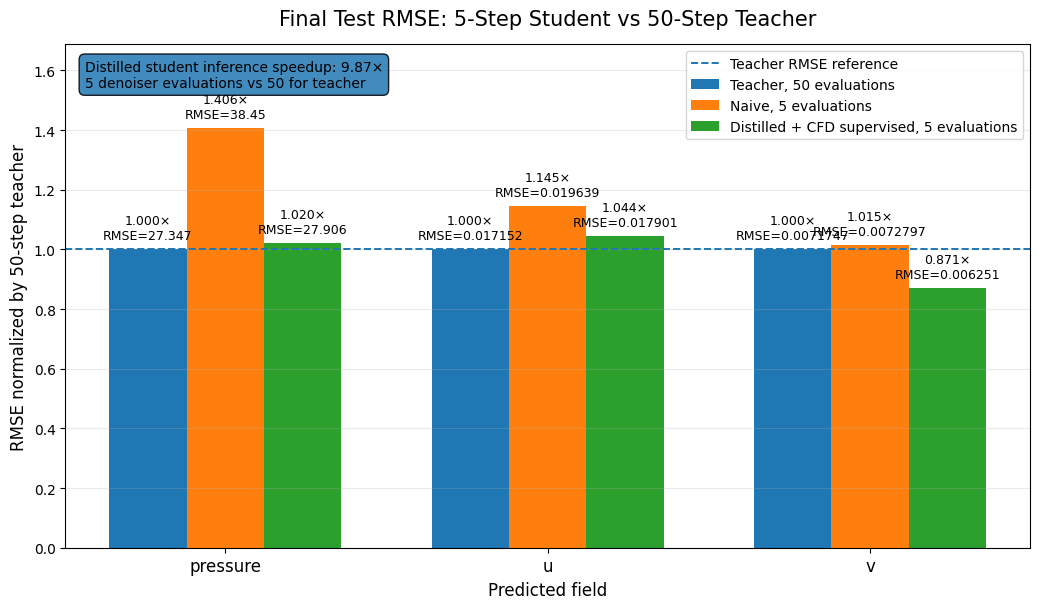


Plot saved:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/plots/final_test_relative_rmse_teacher_naive_distilled.png

[READY] Final test RMSE comparison plotted.


In [27]:
# ============================================================
# Step 15 — Plot final test RMSE comparison
#
# RMSE is normalized by the 50-step teacher for each field:
#   teacher RMSE = 1.0
#
# This allows pressure, u, and v to be compared in one figure
# despite their very different physical scales.
# ============================================================

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch

print("=" * 100)
print("Step 15 — Final test RMSE comparison plot")
print("=" * 100)

# ------------------------------------------------------------
# 1. Load saved final test result
# ------------------------------------------------------------
TEST_RESULT_PATH = Path(
    "/home/nuoxu9/PIDIF/channel_diffusion_dataset/"
    "point_diffusion_progressive_distillation/evaluation/"
    "test_teacher50_naive5_distilled5_stage3_epoch001.pt"
)

# This result file was created locally by our own Step 14 code.
# It contains tensors together with Python/NumPy metadata,
# so PyTorch 2.6 requires weights_only=False.
test_result = torch.load(
    TEST_RESULT_PATH,
    map_location="cpu",
    weights_only=False,
)

print("Loaded:")
print(TEST_RESULT_PATH)

field_names = list(
    test_result["field_names"]
)

teacher_rmse = (
    test_result["global_metrics"]
    ["teacher_50"]["rmse_phys"]
    .numpy()
)

naive_rmse = (
    test_result["global_metrics"]
    ["naive_5"]["rmse_phys"]
    .numpy()
)

distilled_rmse = (
    test_result["global_metrics"]
    ["distilled_5"]["rmse_phys"]
    .numpy()
)

distilled_speedup = (
    test_result["speedup_vs_teacher"]
    ["distilled_5"]
)

print("\nPhysical RMSE")
print("teacher   :", teacher_rmse)
print("naive     :", naive_rmse)
print("distilled :", distilled_rmse)
print("speedup   :", distilled_speedup)

# ------------------------------------------------------------
# 2. Normalize each field by teacher RMSE
# ------------------------------------------------------------
teacher_relative = (
    teacher_rmse
    / teacher_rmse
)

naive_relative = (
    naive_rmse
    / teacher_rmse
)

distilled_relative = (
    distilled_rmse
    / teacher_rmse
)

print("\nRMSE relative to teacher")
print("teacher   :", teacher_relative)
print("naive     :", naive_relative)
print("distilled :", distilled_relative)

# ------------------------------------------------------------
# 3. Plot grouped bars
# ------------------------------------------------------------
x = np.arange(
    len(field_names)
)

bar_width = 0.24

fig, ax = plt.subplots(
    figsize=(10.5, 6.2)
)

teacher_bars = ax.bar(
    x - bar_width,
    teacher_relative,
    width=bar_width,
    label="Teacher, 50 evaluations",
)

naive_bars = ax.bar(
    x,
    naive_relative,
    width=bar_width,
    label="Naive, 5 evaluations",
)

distilled_bars = ax.bar(
    x + bar_width,
    distilled_relative,
    width=bar_width,
    label="Distilled + CFD supervised, 5 evaluations",
)

# Teacher reference line
ax.axhline(
    y=1.0,
    linestyle="--",
    linewidth=1.4,
    label="Teacher RMSE reference",
)

# ------------------------------------------------------------
# 4. Labels and formatting
# ------------------------------------------------------------
ax.set_title(
    "Final Test RMSE: 5-Step Student vs 50-Step Teacher",
    fontsize=15,
    pad=14,
)

ax.set_xlabel(
    "Predicted field",
    fontsize=12,
)

ax.set_ylabel(
    "RMSE normalized by 50-step teacher",
    fontsize=12,
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    field_names,
    fontsize=12,
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.legend(
    fontsize=10,
    loc="upper right",
)

# Leave room for labels
maximum_bar_height = max(
    naive_relative.max(),
    distilled_relative.max(),
    1.0,
)

ax.set_ylim(
    0.0,
    maximum_bar_height * 1.20,
)

# ------------------------------------------------------------
# 5. Add numeric labels
# ------------------------------------------------------------
def add_bar_labels(
    bars,
    relative_values,
    physical_values,
):
    for bar, relative_value, physical_value in zip(
        bars,
        relative_values,
        physical_values,
    ):
        ax.annotate(
            (
                f"{relative_value:.3f}×\n"
                f"RMSE={physical_value:.5g}"
            ),
            xy=(
                bar.get_x()
                + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )


add_bar_labels(
    teacher_bars,
    teacher_relative,
    teacher_rmse,
)

add_bar_labels(
    naive_bars,
    naive_relative,
    naive_rmse,
)

add_bar_labels(
    distilled_bars,
    distilled_relative,
    distilled_rmse,
)

# ------------------------------------------------------------
# 6. Add result summary
# ------------------------------------------------------------
summary_text = (
    f"Distilled student inference speedup: "
    f"{distilled_speedup:.2f}×\n"
    f"5 denoiser evaluations vs 50 for teacher"
)

ax.text(
    0.02,
    0.97,
    summary_text,
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=10,
    bbox={
        "boxstyle": "round,pad=0.4",
        "alpha": 0.85,
    },
)

plt.tight_layout()

# ------------------------------------------------------------
# 7. Save high-resolution figure
# ------------------------------------------------------------
PLOT_DIR = Path(
    "/home/nuoxu9/PIDIF/channel_diffusion_dataset/"
    "point_diffusion_progressive_distillation/plots"
)

PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

plot_path = (
    PLOT_DIR
    / "final_test_relative_rmse_teacher_naive_distilled.png"
)

plt.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("\nPlot saved:")
print(plot_path)

print("\n" + "=" * 100)
print("[READY] Final test RMSE comparison plotted.")
print("=" * 100)

Step 16 — Stage 3 distilled full-channel generation and plotting

Output directory:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/whole_channel_generation

Selected test case:
channel_36

Selected sample indices:
[360, 361, 362, 363, 364, 365, 366, 367, 368, 369]
Selected subdomain IDs:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of subdomains:
10
subdomain=00 | sample=0360 | points= 14143
subdomain=01 | sample=0361 | points= 39976
subdomain=02 | sample=0362 | points=  9495
subdomain=03 | sample=0363 | points= 29972
subdomain=04 | sample=0364 | points=  8777
subdomain=05 | sample=0365 | points= 25824
subdomain=06 | sample=0366 | points= 39000
subdomain=07 | sample=0367 | points=  5564
subdomain=08 | sample=0368 | points= 31228
subdomain=09 | sample=0369 | points= 23525

Complete-channel arrays
x          : (227504,)
y          : (227504,)
prediction : (227504, 3)
truth      : (227504, 3)

Total Stage 3 generation time: 0.1006862442009151 seconds

Compl

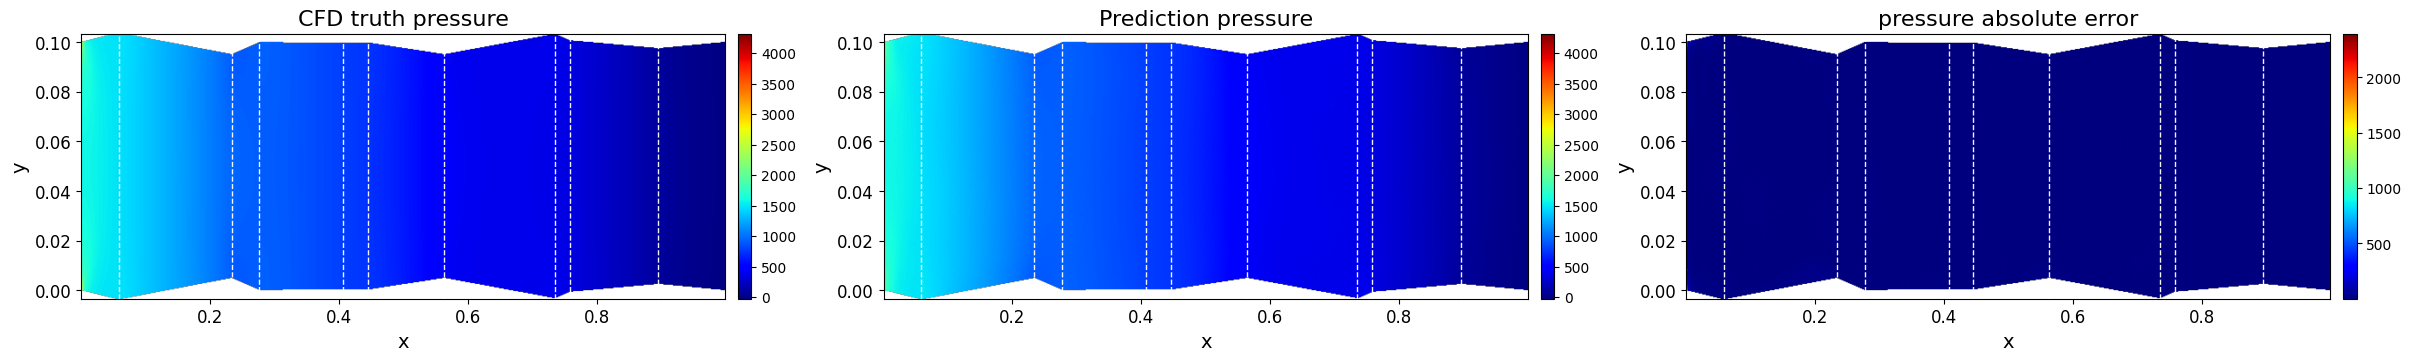


--------------------------------------------------------------------------------
Plotting field: u
--------------------------------------------------------------------------------
Saved: /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/whole_channel_generation/stage3_channel_36/stage3_5step_channel_36_u.png


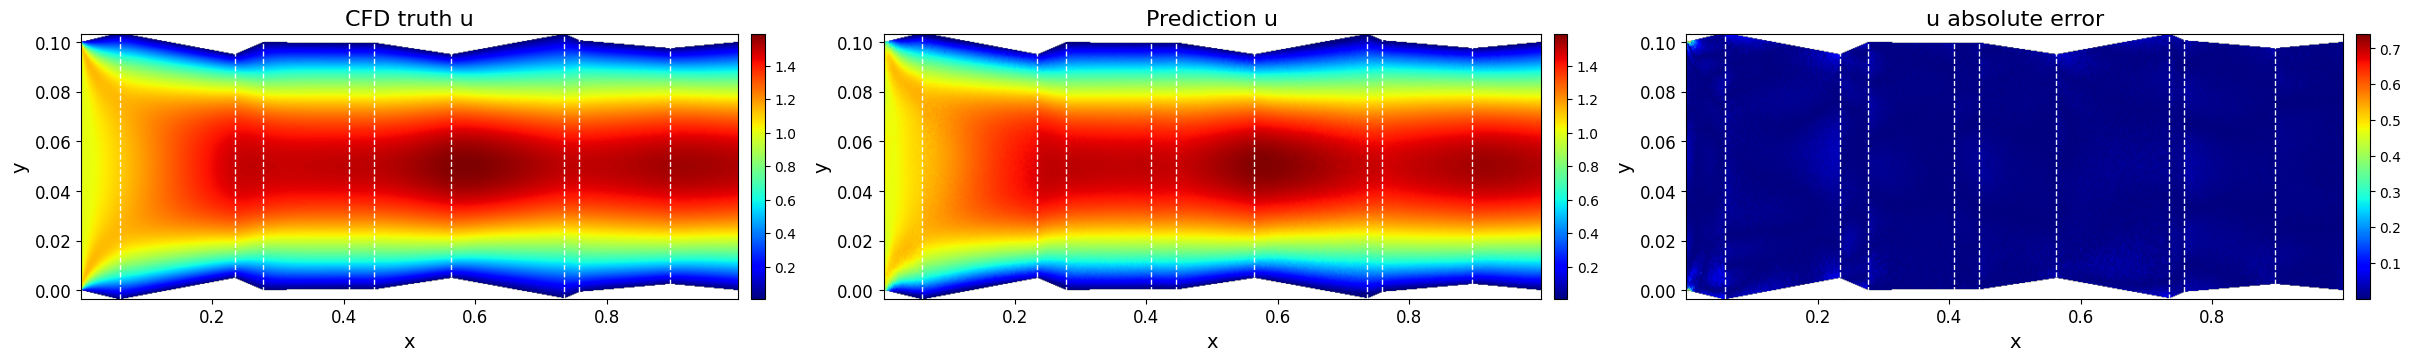


--------------------------------------------------------------------------------
Plotting field: v
--------------------------------------------------------------------------------
Saved: /home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/whole_channel_generation/stage3_channel_36/stage3_5step_channel_36_v.png


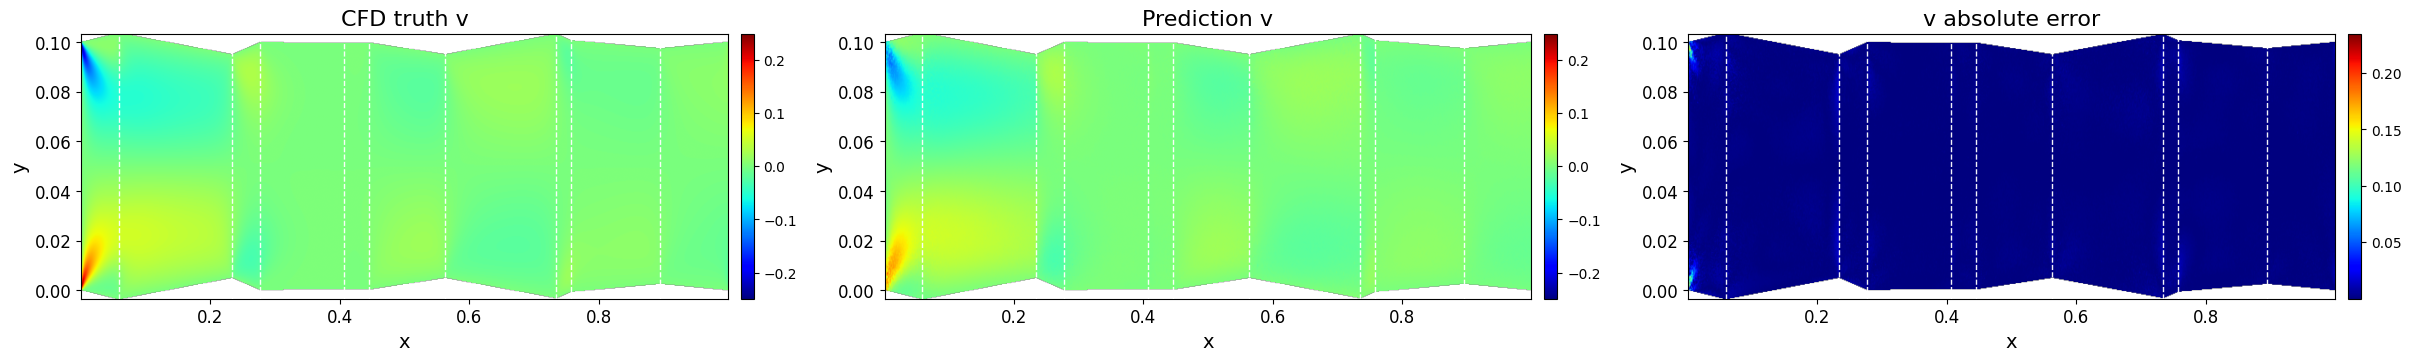


[READY] Complete test channel generated.
[READY] Stage 3 distilled five-step student used.
[READY] Original channel geometry used as the plot mask.
[READY] Pressure, u and v plots saved.
[READY] Prediction arrays and metrics saved.

Saved plot files:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/whole_channel_generation/stage3_channel_36/stage3_5step_channel_36_pressure.png
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/whole_channel_generation/stage3_channel_36/stage3_5step_channel_36_u.png
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/whole_channel_generation/stage3_channel_36/stage3_5step_channel_36_v.png

Saved NPZ:
/home/nuoxu9/PIDIF/channel_diffusion_dataset/point_diffusion_progressive_distillation/whole_channel_generation/stage3_channel_36/stage3_5step_channel_36_prediction.npz


In [44]:
# ============================================================
# Step 16 — Generate and plot one complete test channel
# with the Stage 3 distilled 5-step student
#
# Plot style:
#   CFD truth | Prediction | Absolute error
#
# Reuse:
#   select_sample_indices_by_case_id
#   make_plot_dict_from_iterative_result
#   plot_prediction_imshow_from_points
# ============================================================

import time
from pathlib import Path

import numpy as np
import torch

from eval_fluent_deeponet import (
    select_sample_indices_by_case_id,
    make_plot_dict_from_iterative_result,
)

from deeponet_fluent_dataset import (
    normalize_cell_branch_with_y,
)

from plot import (
    plot_prediction_imshow_from_points,
)


print("=" * 100)
print("Step 16 — Stage 3 distilled full-channel generation and plotting")
print("=" * 100)


# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------
#
# None:
#   automatically select the first complete test channel.
#
# Or manually specify:
#   SELECTED_CASE_ID = "channel_36"
#
SELECTED_CASE_ID = None

DISTILLED_DDIM_STEPS = 5
CHANNEL_NOISE_SEED = 12000

PLOT_N_Y = 300
PLOT_FIGSIZE = (24, 3.5)

DISTILLED_PLOT_DIR = Path(
    "/home/nuoxu9/PIDIF/channel_diffusion_dataset/"
    "point_diffusion_progressive_distillation/"
    "whole_channel_generation"
)

DISTILLED_PLOT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("\nOutput directory:")
print(DISTILLED_PLOT_DIR)


# ------------------------------------------------------------
# 2. Find complete test cases
# ------------------------------------------------------------
test_idx_array = np.asarray(
    test_idx,
    dtype=np.int64,
).reshape(-1)

if test_idx_array.size == 0:
    raise RuntimeError(
        "test_idx is empty."
    )

test_idx_set = set(
    int(index)
    for index in test_idx_array
)

test_case_ids = []

for sample_index in test_idx_array:

    case_id = data["metadata"][
        int(sample_index)
    ]["case_id"]

    if case_id not in test_case_ids:
        test_case_ids.append(case_id)


complete_test_case_ids = []

for case_id in test_case_ids:

    case_sample_indices = (
        select_sample_indices_by_case_id(
            data,
            case_id,
        )
    )

    all_case_samples_in_test = all(
        int(sample_index) in test_idx_set
        for sample_index in case_sample_indices
    )

    if all_case_samples_in_test:
        complete_test_case_ids.append(
            case_id
        )


if not complete_test_case_ids:
    raise RuntimeError(
        "No complete channel was found in the test split."
    )


if SELECTED_CASE_ID is None:
    selected_case_id = complete_test_case_ids[0]
else:
    selected_case_id = SELECTED_CASE_ID


if selected_case_id not in complete_test_case_ids:
    raise ValueError(
        f"{selected_case_id} is not a complete test case.\n"
        f"Available complete test cases include:\n"
        f"{complete_test_case_ids[:20]}"
    )


print("\nSelected test case:")
print(selected_case_id)


# ------------------------------------------------------------
# 3. Select all subdomains belonging to the channel
# ------------------------------------------------------------
selected_sample_indices = (
    select_sample_indices_by_case_id(
        data,
        selected_case_id,
    )
)

selected_sample_indices = np.asarray(
    selected_sample_indices,
    dtype=np.int64,
)

selected_subdomain_ids = [
    int(
        data["metadata"][
            int(sample_index)
        ]["subdomain_id"]
    )
    for sample_index in selected_sample_indices
]


print("\nSelected sample indices:")
print(selected_sample_indices.tolist())

print("Selected subdomain IDs:")
print(selected_subdomain_ids)

print("Number of subdomains:")
print(len(selected_sample_indices))


# Confirm every selected sample belongs to the test split.
missing_from_test = [
    int(sample_index)
    for sample_index in selected_sample_indices
    if int(sample_index) not in test_idx_set
]

if missing_from_test:
    raise RuntimeError(
        "The selected case is not fully contained in the test split.\n"
        f"Missing sample indices: {missing_from_test}"
    )


# ------------------------------------------------------------
# 4. Predict a complete case with the distilled student
# ------------------------------------------------------------
@torch.no_grad()
def predict_distilled_case_for_plot(
    case_id,
    data,
    model,
    device,
    y_normalizer,
    local_aspect_mean,
    local_aspect_std,
    steps=5,
    base_noise_seed=12000,
):
    """
    Predict all subdomains of one complete channel using the
    Stage 3 distilled diffusion student.

    Each subdomain is sampled with a deterministic noise seed.

    Returns
    -------
    sample_indices:
        Global indices of all subdomains belonging to the case.

    plot_dict:
        Complete-channel physical coordinates, CFD truth and
        Stage 3 predictions.

    generation_seconds:
        Total sampling time over all subdomains.
    """

    sample_indices = (
        select_sample_indices_by_case_id(
            data,
            case_id,
        )
    )

    sample_indices = np.asarray(
        sample_indices,
        dtype=np.int64,
    )

    pred_samples = []
    generation_seconds = 0.0

    model.eval()

    for local_subdomain_index, sample_index in enumerate(
        sample_indices
    ):
        sample = data["samples"][
            int(sample_index)
        ]

        # ----------------------------------------------------
        # Normalize branch exactly as during training
        # ----------------------------------------------------
        branch_norm = normalize_cell_branch_with_y(
            sample["branch"],
            branch_channel_names=(
                data["branch_channel_names"]
            ),
            target_y_normalizer=y_normalizer,
            local_aspect_mean=local_aspect_mean,
            local_aspect_std=local_aspect_std,
        )

        branch_t = torch.as_tensor(
            branch_norm[None, ...],
            dtype=torch.float32,
            device=device,
        )

        query_t = torch.as_tensor(
            sample["query"],
            dtype=torch.float32,
            device=device,
        )

        query_batch_id_t = torch.zeros(
            query_t.shape[0],
            dtype=torch.long,
            device=device,
        )

        branch_mask_t = torch.ones(
            (
                1,
                branch_t.shape[1],
            ),
            dtype=torch.bool,
            device=device,
        )

        # ----------------------------------------------------
        # Deterministic initial noise
        # ----------------------------------------------------
        noise_generator = torch.Generator(
            device=device
        )

        noise_generator.manual_seed(
            int(base_noise_seed)
            + int(local_subdomain_index)
        )

        initial_noise = torch.randn(
            (
                query_t.shape[0],
                len(data["output_channel_names"]),
            ),
            generator=noise_generator,
            device=device,
            dtype=torch.float32,
        )

        # ----------------------------------------------------
        # Stage 3 distilled 5-step sampling
        # ----------------------------------------------------
        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        pred_norm = sample_point_ddim_teacher(
            model=model,
            branch=branch_t,
            query=query_t,
            query_batch_id=query_batch_id_t,
            branch_mask=branch_mask_t,
            num_sampling_steps=steps,
            initial_noise=initial_noise,
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        generation_seconds += (
            time.perf_counter()
            - start_time
        )

        # Convert normalized p/u/v into physical units.
        pred_phys = (
            y_normalizer
            .decode(pred_norm)
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        pred_samples.append(
            pred_phys
        )

        subdomain_id = int(
            data["metadata"][
                int(sample_index)
            ]["subdomain_id"]
        )

        print(
            f"subdomain={subdomain_id:02d} | "
            f"sample={int(sample_index):04d} | "
            f"points={query_t.shape[0]:6d}"
        )

    # --------------------------------------------------------
    # Convert subdomain outputs into full-channel plot arrays
    # --------------------------------------------------------
    result = {
        "pred_samples": pred_samples,
    }

    plot_dict = (
        make_plot_dict_from_iterative_result(
            result=result,
            data=data,
            sample_indices=sample_indices,
            output_channel_names=(
                data["output_channel_names"]
            ),
        )
    )

    return (
        sample_indices,
        plot_dict,
        generation_seconds,
    )


# ------------------------------------------------------------
# 5. Run Stage 3 generation
# ------------------------------------------------------------
student_model.eval()
y_normalizer = y_normalizer.to(DEVICE)

(
    sample_indices_distilled,
    plot_dict_distilled,
    distilled_generation_seconds,
) = predict_distilled_case_for_plot(
    case_id=selected_case_id,
    data=data,
    model=student_model,
    device=DEVICE,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    steps=DISTILLED_DDIM_STEPS,
    base_noise_seed=CHANNEL_NOISE_SEED,
)


print("\nComplete-channel arrays")
print(
    "x          :",
    plot_dict_distilled["x"].shape,
)
print(
    "y          :",
    plot_dict_distilled["y"].shape,
)
print(
    "prediction :",
    plot_dict_distilled["pred"].shape,
)
print(
    "truth      :",
    plot_dict_distilled["truth"].shape,
)

print(
    "\nTotal Stage 3 generation time:",
    distilled_generation_seconds,
    "seconds",
)


# ------------------------------------------------------------
# 6. Compute complete-channel metrics
# ------------------------------------------------------------
channel_error = (
    plot_dict_distilled["pred"]
    - plot_dict_distilled["truth"]
)

channel_rmse = np.sqrt(
    np.mean(
        channel_error ** 2,
        axis=0,
    )
)

channel_mae = np.mean(
    np.abs(
        channel_error
    ),
    axis=0,
)


print("\nComplete-channel physical metrics")

for field_index, field_name in enumerate(
    data["output_channel_names"]
):
    print(
        f"{field_name:10s} | "
        f"RMSE={channel_rmse[field_index]:.8f} | "
        f"MAE={channel_mae[field_index]:.8f}"
    )


# ------------------------------------------------------------
# 7. Save old-style plots with original channel geometry
# ------------------------------------------------------------
def save_distilled_case_plots(
    case_id,
    data,
    sample_indices,
    plot_dict,
    out_dir,
    n_y_plot=300,
    figsize=(24, 3.5),
):
    """
    Plot CFD truth, Stage 3 prediction and absolute error
    while masking everything outside the original channel wall.
    """

    metadata_list = [
        data["metadata"][
            int(sample_index)
        ]
        for sample_index in sample_indices
    ]

    # --------------------------------------------------------
    # Load original wall geometry from geometry JSON
    # --------------------------------------------------------
    import json

    geometry_json_path = (
        Path(
            "/home/nuoxu9/PIDIF/2d_geometry_specs/"
            "channel_water"
        )
        / f"{case_id}.json"
    )

    with open(
        geometry_json_path,
        "r",
        encoding="utf-8",
    ) as f:
        geometry_spec = json.load(f)

    boundaries = geometry_spec["boundaries"]

    print("\nGeometry JSON:")
    print(geometry_json_path)
    print("Boundary type:", type(boundaries))
    print(
        "Boundary keys:",
        list(boundaries.keys())
        if isinstance(boundaries, dict)
        else f"{len(boundaries)} boundary entries",
    )


    def boundary_to_xy(boundary):
        """
        Recursively convert one boundary definition into (N, 2).

        Supports:
        [[x, y], ...]
        [{"x": ..., "y": ...}, ...]
        {"x": [...], "y": [...]}
        {"points": ...}
        {"coordinates": ...}
        nested boundary dictionaries
        """

        # --------------------------------------------------------
        # Dictionary
        # --------------------------------------------------------
        if isinstance(boundary, dict):

            # Separate x/y arrays
            if "x" in boundary and "y" in boundary:
                x_value = boundary["x"]
                y_value = boundary["y"]

                # One scalar point
                if np.isscalar(x_value) and np.isscalar(y_value):
                    return np.asarray(
                        [[float(x_value), float(y_value)]],
                        dtype=np.float64,
                    )

                x_array = np.asarray(
                    x_value,
                    dtype=np.float64,
                ).reshape(-1)

                y_array = np.asarray(
                    y_value,
                    dtype=np.float64,
                ).reshape(-1)

                if x_array.size == y_array.size:
                    return np.column_stack(
                        [x_array, y_array]
                    )

            # Common nested coordinate keys
            for key in [
                "points",
                "coordinates",
                "vertices",
                "polyline",
                "nodes",
                "data",
                "geometry",
            ]:
                if key in boundary:
                    try:
                        result = boundary_to_xy(
                            boundary[key]
                        )

                        if (
                            result is not None
                            and len(result) >= 2
                        ):
                            return result

                    except (TypeError, ValueError):
                        pass

            # Search every nested value
            for value in boundary.values():
                if isinstance(value, (dict, list, tuple)):
                    try:
                        result = boundary_to_xy(value)

                        if (
                            result is not None
                            and len(result) >= 2
                        ):
                            return result

                    except (TypeError, ValueError):
                        pass

            raise ValueError(
                "No coordinate array found in boundary dictionary. "
                f"Keys: {list(boundary.keys())}"
            )

        # --------------------------------------------------------
        # List or tuple
        # --------------------------------------------------------
        if isinstance(boundary, (list, tuple)):

            if len(boundary) == 0:
                raise ValueError(
                    "Boundary list is empty."
                )

            # List of point dictionaries
            if all(
                isinstance(item, dict)
                for item in boundary
            ):
                points = []

                for item in boundary:
                    if "x" in item and "y" in item:
                        points.append(
                            [
                                float(item["x"]),
                                float(item["y"]),
                            ]
                        )

                    elif "X" in item and "Y" in item:
                        points.append(
                            [
                                float(item["X"]),
                                float(item["Y"]),
                            ]
                        )

                    else:
                        # The point may itself be nested
                        try:
                            nested = boundary_to_xy(item)

                            if nested is not None:
                                points.extend(
                                    nested.tolist()
                                )

                        except (TypeError, ValueError):
                            pass

                if len(points) >= 2:
                    return np.asarray(
                        points,
                        dtype=np.float64,
                    )

            # Direct numeric Nx2 list
            try:
                array = np.asarray(
                    boundary,
                    dtype=np.float64,
                )

                if (
                    array.ndim == 2
                    and array.shape[0] >= 2
                    and array.shape[1] >= 2
                ):
                    return array[:, :2]

            except (TypeError, ValueError):
                pass

            # Search nested list entries
            for item in boundary:
                if isinstance(item, (dict, list, tuple)):
                    try:
                        result = boundary_to_xy(item)

                        if (
                            result is not None
                            and len(result) >= 2
                        ):
                            return result

                    except (TypeError, ValueError):
                        pass

        raise ValueError(
            f"Cannot convert boundary type "
            f"{type(boundary)} into XY coordinates."
        )

    # --------------------------------------------------------
    # Support either:
    #   boundaries = {"top": ..., "bottom": ...}
    # or:
    #   boundaries = [{"name": "top", ...}, ...]
    # --------------------------------------------------------
    if isinstance(boundaries, dict):

        top_key = next(
            key
            for key in boundaries
            if any(
                token in key.lower()
                for token in ["top", "upper"]
            )
        )

        bottom_key = next(
            key
            for key in boundaries
            if any(
                token in key.lower()
                for token in ["bottom", "lower"]
            )
        )

        top_xy = boundary_to_xy(
            boundaries[top_key]
        )

        bottom_xy = boundary_to_xy(
            boundaries[bottom_key]
        )

    else:

        def get_boundary_name(entry):
            return str(
                entry.get(
                    "name",
                    entry.get(
                        "type",
                        entry.get("id", ""),
                    ),
                )
            ).lower()

        top_entry = next(
            entry
            for entry in boundaries
            if any(
                token in get_boundary_name(entry)
                for token in ["top", "upper"]
            )
        )

        bottom_entry = next(
            entry
            for entry in boundaries
            if any(
                token in get_boundary_name(entry)
                for token in ["bottom", "lower"]
            )
        )

        top_xy = boundary_to_xy(
            top_entry
        )

        bottom_xy = boundary_to_xy(
            bottom_entry
        )


    # Sort each wall from inlet to outlet.
    top_xy = top_xy[
        np.argsort(top_xy[:, 0])
    ]

    bottom_xy = bottom_xy[
        np.argsort(bottom_xy[:, 0])
    ]

    # Put both walls on the same x coordinates.
    wall_x = np.unique(
        np.concatenate(
            [
                top_xy[:, 0],
                bottom_xy[:, 0],
            ]
        )
    )

    wall_y_top = np.interp(
        wall_x,
        top_xy[:, 0],
        top_xy[:, 1],
    )

    wall_y_bottom = np.interp(
        wall_x,
        bottom_xy[:, 0],
        bottom_xy[:, 1],
    )

    print("\nLoaded original channel walls")
    print("wall points :", len(wall_x))
    print("wall x      :", wall_x.min(), wall_x.max())
    print(
        "bottom y    :",
        wall_y_bottom.min(),
        wall_y_bottom.max(),
    )
    print(
        "top y       :",
        wall_y_top.min(),
        wall_y_top.max(),
    )

    if (
        wall_x is None
        or wall_y_bottom is None
        or wall_y_top is None
    ):
        raise RuntimeError(
            f"Original wall geometry is missing for {case_id}.\n"
            f"Available raw-case keys:\n"
            f"{list(raw.keys())}"
        )

    wall_x = np.asarray(
        wall_x,
        dtype=np.float64,
    ).reshape(-1)

    wall_y_bottom = np.asarray(
        wall_y_bottom,
        dtype=np.float64,
    ).reshape(-1)

    wall_y_top = np.asarray(
        wall_y_top,
        dtype=np.float64,
    ).reshape(-1)

    if not (
        len(wall_x)
        == len(wall_y_bottom)
        == len(wall_y_top)
    ):
        raise ValueError(
            "Wall arrays have different lengths:\n"
            f"wall_x={len(wall_x)}, "
            f"wall_y_bottom={len(wall_y_bottom)}, "
            f"wall_y_top={len(wall_y_top)}"
        )

    # --------------------------------------------------------
    # Check plot coordinates and wall coordinates
    # --------------------------------------------------------
    plot_x = np.asarray(
        plot_dict["x"],
        dtype=np.float64,
    )

    plot_y = np.asarray(
        plot_dict["y"],
        dtype=np.float64,
    )

    print("\nCoordinate ranges")
    print(
        "plot x:",
        float(plot_x.min()),
        "to",
        float(plot_x.max()),
    )
    print(
        "plot y:",
        float(plot_y.min()),
        "to",
        float(plot_y.max()),
    )
    print(
        "wall x:",
        float(wall_x.min()),
        "to",
        float(wall_x.max()),
    )
    print(
        "wall bottom:",
        float(wall_y_bottom.min()),
        "to",
        float(wall_y_bottom.max()),
    )
    print(
        "wall top:",
        float(wall_y_top.min()),
        "to",
        float(wall_y_top.max()),
    )

    # The dataset and raw geometry should already use physical
    # millimeter coordinates. Stop if the ranges are inconsistent.
    plot_x_span = float(
        plot_x.max()
        - plot_x.min()
    )

    wall_x_span = float(
        wall_x.max()
        - wall_x.min()
    )

    span_ratio = (
        wall_x_span
        / max(
            plot_x_span,
            1.0e-12,
        )
    )

    if not (
        0.5
        <= span_ratio
        <= 2.0
    ):
        raise RuntimeError(
            "Wall and plot x coordinates appear to use "
            "different units.\n"
            f"plot x span={plot_x_span}, "
            f"wall x span={wall_x_span}, "
            f"ratio={span_ratio}"
        )

    # --------------------------------------------------------
    # Output directory for this channel
    # --------------------------------------------------------
    case_out_dir = (
        out_dir
        / f"stage3_{case_id}"
    )

    case_out_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    saved_files = []

    # --------------------------------------------------------
    # Plot pressure, u and v
    # --------------------------------------------------------
    for field_index, field_name in enumerate(
        data["output_channel_names"]
    ):
        print("\n" + "-" * 80)
        print(
            f"Plotting field: {field_name}"
        )
        print("-" * 80)

        filename_prefix = (
            f"stage3_5step_{case_id}"
        )

        plot_prediction_imshow_from_points(
            x=plot_dict["x"],
            y=plot_dict["y"],
            pred=plot_dict["pred"],
            truth=plot_dict["truth"],

            field_name=field_name,
            field_idx=field_index,

            figsize=figsize,
            n_y_plot=n_y_plot,

            output_dir=str(case_out_dir),
            filename_prefix=filename_prefix,

            wall_x=wall_x,
            wall_y_bottom=wall_y_bottom,
            wall_y_top=wall_y_top,

            draw_boundary=False,
            draw_interfaces=True,

            metadata=metadata_list,
            interface_placement=data.get(
                "interface_placement",
                None,
            ),

            show=True,
        )

        expected_save_path = (
            case_out_dir
            / (
                f"{filename_prefix}_"
                f"{field_name}.png"
            )
        )

        saved_files.append(
            expected_save_path
        )

    return saved_files


# ------------------------------------------------------------
# 8. Run the original-shape plotting function
# ------------------------------------------------------------
saved_plot_files = save_distilled_case_plots(
    case_id=selected_case_id,
    data=data,
    sample_indices=sample_indices_distilled,
    plot_dict=plot_dict_distilled,
    out_dir=DISTILLED_PLOT_DIR,
    n_y_plot=PLOT_N_Y,
    figsize=PLOT_FIGSIZE,
)


# ------------------------------------------------------------
# 9. Save prediction arrays and metrics
# ------------------------------------------------------------
case_output_dir = (
    DISTILLED_PLOT_DIR
    / f"stage3_{selected_case_id}"
)

case_output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

npz_path = (
    case_output_dir
    / (
        f"stage3_5step_"
        f"{selected_case_id}_prediction.npz"
    )
)

np.savez_compressed(
    npz_path,

    case_id=np.asarray(
        selected_case_id
    ),

    sample_indices=np.asarray(
        sample_indices_distilled,
        dtype=np.int64,
    ),

    x=np.asarray(
        plot_dict_distilled["x"],
        dtype=np.float32,
    ),

    y=np.asarray(
        plot_dict_distilled["y"],
        dtype=np.float32,
    ),

    prediction=np.asarray(
        plot_dict_distilled["pred"],
        dtype=np.float32,
    ),

    truth=np.asarray(
        plot_dict_distilled["truth"],
        dtype=np.float32,
    ),

    absolute_error=np.asarray(
        np.abs(channel_error),
        dtype=np.float32,
    ),

    rmse=np.asarray(
        channel_rmse,
        dtype=np.float64,
    ),

    mae=np.asarray(
        channel_mae,
        dtype=np.float64,
    ),

    generation_seconds=np.asarray(
        distilled_generation_seconds,
        dtype=np.float64,
    ),

    noise_seed=np.asarray(
        CHANNEL_NOISE_SEED,
        dtype=np.int64,
    ),

    ddim_steps=np.asarray(
        DISTILLED_DDIM_STEPS,
        dtype=np.int64,
    ),

    field_names=np.asarray(
        data["output_channel_names"]
    ),

    student_checkpoint=np.asarray(
        str(
            STAGE3_CHECKPOINT_PATH
        )
    ),
)


# ------------------------------------------------------------
# 10. Final summary
# ------------------------------------------------------------
print("\n" + "=" * 100)
print("[READY] Complete test channel generated.")
print("[READY] Stage 3 distilled five-step student used.")
print("[READY] Original channel geometry used as the plot mask.")
print("[READY] Pressure, u and v plots saved.")
print("[READY] Prediction arrays and metrics saved.")
print("=" * 100)

print("\nSaved plot files:")

for plot_file in saved_plot_files:
    print(plot_file)

print("\nSaved NPZ:")
print(npz_path)